# Student FULL name: Nouviboth RA
# Student number: 60858559

Acknowledgement Statement by students: <br>
Please keep one acknowledgment from the following<br>
	I acknowledge that I have not used GenAI (e. g., ChatGPT) in drafting and proofreading of this assignment.<br>

#  Answer to Section 1: Possum Overview

Australian Possums are nocturnal marsupials which can be found in both bushland areas and urban areas. Possums play important roles in dispersing seeds and contributing to the regeneration of the forest. On the other hand, Possums’ ability to adapt to their environment can lead to issues such as nesting in roofs and damaging properties. Overall, while possums support biodiversity, their presence in human habitats can lead to habitat problems, which require careful management to balance conservation with community concerns.<br>

**Reference**:<br>
Queensland Government. (2023, April 19). About possums. https://www.qld.gov.au/environment/plants-animals/animals/discovering-wildlife/possum/about-possums 

# Answer to Section 2: EDA

## Data Cleaning

In [1]:
#Import pandas function to work on the dataset, reading, cleaning
import pandas as pd

#Import matplotlib function for plotting library
import matplotlib.pyplot as plt

#Import seaborn for higher level of plotting
import seaborn as sns

#Import numpy to use for math calculation
import numpy as np

#Import scipy for calculating statistical function
from scipy import stats

In [2]:
#load data into a DataFrame by using pandas
possum = pd.read_csv("possum.csv")

#Display the DataFrame with 1 row only
possum.head(1)

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
0,1.0,1.0,Vic,m,8.4,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36


In [3]:
#Display the number rows and columns
possum.shape

(104, 14)

In [4]:
#Display a summary of the dataframe, including the range index, dtypes, column headers, and memory usage
possum.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   case      103 non-null    float64
 1   site      103 non-null    float64
 2   Pop       103 non-null    object 
 3   gender    104 non-null    object 
 4   age       101 non-null    object 
 5   hdlngth   102 non-null    float64
 6   skullw    103 non-null    object 
 7   totlngth  103 non-null    float64
 8   taill     104 non-null    float64
 9   footlgth  103 non-null    object 
 10  earconch  104 non-null    float64
 11  eye       103 non-null    float64
 12  chest     104 non-null    float64
 13  belly     102 non-null    object 
dtypes: float64(8), object(6)
memory usage: 11.5+ KB


In [5]:
#Convert the data in the columns that has object as Dtype to numeric value
possum['age']=pd.to_numeric(possum['age'], errors='coerce')
possum['skullw']=pd.to_numeric(possum['skullw'], errors='coerce')
possum['footlgth']=pd.to_numeric(possum['footlgth'], errors='coerce')
possum['belly']=pd.to_numeric(possum['belly'], errors='coerce')

In [6]:
#Display a summary of the dataframe after converting
possum.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   case      103 non-null    float64
 1   site      103 non-null    float64
 2   Pop       103 non-null    object 
 3   gender    104 non-null    object 
 4   age       98 non-null     float64
 5   hdlngth   102 non-null    float64
 6   skullw    102 non-null    float64
 7   totlngth  103 non-null    float64
 8   taill     104 non-null    float64
 9   footlgth  102 non-null    float64
 10  earconch  104 non-null    float64
 11  eye       103 non-null    float64
 12  chest     104 non-null    float64
 13  belly     101 non-null    float64
dtypes: float64(12), object(2)
memory usage: 11.5+ KB


In [7]:
#Finding missing values and sum the values to get total amount
possum.isnull().sum()

case        1
site        1
Pop         1
gender      0
age         6
hdlngth     2
skullw      2
totlngth    1
taill       0
footlgth    2
earconch    0
eye         1
chest       0
belly       3
dtype: int64

In [8]:
#Filter the DataFrame only to include rows with at least one missing value.
row_miss = possum[possum.isna().any(axis=1)]
row_miss 

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
12,13.0,1.0,Vic,m,5.4,95.1,59.9,89.5,36.0,71.0,49.8,15.8,27.0,NaN
14,15.0,1.0,Vic,m,NaN,92.9,57.6,85.5,-22.0,69.7,51.8,15.7,28.0,35.0
15,16.0,1.0,Vic,m,NaN,91.6,56.0,86.0,34.5,73.0,51.4,14.4,28.0,32.0
16,17.0,1.0,Vic,f,1.2,94.7,67.7,NaN,36.5,73.2,53.2,14.7,29.0,31.0
27,28.0,1.0,Vic,m,4.5,NaN,56.8,87.0,34.5,73.2,53.0,15.3,27.0,30.0
37,38.0,2.0,Vic,m,NaN,92.4,56.0,80.5,35.5,68.4,49.5,15.9,27.0,30.0
40,41.0,2.0,Vic,f,5.3,88.4,57.0,83.0,36.5,NaN,40.3,15.9,27.0,30.5
41,42.0,2.0,Vic,m,NaN,85.3,54.1,77.0,32.0,62.7,51.2,13.8,25.5,33.0
43,44.0,2.0,Vic,m,NaN,85.1,51.5,76.0,35.5,70.3,52.6,14.4,23.0,27.0
45,46.0,2.0,Vic,m,NaN,91.4,54.4,84.0,35.0,72.8,51.2,14.4,24.5,35.0


In [9]:
#Grouping the columns to find the median of age for site and gender columns, then display as index
age_median = possum.groupby(['site','gender'])['age'].median().reset_index()
age_median

,site,gender,age
0,1.0,f,4.30
1,1.0,m,3.35
2,2.0,f,2.50
3,2.0,m,3.95
4,3.0,f,5.20
5,3.0,m,4.75
6,4.0,f,3.25
7,4.0,m,3.70
8,5.0,f,4.75
9,5.0,m,5.40


In [10]:
# Get the age median of the site 1.0 and gender m
male_age = age_median.loc[(age_median["site"] == 1.0) & (age_median["gender"] == "m"), "age"].dropna().iloc[0]
male_age

np.float64(3.3499999999999996)

In [11]:
#Fill missing values with a specified value that defined in cell 10
possum.loc[possum["site"]== 1.0,"age"] = possum.loc[possum["site"]== 1.0,"age"].fillna(male_age)

In [12]:
#Checking by showing the missing value whether it has been filled
row_miss = possum[possum.isna().any(axis=1)]
row_miss 

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
12,13.0,1.0,Vic,m,5.4,95.1,59.9,89.5,36.0,71.0,49.8,15.8,27.0,NaN
16,17.0,1.0,Vic,f,1.2,94.7,67.7,NaN,36.5,73.2,53.2,14.7,29.0,31.0
27,28.0,1.0,Vic,m,4.5,NaN,56.8,87.0,34.5,73.2,53.0,15.3,27.0,30.0
37,38.0,2.0,Vic,m,NaN,92.4,56.0,80.5,35.5,68.4,49.5,15.9,27.0,30.0
40,41.0,2.0,Vic,f,5.3,88.4,57.0,83.0,36.5,NaN,40.3,15.9,27.0,30.5
41,42.0,2.0,Vic,m,NaN,85.3,54.1,77.0,32.0,62.7,51.2,13.8,25.5,33.0
43,44.0,2.0,Vic,m,NaN,85.1,51.5,76.0,35.5,70.3,52.6,14.4,23.0,27.0
45,46.0,2.0,Vic,m,NaN,91.4,54.4,84.0,35.0,72.8,51.2,14.4,24.5,35.0
57,58.0,4.0,other,m,3.7,94.5,NaN,91.0,39.0,66.5,-14.0,14.4,30.5,33.0
79,80.0,6.0,other,m,1.6,86.7,52.6,84.0,38.0,62.3,44.8,NaN,23.5,30.5


In [13]:
# Get the age median of the site 2.0 and gender m
male_age_2 = age_median.loc[(age_median["site"] == 2.0) & (age_median["gender"] == "m"), "age"].dropna().iloc[0]
male_age_2

np.float64(3.95)

In [14]:
#Fill missing values with a specified value that defined in cell 13
possum.loc[possum["site"]== 2.0,"age"] = possum.loc[possum["site"]== 2.0,"age"].fillna(male_age_2)

In [15]:
#Checking by showing the missing value whether it has been filled
row_miss = possum[possum.isna().any(axis=1)]
row_miss 

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
12,13.0,1.0,Vic,m,5.4,95.1,59.9,89.5,36.0,71.0,49.8,15.8,27.0,NaN
16,17.0,1.0,Vic,f,1.2,94.7,67.7,NaN,36.5,73.2,53.2,14.7,29.0,31.0
27,28.0,1.0,Vic,m,4.5,NaN,56.8,87.0,34.5,73.2,53.0,15.3,27.0,30.0
40,41.0,2.0,Vic,f,5.3,88.4,57.0,83.0,36.5,NaN,40.3,15.9,27.0,30.5
57,58.0,4.0,other,m,3.7,94.5,NaN,91.0,39.0,66.5,-14.0,14.4,30.5,33.0
79,80.0,6.0,other,m,1.6,86.7,52.6,84.0,38.0,62.3,44.8,NaN,23.5,30.5
82,83.0,6.0,NaN,f,3.1,NaN,53.8,81.5,36.0,62.0,43.3,14.0,25.0,29.0
86,87.0,7.0,other,m,2.3,98.5,NaN,93.0,41.5,71.7,46.8,15.0,26.0,36.0
89,90.0,7.0,other,m,3.5,92.6,54.6,85.0,38.5,1500.0,44.8,14.5,25.5,NaN
92,93.0,7.0,other,m,3.8,89.2,54.0,82.0,38.0,63.8,44.9,12.8,24.0,NaN


In [16]:
#Grouping the columns to find the median of head length for site and gender columns, then display as index
hdlngth_median = possum.groupby(['site','gender'])['hdlngth'].median().reset_index()
hdlngth_median

,site,gender,hdlngth
0,1.0,f,93.30
1,1.0,m,94.40
2,2.0,f,89.30
3,2.0,m,91.05
4,3.0,f,93.10
5,3.0,m,96.50
6,4.0,f,93.20
7,4.0,m,99.90
8,5.0,f,91.95
9,5.0,m,93.30


In [17]:
# Get the median of head length with site 1.0 and gender m
male_hdlngth = hdlngth_median.loc[(hdlngth_median["site"] == 1.0) & (hdlngth_median["gender"] == "m"), "hdlngth"].dropna().iloc[0]
male_hdlngth

np.float64(94.4)

In [18]:
#Fill missing values
possum.loc[possum["site"]== 1.0,"hdlngth"] = possum.loc[possum["site"]== 1.0,"hdlngth"].fillna(male_hdlngth)

In [19]:
#Checking by showing the missing value whether it has been filled
row_miss = possum[possum.isna().any(axis=1)]
row_miss 

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
12,13.0,1.0,Vic,m,5.4,95.1,59.9,89.5,36.0,71.0,49.8,15.8,27.0,NaN
16,17.0,1.0,Vic,f,1.2,94.7,67.7,NaN,36.5,73.2,53.2,14.7,29.0,31.0
40,41.0,2.0,Vic,f,5.3,88.4,57.0,83.0,36.5,NaN,40.3,15.9,27.0,30.5
57,58.0,4.0,other,m,3.7,94.5,NaN,91.0,39.0,66.5,-14.0,14.4,30.5,33.0
79,80.0,6.0,other,m,1.6,86.7,52.6,84.0,38.0,62.3,44.8,NaN,23.5,30.5
82,83.0,6.0,NaN,f,3.1,NaN,53.8,81.5,36.0,62.0,43.3,14.0,25.0,29.0
86,87.0,7.0,other,m,2.3,98.5,NaN,93.0,41.5,71.7,46.8,15.0,26.0,36.0
89,90.0,7.0,other,m,3.5,92.6,54.6,85.0,38.5,1500.0,44.8,14.5,25.5,NaN
92,93.0,7.0,other,m,3.8,89.2,54.0,82.0,38.0,63.8,44.9,12.8,24.0,NaN
94,NaN,7.0,other,m,4.3,91.6,56.6,88.5,37.5,NaN,45.4,14.9,27.0,31.0


In [20]:
# Get the median of head length with site 6.0 and gender f
female_hdlngth_6 = hdlngth_median.loc[(hdlngth_median["site"] == 6.0) & (hdlngth_median["gender"] == "f"), "hdlngth"].dropna().iloc[0]
female_hdlngth_6

np.float64(88.2)

In [21]:
#Fill missing values
possum.loc[possum["site"]== 6.0,"hdlngth"] = possum.loc[possum["site"]== 6.0,"hdlngth"].fillna(female_hdlngth_6)

In [22]:
#Checking by showing the missing value whether it has been filled
row_miss = possum[possum.isna().any(axis=1)]
row_miss 

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
12,13.0,1.0,Vic,m,5.4,95.1,59.9,89.5,36.0,71.0,49.8,15.8,27.0,NaN
16,17.0,1.0,Vic,f,1.2,94.7,67.7,NaN,36.5,73.2,53.2,14.7,29.0,31.0
40,41.0,2.0,Vic,f,5.3,88.4,57.0,83.0,36.5,NaN,40.3,15.9,27.0,30.5
57,58.0,4.0,other,m,3.7,94.5,NaN,91.0,39.0,66.5,-14.0,14.4,30.5,33.0
79,80.0,6.0,other,m,1.6,86.7,52.6,84.0,38.0,62.3,44.8,NaN,23.5,30.5
82,83.0,6.0,NaN,f,3.1,88.2,53.8,81.5,36.0,62.0,43.3,14.0,25.0,29.0
86,87.0,7.0,other,m,2.3,98.5,NaN,93.0,41.5,71.7,46.8,15.0,26.0,36.0
89,90.0,7.0,other,m,3.5,92.6,54.6,85.0,38.5,1500.0,44.8,14.5,25.5,NaN
92,93.0,7.0,other,m,3.8,89.2,54.0,82.0,38.0,63.8,44.9,12.8,24.0,NaN
94,NaN,7.0,other,m,4.3,91.6,56.6,88.5,37.5,NaN,45.4,14.9,27.0,31.0


In [23]:
#Grouping the columns to find the median of skull width for site and gender columns, then display as index
skullw_median = possum.groupby(['site','gender'])['skullw'].median().reset_index()
skullw_median

,site,gender,skullw
0,1.0,f,56.30
1,1.0,m,57.60
2,2.0,f,55.00
3,2.0,m,55.80
4,3.0,f,58.10
5,3.0,m,60.10
6,4.0,f,58.55
7,4.0,m,63.00
8,5.0,f,56.45
9,5.0,m,56.00


In [24]:
# Get the median of skull width with site 4.0 and gender m
male_skullw = skullw_median.loc[(skullw_median["site"] == 4.0) & (skullw_median["gender"] == "m"), "skullw"].dropna().iloc[0]
male_skullw

np.float64(63.0)

In [25]:
# Fill the missing value
possum.loc[possum["site"]== 4.0,"skullw"] = possum.loc[possum["site"]== 4.0,"skullw"].fillna(male_skullw)

In [26]:
#Checking by showing the missing value whether it has been filled
row_miss = possum[possum.isna().any(axis=1)]
row_miss 

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
12,13.0,1.0,Vic,m,5.4,95.1,59.9,89.5,36.0,71.0,49.8,15.8,27.0,NaN
16,17.0,1.0,Vic,f,1.2,94.7,67.7,NaN,36.5,73.2,53.2,14.7,29.0,31.0
40,41.0,2.0,Vic,f,5.3,88.4,57.0,83.0,36.5,NaN,40.3,15.9,27.0,30.5
79,80.0,6.0,other,m,1.6,86.7,52.6,84.0,38.0,62.3,44.8,NaN,23.5,30.5
82,83.0,6.0,NaN,f,3.1,88.2,53.8,81.5,36.0,62.0,43.3,14.0,25.0,29.0
86,87.0,7.0,other,m,2.3,98.5,NaN,93.0,41.5,71.7,46.8,15.0,26.0,36.0
89,90.0,7.0,other,m,3.5,92.6,54.6,85.0,38.5,1500.0,44.8,14.5,25.5,NaN
92,93.0,7.0,other,m,3.8,89.2,54.0,82.0,38.0,63.8,44.9,12.8,24.0,NaN
94,NaN,7.0,other,m,4.3,91.6,56.6,88.5,37.5,NaN,45.4,14.9,27.0,31.0
100,101.0,NaN,other,m,1.7,88.6,54.7,82.5,39.0,64.4,48.0,14.0,25.0,33.0


In [27]:
# Get the median of skull width with site 7.0 and gender m
male_skullw_7 = skullw_median.loc[(skullw_median["site"] == 7.0) & (skullw_median["gender"] == "m"), "skullw"].dropna().iloc[0]
male_skullw_7

np.float64(56.15)

In [28]:
# Fill the missing values
possum.loc[possum["site"]== 7.0,"skullw"] = possum.loc[possum["site"]== 7.0,"skullw"].fillna(male_skullw_7)

In [29]:
#Checking by showing the missing value whether it has been filled
row_miss = possum[possum.isna().any(axis=1)]
row_miss 

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
12,13.0,1.0,Vic,m,5.4,95.1,59.9,89.5,36.0,71.0,49.8,15.8,27.0,NaN
16,17.0,1.0,Vic,f,1.2,94.7,67.7,NaN,36.5,73.2,53.2,14.7,29.0,31.0
40,41.0,2.0,Vic,f,5.3,88.4,57.0,83.0,36.5,NaN,40.3,15.9,27.0,30.5
79,80.0,6.0,other,m,1.6,86.7,52.6,84.0,38.0,62.3,44.8,NaN,23.5,30.5
82,83.0,6.0,NaN,f,3.1,88.2,53.8,81.5,36.0,62.0,43.3,14.0,25.0,29.0
89,90.0,7.0,other,m,3.5,92.6,54.6,85.0,38.5,1500.0,44.8,14.5,25.5,NaN
92,93.0,7.0,other,m,3.8,89.2,54.0,82.0,38.0,63.8,44.9,12.8,24.0,NaN
94,NaN,7.0,other,m,4.3,91.6,56.6,88.5,37.5,NaN,45.4,14.9,27.0,31.0
100,101.0,NaN,other,m,1.7,88.6,54.7,82.5,39.0,64.4,48.0,14.0,25.0,33.0


In [30]:
#Grouping the columns to find the median of total length for site and gender columns, then display as index
totlngth_median = possum.groupby(['site','gender'])['totlngth'].median().reset_index()
totlngth_median

,site,gender,totlngth
0,1.0,f,90.50
1,1.0,m,89.50
2,2.0,f,82.50
3,2.0,m,82.50
4,3.0,f,88.00
5,3.0,m,87.00
6,4.0,f,90.50
7,4.0,m,92.50
8,5.0,f,88.50
9,5.0,m,86.00


In [31]:
# Get the median of total length with site 1.0 and gender f
male_totlngth = totlngth_median.loc[(totlngth_median["site"] == 1.0) & (totlngth_median["gender"] == "f"), "totlngth"].dropna().iloc[0]
male_totlngth

np.float64(90.5)

In [32]:
# Fill the missing value
possum.loc[possum["site"]== 1.0,"totlngth"] = possum.loc[possum["site"]== 1.0,"totlngth"].fillna(male_totlngth)

In [33]:
#Checking by showing the missing value whether it has been filled
row_miss = possum[possum.isna().any(axis=1)]
row_miss 

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
12,13.0,1.0,Vic,m,5.4,95.1,59.9,89.5,36.0,71.0,49.8,15.8,27.0,NaN
40,41.0,2.0,Vic,f,5.3,88.4,57.0,83.0,36.5,NaN,40.3,15.9,27.0,30.5
79,80.0,6.0,other,m,1.6,86.7,52.6,84.0,38.0,62.3,44.8,NaN,23.5,30.5
82,83.0,6.0,NaN,f,3.1,88.2,53.8,81.5,36.0,62.0,43.3,14.0,25.0,29.0
89,90.0,7.0,other,m,3.5,92.6,54.6,85.0,38.5,1500.0,44.8,14.5,25.5,NaN
92,93.0,7.0,other,m,3.8,89.2,54.0,82.0,38.0,63.8,44.9,12.8,24.0,NaN
94,NaN,7.0,other,m,4.3,91.6,56.6,88.5,37.5,NaN,45.4,14.9,27.0,31.0
100,101.0,NaN,other,m,1.7,88.6,54.7,82.5,39.0,64.4,48.0,14.0,25.0,33.0


In [34]:
#Grouping the columns to find the median of foot length for site and gender columns, then display as index
footlgth_median = possum.groupby(['site','gender'])['footlgth'].median().reset_index()
footlgth_median

,site,gender,footlgth
0,1.0,f,73.20
1,1.0,m,73.10
2,2.0,f,71.60
3,2.0,m,71.35
4,3.0,f,65.00
5,3.0,m,67.40
6,4.0,f,65.15
7,4.0,m,71.30
8,5.0,f,64.75
9,5.0,m,65.00


In [35]:
# Get the median of foot length with site 2.0 and gender f
female_footlgth = footlgth_median.loc[(footlgth_median["site"] == 2.0) & (footlgth_median["gender"] == "f"), "footlgth"].dropna().iloc[0]
female_footlgth

np.float64(71.6)

In [36]:
# Fill the missing value
possum.loc[possum["site"]== 2.0,"footlgth"] = possum.loc[possum["site"]== 2.0,"footlgth"].fillna(female_footlgth)

In [37]:
#Checking by showing the missing value whether it has been filled
row_miss = possum[possum.isna().any(axis=1)]
row_miss 

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
12,13.0,1.0,Vic,m,5.4,95.1,59.9,89.5,36.0,71.0,49.8,15.8,27.0,NaN
79,80.0,6.0,other,m,1.6,86.7,52.6,84.0,38.0,62.3,44.8,NaN,23.5,30.5
82,83.0,6.0,NaN,f,3.1,88.2,53.8,81.5,36.0,62.0,43.3,14.0,25.0,29.0
89,90.0,7.0,other,m,3.5,92.6,54.6,85.0,38.5,1500.0,44.8,14.5,25.5,NaN
92,93.0,7.0,other,m,3.8,89.2,54.0,82.0,38.0,63.8,44.9,12.8,24.0,NaN
94,NaN,7.0,other,m,4.3,91.6,56.6,88.5,37.5,NaN,45.4,14.9,27.0,31.0
100,101.0,NaN,other,m,1.7,88.6,54.7,82.5,39.0,64.4,48.0,14.0,25.0,33.0


In [38]:
# Get the median of foot length with site 7.0 and gender f
male_footlgth = footlgth_median.loc[(footlgth_median["site"] == 7.0) & (footlgth_median["gender"] == "m"), "footlgth"].dropna().iloc[0]
male_footlgth

np.float64(65.55)

In [39]:
# Fill the missing value
possum.loc[possum["site"]== 7.0,"footlgth"] = possum.loc[possum["site"]== 7.0,"footlgth"].fillna(male_footlgth)

In [40]:
#Checking by showing the missing value whether it has been filled
row_miss = possum[possum.isna().any(axis=1)]
row_miss 

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
12,13.0,1.0,Vic,m,5.4,95.1,59.9,89.5,36.0,71.00,49.8,15.8,27.0,NaN
79,80.0,6.0,other,m,1.6,86.7,52.6,84.0,38.0,62.30,44.8,NaN,23.5,30.5
82,83.0,6.0,NaN,f,3.1,88.2,53.8,81.5,36.0,62.00,43.3,14.0,25.0,29.0
89,90.0,7.0,other,m,3.5,92.6,54.6,85.0,38.5,1500.00,44.8,14.5,25.5,NaN
92,93.0,7.0,other,m,3.8,89.2,54.0,82.0,38.0,63.80,44.9,12.8,24.0,NaN
94,NaN,7.0,other,m,4.3,91.6,56.6,88.5,37.5,65.55,45.4,14.9,27.0,31.0
100,101.0,NaN,other,m,1.7,88.6,54.7,82.5,39.0,64.40,48.0,14.0,25.0,33.0


In [41]:
#Grouping the columns to find the median of eye for site and gender columns, then display as index
eye_median = possum.groupby(['site','gender'])['eye'].median().reset_index()
eye_median

,site,gender,eye
0,1.0,f,14.90
1,1.0,m,15.15
2,2.0,f,13.60
3,2.0,m,14.50
4,3.0,f,16.50
5,3.0,m,15.85
6,4.0,f,14.45
7,4.0,m,16.40
8,5.0,f,15.45
9,5.0,m,15.00


In [42]:
# Get the median of eye with site 6.0 and gender m
male_eye_6 = eye_median.loc[(eye_median["site"] == 6.0) & (eye_median["gender"] == "m"), "eye"].dropna().iloc[0]
male_eye_6

np.float64(16.25)

In [43]:
# Fill the missing value
possum.loc[possum["site"]== 6.0,"eye"] = possum.loc[possum["site"]== 6.0,"eye"].fillna(male_eye_6)

In [44]:
#Checking by showing the missing value whether it has been filled
row_miss = possum[possum.isna().any(axis=1)]
row_miss 

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
12,13.0,1.0,Vic,m,5.4,95.1,59.9,89.5,36.0,71.00,49.8,15.8,27.0,NaN
82,83.0,6.0,NaN,f,3.1,88.2,53.8,81.5,36.0,62.00,43.3,14.0,25.0,29.0
89,90.0,7.0,other,m,3.5,92.6,54.6,85.0,38.5,1500.00,44.8,14.5,25.5,NaN
92,93.0,7.0,other,m,3.8,89.2,54.0,82.0,38.0,63.80,44.9,12.8,24.0,NaN
94,NaN,7.0,other,m,4.3,91.6,56.6,88.5,37.5,65.55,45.4,14.9,27.0,31.0
100,101.0,NaN,other,m,1.7,88.6,54.7,82.5,39.0,64.40,48.0,14.0,25.0,33.0


In [45]:
#Grouping the columns to find the median of belly for site and gender columns, then display as index
belly_median = possum.groupby(['site','gender'])['belly'].median().reset_index()
belly_median

,site,gender,belly
0,1.0,f,33.00
1,1.0,m,32.00
2,2.0,f,30.50
3,2.0,m,32.25
4,3.0,f,38.50
5,3.0,m,34.00
6,4.0,f,34.50
7,4.0,m,36.00
8,5.0,f,33.50
9,5.0,m,30.00


In [46]:
# Get the median of belly with site 1.0 and gender m
male_belly = belly_median.loc[(belly_median["site"] == 1.0) & (belly_median["gender"] == "m"), "belly"].dropna().iloc[0]
male_belly

np.float64(32.0)

In [47]:
# Fill the missing value
possum.loc[possum["site"]== 1.0,"belly"] = possum.loc[possum["site"]== 1.0,"belly"].fillna(male_belly)

In [48]:
#Checking by showing the missing value whether it has been filled
row_miss = possum[possum.isna().any(axis=1)]
row_miss 

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
82,83.0,6.0,NaN,f,3.1,88.2,53.8,81.5,36.0,62.00,43.3,14.0,25.0,29.0
89,90.0,7.0,other,m,3.5,92.6,54.6,85.0,38.5,1500.00,44.8,14.5,25.5,NaN
92,93.0,7.0,other,m,3.8,89.2,54.0,82.0,38.0,63.80,44.9,12.8,24.0,NaN
94,NaN,7.0,other,m,4.3,91.6,56.6,88.5,37.5,65.55,45.4,14.9,27.0,31.0
100,101.0,NaN,other,m,1.7,88.6,54.7,82.5,39.0,64.40,48.0,14.0,25.0,33.0


In [49]:
# Get the median of belly with site 7.0 and gender m
male_belly_7 = belly_median.loc[(belly_median["site"] == 7.0) & (belly_median["gender"] == "m"), "belly"].dropna().iloc[0]
male_belly_7

np.float64(31.5)

In [50]:
# Fill the missing value
possum.loc[possum["site"]== 7.0,"belly"] = possum.loc[possum["site"]== 7.0,"belly"].fillna(male_belly_7)

In [51]:
#Checking by showing the missing value whether it has been filled
row_miss = possum[possum.isna().any(axis=1)]
row_miss 

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
82,83.0,6.0,NaN,f,3.1,88.2,53.8,81.5,36.0,62.00,43.3,14.0,25.0,29.0
94,NaN,7.0,other,m,4.3,91.6,56.6,88.5,37.5,65.55,45.4,14.9,27.0,31.0
100,101.0,NaN,other,m,1.7,88.6,54.7,82.5,39.0,64.40,48.0,14.0,25.0,33.0


In [52]:
# Fill the missing value base on the observation from the dataset
possum['case'] = possum['case'].fillna(95.)

In [53]:
# Fill the missing value base on the observation from the dataset
possum['Pop'] = possum['Pop'].fillna("other")

In [54]:
# Fill the missing value base on the observation from the dataset
possum['site'] = possum['site'].fillna(7.0)

In [55]:
#Checking by showing the missing value whether it has been filled
row_miss = possum[possum.isna().any(axis=1)]
row_miss 

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly


In [56]:
#Finding missing values and sum the values to get total amount and to check that all the missing values has been filled
possum.isnull().sum()

case        0
site        0
Pop         0
gender      0
age         0
hdlngth     0
skullw      0
totlngth    0
taill       0
footlgth    0
earconch    0
eye         0
chest       0
belly       0
dtype: int64

In [57]:
#Checking the unique values of the case column
unique_case = possum['case'].unique()
print(unique_case)

[  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.  28.
  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.  42.
  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.  56.
  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.  70.
  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.
  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.  98.
  99. 100. 101. 102. 103. 104.]


In [58]:
#Checking the unique values of the site column
unique_site = possum['site'].unique()
print(unique_site)

[1. 2. 3. 4. 5. 6. 7.]


In [59]:
#Checking the unique values of the population column
unique_pop = possum['Pop'].unique()
print(unique_pop)

['Vic' 'other']


In [60]:
#Checking the unique values of the gender column
unique_gender = possum['gender'].unique()
print(unique_gender)

['m' 'f']


In [61]:
#Checking the unique values of the age column
unique_age = possum['age'].unique()
print(unique_age)

[8.4  6.2  6.5  6.6  2.1  1.1  2.2  6.3  9.3  6.4  9.4  5.2  5.4  3.3
 3.35 1.2  2.4  5.7  4.2  3.6  3.2  4.3  7.2  2.5  4.5  2.6  3.4  4.7
 7.3  3.95 1.3  5.3  6.7  3.1  7.8  3.8  4.1  3.7  2.3  7.6  6.8  3.5
 5.9  5.8  7.4  6.9  1.5  4.8  1.6  1.4  4.9  3.   6.1  2.7  7.9  4.6
 3.9  1.7 ]


In [62]:
#Checking the unique values of the headlength column
unique_hdlngth = possum['hdlngth'].unique()
print(unique_hdlngth)

[ 94.1  92.5  94.   93.2  91.5  93.1  95.3  94.8  93.4  91.8  93.3  94.9
  95.1  95.4  92.9  91.6  94.7  93.5  94.4  95.9  96.3  95.8  96.   90.5
  92.8  92.1  94.3  91.4  90.6  89.3  92.4  84.7  91.   88.4  85.3  90.
  85.1  90.7  90.1  98.6  95.6  97.6  96.9 103.1  99.9  94.5 102.5  91.3
  95.7  92.   90.4  98.   91.9  85.9  82.5  88.7  93.8  93.6  86.5  85.8
  86.7  86.   88.2  89.5  98.5  89.6  97.7  92.6  97.8  89.2  88.6]


In [63]:
#Checking the unique values of the skull width column
unique_skullw = possum['skullw'].unique()
print(unique_skullw)

[  60.4    57.6    60.     57.1    56.3    54.8    58.2    58.     57.2
   55.6    59.9    56.     67.7    55.7    55.4    58.1    58.5    56.1
   54.9    59.     54.5    56.8    54.4    54.1    56.7    54.6    57.9
   59.3    51.5    55.     57.     55.5    55.9    63.2    59.2    56.4
   59.6    61.   2500.     61.5    59.4    63.     62.8    57.7    56.5
   57.4    55.8    52.4    52.3    52.     56.2    51.     50.     52.6
  200.     54.     53.8    53.2    56.15   58.4    56.6    53.1    68.6
   54.7    55.2 ]


In [64]:
#Checking the unique values of the total length column
unique_totlngth = possum['totlngth'].unique()
print(unique_totlngth)

[89.  91.5 95.5 92.  85.5 90.5 89.5 91.  86.  90.  96.5 84.  85.  87.
 88.  93.  94.  82.5 80.5 75.  84.5 83.  77.  81.  76.  93.5 92.5 93.7
 96.  88.5 82.  81.5 86.5 87.5]


In [65]:
#Checking the unique values of the tail length column
unique_taill = possum['taill'].unique()
print(unique_taill)

[ 36.   36.5  39.   38.   35.5  37.   37.5 -22.   34.5  35.   39.5  34.
  33.5  32.   40.   43.   41.   38.5  40.5  41.5]


In [66]:
#Checking the unique values of the foot length column
unique_footlgth = possum['footlgth'].unique()
print(unique_footlgth)

[  74.5    72.5    75.4    76.1    71.     73.2    71.5    72.7    72.4
   70.9    77.2    71.7    74.3    69.7    73.     73.7    73.4    73.8
   77.9    73.5    72.8    75.     72.3    73.6    70.3    74.9    70.6
   68.     74.8    70.8    73.1    71.2    68.4    68.7    71.6    62.7
   72.     66.     66.9    69.     65.     64.     67.9    67.4    71.3
   67.2    66.5    63.1    65.5    64.1    63.     68.2    63.2    64.7
   65.9    65.4    65.7    62.     61.5    66.2    64.5    62.8    62.3
   65.6    60.7    62.6    60.3    66.7    64.4  1500.     67.6    63.8
   64.2    65.55   64.8    63.5    62.9 ]


In [67]:
#Checking the unique values of the ear conch column
unique_earconch = possum['earconch'].unique()
print(unique_earconch)

[ 54.5  51.2  51.9  52.2  53.2  53.6  52.   53.9  52.9  53.4  51.3  51.
  49.8  53.7  51.8  51.4  55.4  52.4  52.1  53.3  53.5  51.6  56.2  50.8
  53.   52.5  53.1  55.5  49.5  40.3  49.4  52.6  54.   45.5  44.9  45.
  47.2  43.9  44.3  46.   46.8  45.3 -14.   44.5  47.   41.3  46.3  45.1
  41.7  44.2  44.1  43.1  45.6  42.8  42.4  44.7  45.9  46.4  42.9  43.
  44.8  43.3  43.6  43.5  43.7  46.2  48.   45.4  47.7  43.8]


In [68]:
#Checking the unique values of the eye column
unique_eye = possum['eye'].unique()
print(unique_eye)

[15.2  16.   15.5  15.1  14.2  14.5  14.4  14.9  15.3  15.8  15.7  14.7
 16.2  15.4  15.   14.   14.8  16.4  13.6  15.9  13.   13.8  13.4  14.6
 17.   17.4  16.5  17.5  17.1  14.1  16.9  17.8  13.2  16.25 16.3  12.8 ]


In [69]:
#Checking the unique values of the chest column
unique_chest = possum['chest'].unique()
print(unique_chest)

[28.  28.5 30.  29.  27.5 31.  27.  23.  24.  24.5 26.  25.5 25.  29.5
 30.5 32.  26.5 23.5 22. ]


In [70]:
#Checking the unique values of the belly column
unique_belly = possum['belly'].unique()
print(unique_belly)

[  36.    33.    34.    32.    34.5  -12.    31.5   35.    31.    40.
   38.    28.    30.    28.5   35.5   25.    30.5   27.  1230.    38.5
   32.5   33.5   36.5   39.    29.5   29. ]


## Outliers

### Outliers- Age Column

In [71]:
possum.head(1)

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
0,1.0,1.0,Vic,m,8.4,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0


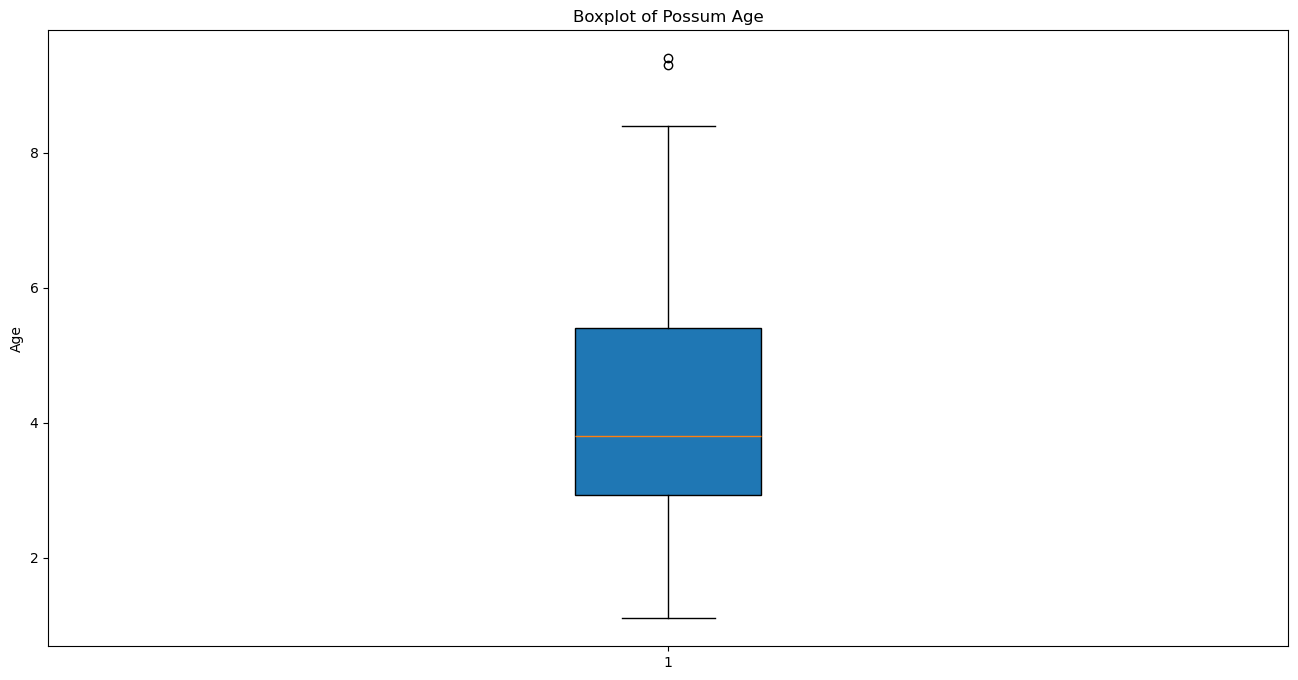

count    104.000000
mean       4.189423
std        1.902281
min        1.100000
25%        2.925000
50%        3.800000
75%        5.400000
max        9.400000
Name: age, dtype: float64

In [72]:
# Create boxplots of age column to identify outliers
plt.figure(figsize=(16, 8))
plt.boxplot(possum['age'], patch_artist=True)
plt.title('Boxplot of Possum Age')
plt.ylabel('Age')
plt.show()

#Show the descriptive statistics of the age column
possum['age'].describe()

In [73]:
#Calculate the median for age column
median_age = possum['age'].median()
median_age

3.8

In [74]:
#caluclate 25th percentile of age column
percentile25_age = possum['age'].quantile(0.25)
print('percentile25_age ', percentile25_age)

#caluclate 75th percentile of age column
percentile75_age = possum['age'].quantile(0.75)
print('percentile75_age ', percentile75_age)

percentile25_age  2.925
percentile75_age  5.4


In [75]:
#Calculate interquartile range of age column
iqr_age = percentile75_age - percentile25_age
print(iqr_age)

#Calculate upper and lower thresholds for outliers of age column
upper_limit_age = percentile75_age + 1.5 *iqr_age
lower_limit_age = percentile25_age - 1.5 *iqr_age

#Show upper and lower limit:
print ('Upper limit of age is: ' + str(upper_limit_age))
print ('Lower limit of age is: ' + str(lower_limit_age))

2.4750000000000005
Upper limit of age is: 9.1125
Lower limit of age is: -0.787500000000001


In [76]:
#isolate outliers lower than the lower limit of age column
lower_age = possum[possum['age'] < lower_limit_age]
lower_age

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly


In [77]:
#isolate outliers higher than the upper limit of age column
upper_age = possum[possum['age'] > upper_limit_age]
upper_age

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
8,9.0,1.0,Vic,f,9.3,93.4,56.3,91.5,37.0,72.4,52.9,15.5,28.0,33.0
10,11.0,1.0,Vic,f,9.4,93.3,57.2,89.5,39.0,77.2,51.3,14.9,31.0,34.0


In [78]:
#group the upper outliers of age column to list 
outliers_age_upper = upper_age['age'].tolist()
outliers_age_upper

#fix the outliers by replacing them with median of age column
possum['age'].replace(outliers_age_upper, median_age, inplace=True)

/var/folders/b1/2lz6ssmx4n52cww0tsc3hhg80000gn/T/ipykernel_72559/1826797251.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  possum['age'].replace(outliers_age_upper, median_age, inplace=True)


In [79]:
#Check the upper outliers to confirm the replace
upper_age = possum[possum['age'] > upper_limit_age]
upper_age

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly


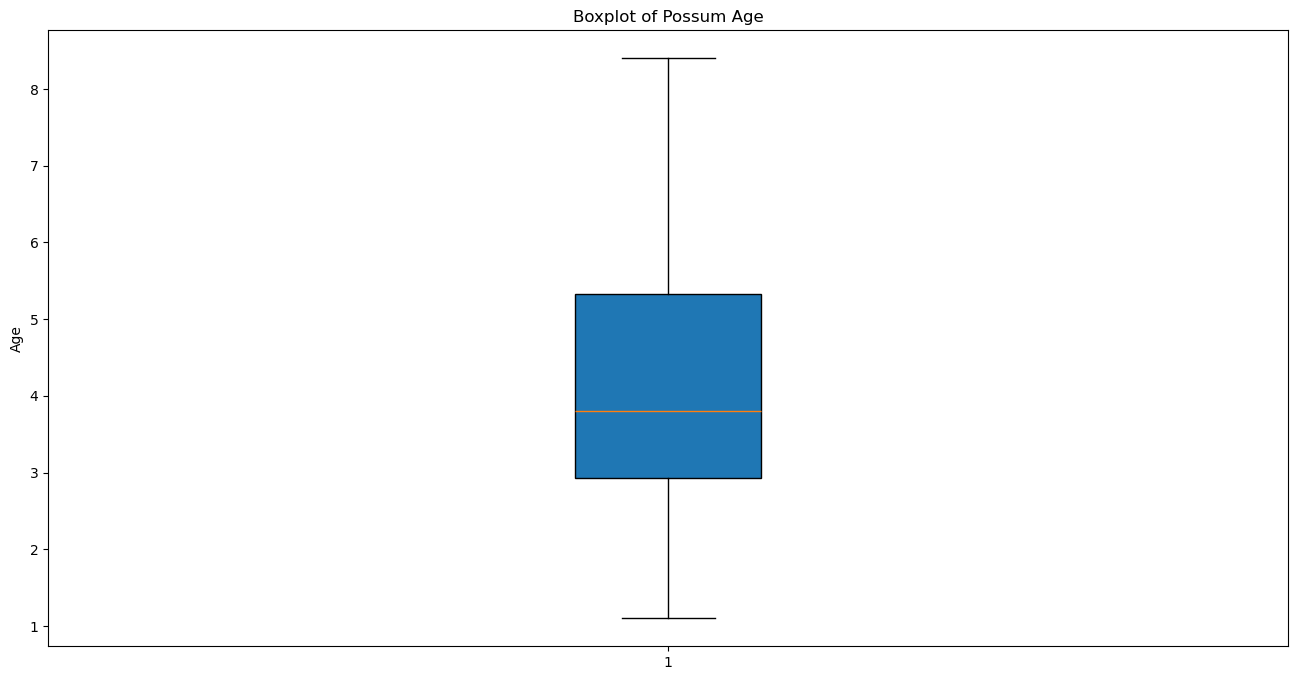

count    104.000000
mean       4.082692
std        1.758678
min        1.100000
25%        2.925000
50%        3.800000
75%        5.325000
max        8.400000
Name: age, dtype: float64

In [80]:
# Create boxplots of age column to further identify outliers
plt.figure(figsize=(16, 8))
plt.boxplot(possum['age'], patch_artist=True)
plt.title('Boxplot of Possum Age')
plt.ylabel('Age')
plt.show()

#Show the descriptive statistics of the age column
possum['age'].describe()

### Outliers- Head Length Column

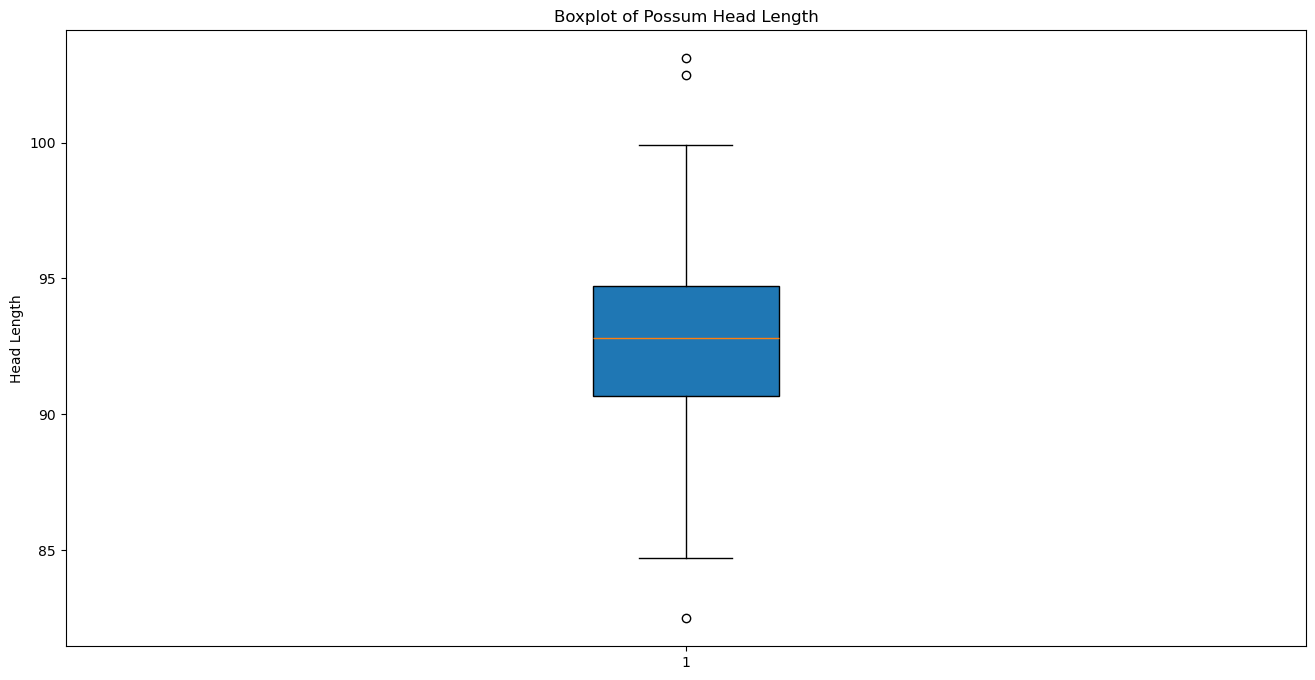

count    104.000000
mean      92.591346
std        3.592849
min       82.500000
25%       90.675000
50%       92.800000
75%       94.725000
max      103.100000
Name: hdlngth, dtype: float64

In [81]:
# Create boxplots of Headlength column to identify outliers
plt.figure(figsize=(16, 8))
plt.boxplot(possum['hdlngth'], patch_artist=True)
plt.title('Boxplot of Possum Head Length')
plt.ylabel('Head Length')
plt.show()

#Show the descriptive statistics of the head length column
possum['hdlngth'].describe()

In [82]:
#Calculate the median of head length
median_hdlngth = possum['hdlngth'].median()
median_hdlngth

92.8

In [83]:
#caluclate 25th percentile of head length column
percentile25_hdlngth = possum['hdlngth'].quantile(0.25)
print('percentile25_hdlngth', percentile25_hdlngth)

#caluclate 75th percentile of head length column
percentile75_hdlngth = possum['hdlngth'].quantile(0.75)
print('percentile75_hdlngth', percentile75_hdlngth)

percentile25_hdlngth 90.675
percentile75_hdlngth 94.725


In [84]:
#Calculate interquartile range of head length column
iqr_hdlngth = percentile75_hdlngth - percentile25_hdlngth
print(iqr_hdlngth)

#Calculate upper and lower thresholds for outliers of head length column
upper_limit_hdlngth = percentile75_hdlngth + 1.5 *iqr_hdlngth
lower_limit_hdlngth = percentile25_hdlngth - 1.5 *iqr_hdlngth

#Show upper and lower limit:
print ('Upper limit of head length is: ' + str(upper_limit_hdlngth))
print ('Lower limit of head length is: ' + str(lower_limit_hdlngth))

4.049999999999997
Upper limit of head length is: 100.79999999999998
Lower limit of head length is: 84.6


In [85]:
#isolate outliers lower than the lower limit of head length column
lower_hdlngth = possum[possum['hdlngth'] < lower_limit_hdlngth]
lower_hdlngth

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
72,73.0,5.0,other,m,1.5,82.5,52.3,82.0,36.5,65.7,44.7,16.0,23.5,28.0


In [86]:
#group the lower outliers of head length column to list 
outliers_hdlngth_lower = lower_hdlngth['hdlngth'].tolist()
outliers_hdlngth_lower

#fix the outliers by replacing them with median of head length column
possum['hdlngth'].replace(outliers_hdlngth_lower, median_hdlngth, inplace=True)

/var/folders/b1/2lz6ssmx4n52cww0tsc3hhg80000gn/T/ipykernel_72559/2321142412.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  possum['hdlngth'].replace(outliers_hdlngth_lower, median_hdlngth, inplace=True)


In [87]:
#Check the lower outliers to confirm the replace
lower_hdlngth = possum[possum['hdlngth'] < lower_limit_hdlngth]
lower_hdlngth

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly


In [88]:
#isolate outliers higher than the upper limit of head length
upper_hdlngth = possum[possum['hdlngth'] > upper_limit_hdlngth]
upper_hdlngth

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
54,55.0,4.0,other,m,2.6,103.1,63.2,92.5,38.0,72.5,44.9,16.4,30.5,36.0
58,59.0,4.0,other,m,2.3,102.5,62.8,96.0,40.0,73.2,44.5,14.7,32.0,36.0


In [89]:
#group the upper outliers of head length to list 
outliers_hdlngth_upper = upper_hdlngth['hdlngth'].tolist()
outliers_hdlngth_upper

#fix the outliers by replacing them with median of head length
possum['hdlngth'].replace(outliers_hdlngth_upper, median_hdlngth, inplace=True)

/var/folders/b1/2lz6ssmx4n52cww0tsc3hhg80000gn/T/ipykernel_72559/2553793064.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  possum['hdlngth'].replace(outliers_hdlngth_upper, median_hdlngth, inplace=True)


In [90]:
#Check the upper outliers to confirm the replace
upper_hdlngth = possum[possum['hdlngth'] > upper_limit_hdlngth]
upper_hdlngth

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly


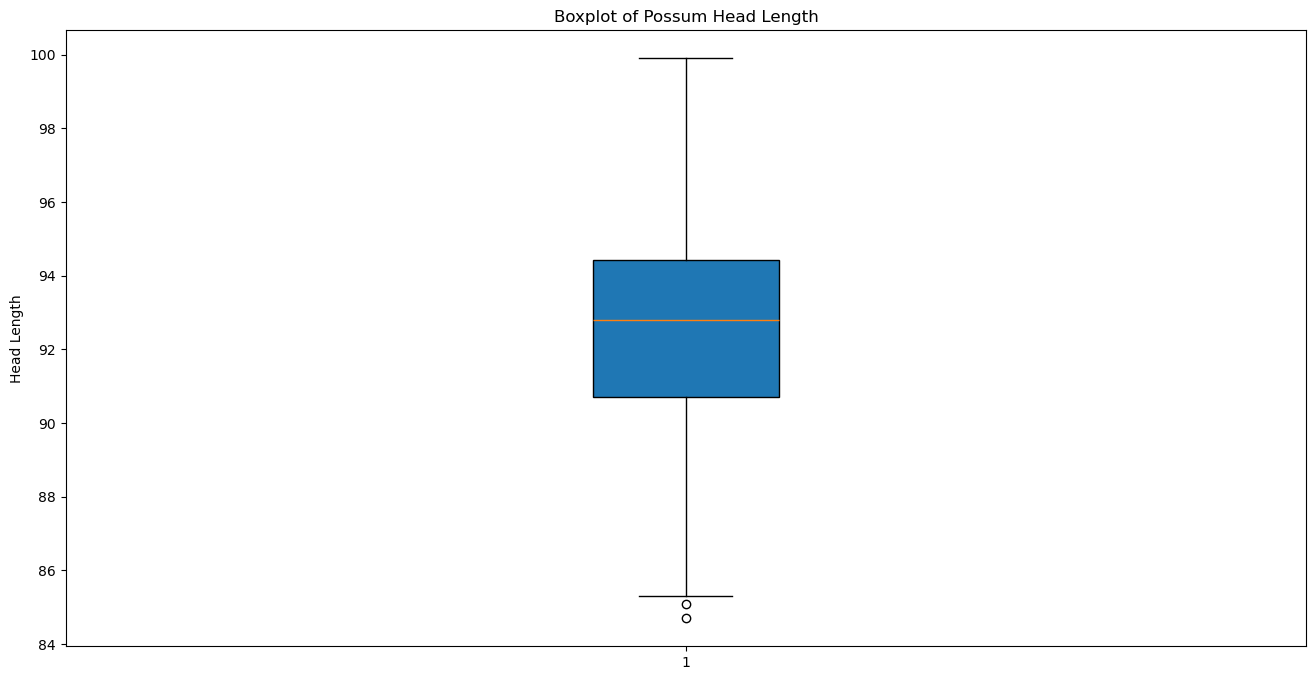

count    104.000000
mean      92.498077
std        3.144358
min       84.700000
25%       90.700000
50%       92.800000
75%       94.425000
max       99.900000
Name: hdlngth, dtype: float64

In [91]:
# Create boxplots of Headlength column to  further identify outliers
plt.figure(figsize=(16, 8))
plt.boxplot(possum['hdlngth'], patch_artist=True)
plt.title('Boxplot of Possum Head Length')
plt.ylabel('Head Length')
plt.show()

#Show the descriptive statistics of the head length column
possum['hdlngth'].describe()

In [92]:
#Calculate the median of the head length
median_hdlngth_1 = possum['hdlngth'].median()
median_hdlngth_1

92.8

In [93]:
#caluclate 25th percentile of head length column
percentile25_hdlngth_1 = possum['hdlngth'].quantile(0.25)
print('percentile25_hdlngth_1', percentile25_hdlngth_1)

#caluclate 75th percentile of head length column
percentile75_hdlngth_1 = possum['hdlngth'].quantile(0.75)
print('percentile75_hdlngth_1', percentile75_hdlngth_1)

percentile25_hdlngth_1 90.7
percentile75_hdlngth_1 94.42500000000001


In [94]:
#Calculate interquartile range of head length column
iqr_hdlngth_1 = percentile75_hdlngth_1 - percentile25_hdlngth_1
print(iqr_hdlngth_1)

#Calculate upper and lower thresholds for outliers of head length column
upper_limit_hdlngth_1 = percentile75_hdlngth_1 + 1.5 *iqr_hdlngth_1
lower_limit_hdlngth_1 = percentile25_hdlngth_1 - 1.5 *iqr_hdlngth_1

#Show upper and lower limit:
print ('Upper limit of head length is: ' + str(upper_limit_hdlngth_1))
print ('Lower limit of head length is: ' + str(lower_limit_hdlngth_1))

3.7250000000000085
Upper limit of head length is: 100.01250000000002
Lower limit of head length is: 85.11249999999998


In [95]:
#isolate outliers lower than the lower limit of head length column
lower_hdlngth_1 = possum[possum['hdlngth'] < lower_limit_hdlngth_1]
lower_hdlngth_1

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
38,39.0,2.0,Vic,f,1.30,84.7,51.5,75.0,34.0,68.7,53.4,13.0,25.0,25.0
43,44.0,2.0,Vic,m,3.95,85.1,51.5,76.0,35.5,70.3,52.6,14.4,23.0,27.0


In [96]:
#group the lower outliers of head length to list
outliers_hdlngth_lower_1 = lower_hdlngth_1['hdlngth'].tolist()
outliers_hdlngth_lower_1

#fix the outliers by replacing them with median of head length column
possum['hdlngth'].replace(outliers_hdlngth_lower_1, median_hdlngth_1, inplace=True)

/var/folders/b1/2lz6ssmx4n52cww0tsc3hhg80000gn/T/ipykernel_72559/3260585421.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  possum['hdlngth'].replace(outliers_hdlngth_lower_1, median_hdlngth_1, inplace=True)


In [97]:
#Check the lower outliers to confirm the replace
lower_hdlngth_1 = possum[possum['hdlngth'] < lower_limit_hdlngth_1]
lower_hdlngth_1

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly


In [98]:
#isolate outliers higher than the upper limit of head length
upper_hdlngth_1 = possum[possum['hdlngth'] > upper_limit_hdlngth_1]
upper_hdlngth_1

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly


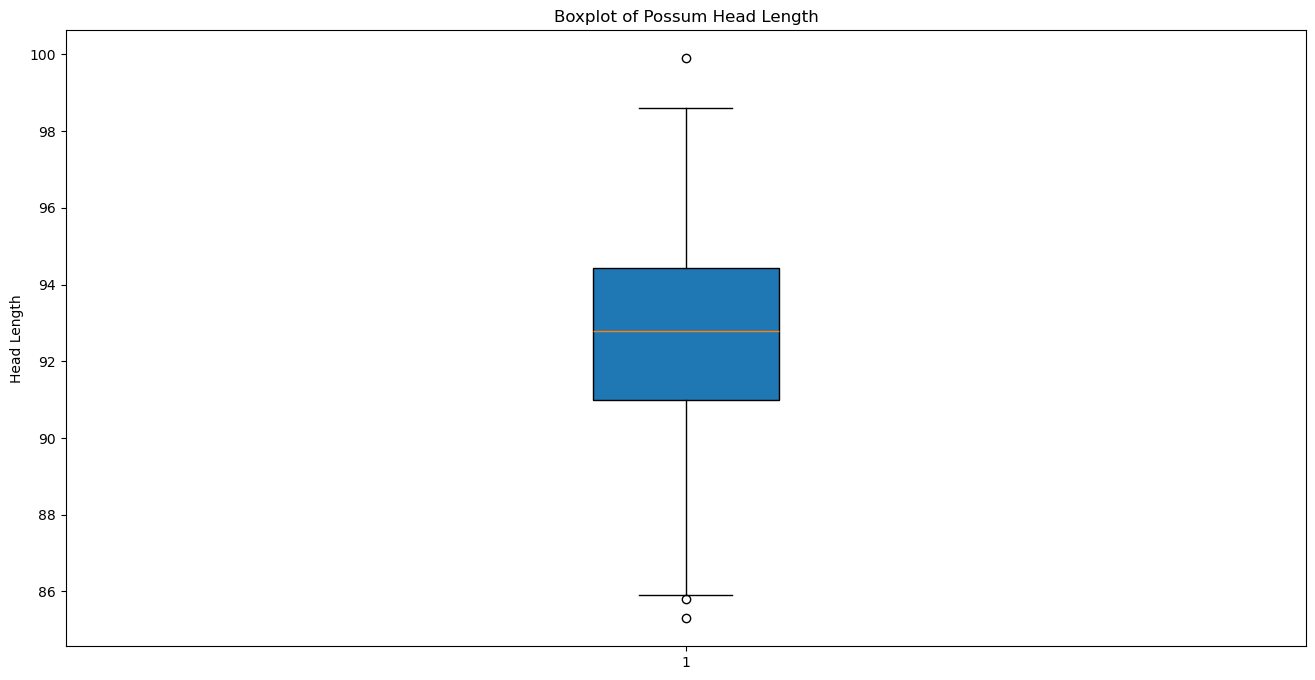

count    104.000000
mean      92.650000
std        2.956973
min       85.300000
25%       91.000000
50%       92.800000
75%       94.425000
max       99.900000
Name: hdlngth, dtype: float64

In [99]:
# Create boxplots of Headlength column to further identify outliers
plt.figure(figsize=(16, 8))
plt.boxplot(possum['hdlngth'], patch_artist=True)
plt.title('Boxplot of Possum Head Length')
plt.ylabel('Head Length')
plt.show()

#Show the descriptive statistics of the head length column
possum['hdlngth'].describe()

In [100]:
#Calculate the median of the head length
median_hdlngth_2 = possum['hdlngth'].median()
median_hdlngth_2

92.8

In [101]:
#caluclate 25th percentile of head length column
percentile25_hdlngth_2 = possum['hdlngth'].quantile(0.25)
print('percentile25_hdlngth_2', percentile25_hdlngth_2)

#caluclate 75th percentile of head length column
percentile75_hdlngth_2 = possum['hdlngth'].quantile(0.75)
print('percentile75_hdlngth_2', percentile75_hdlngth_2)

percentile25_hdlngth_2 91.0
percentile75_hdlngth_2 94.42500000000001


In [102]:
#Calculate interquartile range of head length column
iqr_hdlngth_2 = percentile75_hdlngth_2 - percentile25_hdlngth_2
print(iqr_hdlngth_2)

#Calculate upper and lower thresholds for outliers of head length column
upper_limit_hdlngth_2 = percentile75_hdlngth_2 + 1.5 *iqr_hdlngth_2
lower_limit_hdlngth_2 = percentile25_hdlngth_2 - 1.5 *iqr_hdlngth_2

#Show upper and lower limit:
print ('Upper limit of head length is: ' + str(upper_limit_hdlngth_2))
print ('Lower limit of head length is: ' + str(lower_limit_hdlngth_2))

3.4250000000000114
Upper limit of head length is: 99.56250000000003
Lower limit of head length is: 85.86249999999998


In [103]:
#isolate outliers lower than the lower limit of head length column
lower_hdlngth_2 = possum[possum['hdlngth'] < lower_limit_hdlngth_2]
lower_hdlngth_2

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
41,42.0,2.0,Vic,m,3.95,85.3,54.1,77.0,32.0,62.7,51.2,13.8,25.5,33.0
78,79.0,6.0,other,m,1.40,85.8,50.0,81.0,36.5,62.8,43.0,14.8,22.0,28.5


In [104]:
#group the lower outliers of head length to list
outliers_hdlngth_lower_2 = lower_hdlngth_2['hdlngth'].tolist()
outliers_hdlngth_lower_2

#fix the outliers by replacing them with median of head length column
possum['hdlngth'].replace(outliers_hdlngth_lower_2, median_hdlngth_2, inplace=True)

/var/folders/b1/2lz6ssmx4n52cww0tsc3hhg80000gn/T/ipykernel_72559/2103724400.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  possum['hdlngth'].replace(outliers_hdlngth_lower_2, median_hdlngth_2, inplace=True)


In [105]:
#Check the lower outliers to confirm the replace
lower_hdlngth_2 = possum[possum['hdlngth'] < lower_limit_hdlngth_2]
lower_hdlngth_2

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly


In [106]:
#isolate outliers higher than the upper limit of head length column
upper_hdlngth_2 = possum[possum['hdlngth'] > upper_limit_hdlngth_2]
upper_hdlngth_2

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
55,56.0,4.0,other,m,3.8,99.9,61.5,93.7,38.0,68.7,46.8,16.4,27.5,31.5


In [107]:
#group the upper outliers of head length to list
outliers_hdlngth_upper_2 = upper_hdlngth_2['hdlngth'].tolist()
outliers_hdlngth_upper_2

#fix the outliers by replacing them with median of head length column
possum['hdlngth'].replace(outliers_hdlngth_upper_2, median_hdlngth_2, inplace=True)

/var/folders/b1/2lz6ssmx4n52cww0tsc3hhg80000gn/T/ipykernel_72559/2186353044.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  possum['hdlngth'].replace(outliers_hdlngth_upper_2, median_hdlngth_2, inplace=True)


In [108]:
#Check the upper outliers to confirm the replace
upper_hdlngth_2 = possum[possum['hdlngth'] > upper_limit_hdlngth_2]
upper_hdlngth_2

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly


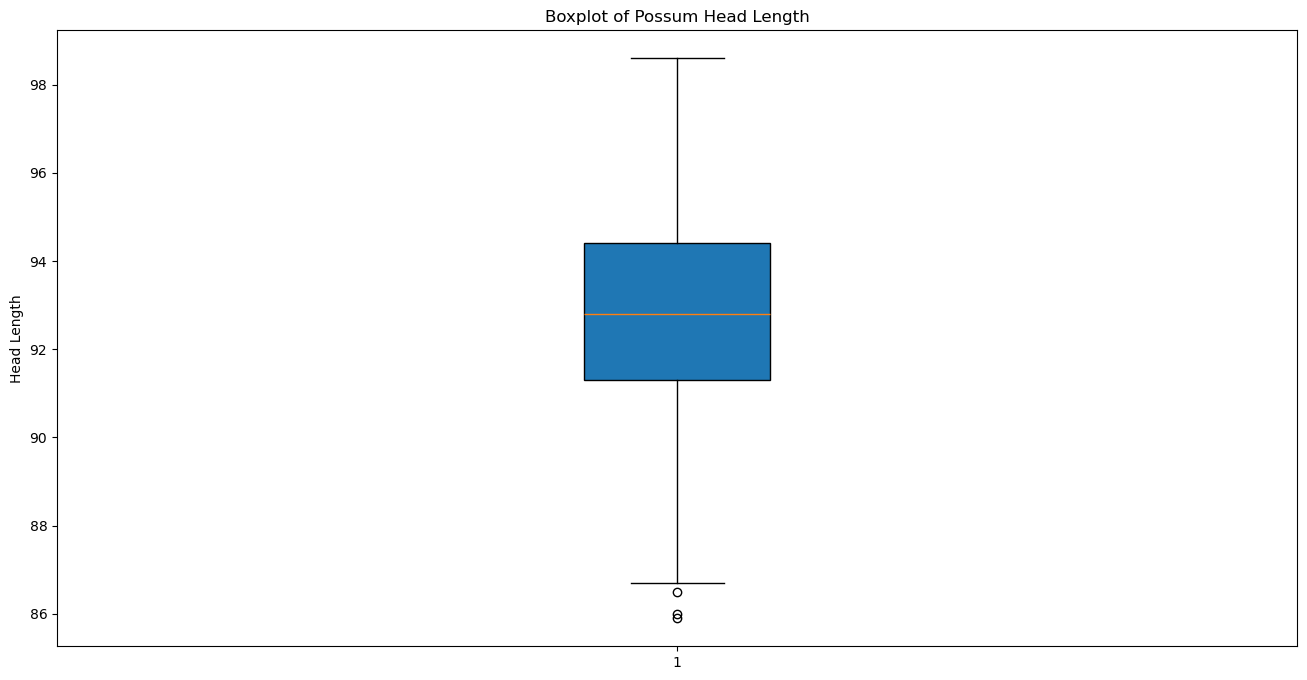

count    104.000000
mean      92.721154
std        2.692372
min       85.900000
25%       91.300000
50%       92.800000
75%       94.400000
max       98.600000
Name: hdlngth, dtype: float64

In [109]:
# Create boxplots of Headlength column to further identify outliers
plt.figure(figsize=(16, 8))
plt.boxplot(possum['hdlngth'], patch_artist=True)
plt.title('Boxplot of Possum Head Length')
plt.ylabel('Head Length')
plt.show()

#Show the descriptive statistics of the head length
possum['hdlngth'].describe()

In [110]:
#Calculate the median of the head length
median_hdlngth_3 = possum['hdlngth'].median()
median_hdlngth_3

92.8

In [111]:
#caluclate 25th percentile of head length column
percentile25_hdlngth_3 = possum['hdlngth'].quantile(0.25)
print('percentile25_hdlngth_3', percentile25_hdlngth_3)

#caluclate 75th percentile of head length column
percentile75_hdlngth_3 = possum['hdlngth'].quantile(0.75)
print('percentile75_hdlngth_3', percentile75_hdlngth_3)

percentile25_hdlngth_3 91.3
percentile75_hdlngth_3 94.4


In [112]:
#Calculate interquartile range of head length column
iqr_hdlngth_3 = percentile75_hdlngth_3 - percentile25_hdlngth_3
print(iqr_hdlngth_3)

#Calculate upper and lower thresholds for outliers of head length column
upper_limit_hdlngth_3 = percentile75_hdlngth_3 + 1.5 *iqr_hdlngth_3
lower_limit_hdlngth_3 = percentile25_hdlngth_3 - 1.5 *iqr_hdlngth_3

#Show upper and lower limit:
print ('Upper limit of head length is: ' + str(upper_limit_hdlngth_3))
print ('Lower limit of head length is: ' + str(lower_limit_hdlngth_3))

3.1000000000000085
Upper limit of head length is: 99.05000000000001
Lower limit of head length is: 86.64999999999998


In [113]:
#isolate outliers lower than the lower limit of head length column
lower_hdlngth_3 = possum[possum['hdlngth'] < lower_limit_hdlngth_3]
lower_hdlngth_3

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
71,72.0,5.0,other,m,1.3,85.9,52.4,80.5,35.0,62.0,42.4,14.1,25.5,30.0
77,78.0,6.0,other,m,1.6,86.5,51.0,81.0,36.5,63.0,44.3,13.2,23.0,28.0
81,82.0,6.0,other,f,4.9,86.0,54.0,82.0,36.5,60.7,42.9,15.4,26.0,32.0


In [114]:
#group the lower outliers of head length to list
outliers_hdlngth_lower_3 = lower_hdlngth_3['hdlngth'].tolist()
outliers_hdlngth_lower_3

#fix the outliers by replacing them with median of head length column
possum['hdlngth'].replace(outliers_hdlngth_lower_3, median_hdlngth_3, inplace=True)

/var/folders/b1/2lz6ssmx4n52cww0tsc3hhg80000gn/T/ipykernel_72559/2808383047.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  possum['hdlngth'].replace(outliers_hdlngth_lower_3, median_hdlngth_3, inplace=True)


In [115]:
#Check the lower outliers to confirm the replace
lower_hdlngth_3 = possum[possum['hdlngth'] < lower_limit_hdlngth_3]
lower_hdlngth_3

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly


In [116]:
#isolate outliers higher than the upper limit of head length
upper_hdlngth_3 = possum[possum['hdlngth'] > upper_limit_hdlngth_3]
upper_hdlngth_3

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly


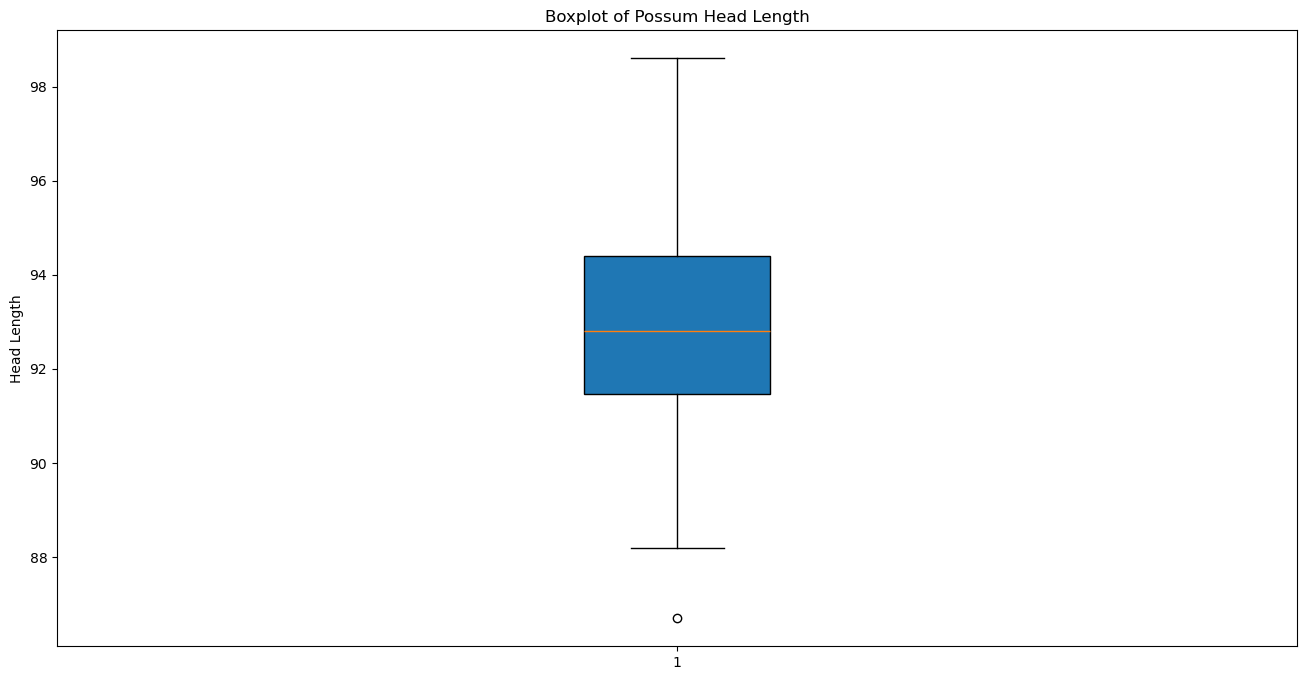

count    104.000000
mean      92.913462
std        2.438369
min       86.700000
25%       91.475000
50%       92.800000
75%       94.400000
max       98.600000
Name: hdlngth, dtype: float64

In [117]:
# Create boxplots of Headlength column to further identify outliers
plt.figure(figsize=(16, 8))
plt.boxplot(possum['hdlngth'], patch_artist=True)
plt.title('Boxplot of Possum Head Length')
plt.ylabel('Head Length')
plt.show()

#Show the descriptive statistics of the head length column
possum['hdlngth'].describe()

In [118]:
#Calculate the median of the head length column
median_hdlngth_4 = possum['hdlngth'].median()
median_hdlngth_4

92.8

In [119]:
#caluclate 25th percentile of head length column
percentile25_hdlngth_4 = possum['hdlngth'].quantile(0.25)
print('percentile25_hdlngth_4', percentile25_hdlngth_4)

#caluclate 75th percentile of head length column
percentile75_hdlngth_4 = possum['hdlngth'].quantile(0.75)
print('percentile75_hdlngth_4', percentile75_hdlngth_4)

percentile25_hdlngth_4 91.475
percentile75_hdlngth_4 94.4


In [120]:
#Calculate interquartile range of head length column
iqr_hdlngth_4 = percentile75_hdlngth_4 - percentile25_hdlngth_4
print(iqr_hdlngth_4)

#Calculate upper and lower thresholds for outliers of head length column
upper_limit_hdlngth_4 = percentile75_hdlngth_4 + 1.5 *iqr_hdlngth_4
lower_limit_hdlngth_4 = percentile25_hdlngth_4 - 1.5 *iqr_hdlngth_4

#Show upper and lower limit:
print ('Upper limit of head length is: ' + str(upper_limit_hdlngth_4))
print ('Lower limit of head length is: ' + str(lower_limit_hdlngth_4))

2.9250000000000114
Upper limit of head length is: 98.78750000000002
Lower limit of head length is: 87.08749999999998


In [121]:
#isolate outliers lower than the lower limit of head length column
lower_hdlngth_4 = possum[possum['hdlngth'] < lower_limit_hdlngth_4]
lower_hdlngth_4

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
79,80.0,6.0,other,m,1.6,86.7,52.6,84.0,38.0,62.3,44.8,16.25,23.5,30.5


In [122]:
#group the lower outliers of head length to list
outliers_hdlngth_lower_4 = lower_hdlngth_4['hdlngth'].tolist()
outliers_hdlngth_lower_4

#fix the outliers by replacing them with median of head length column
possum['hdlngth'].replace(outliers_hdlngth_lower_4, median_hdlngth_4, inplace=True)

/var/folders/b1/2lz6ssmx4n52cww0tsc3hhg80000gn/T/ipykernel_72559/1632798707.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  possum['hdlngth'].replace(outliers_hdlngth_lower_4, median_hdlngth_4, inplace=True)


In [123]:
#Check the lower outliers to confirm the replace
lower_hdlngth_4 = possum[possum['hdlngth'] < lower_limit_hdlngth_4]
lower_hdlngth_4

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly


In [124]:
#isolate outliers higher than the upper limit of head length
upper_hdlngth_4 = possum[possum['hdlngth'] > upper_limit_hdlngth_4]
upper_hdlngth_4

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly


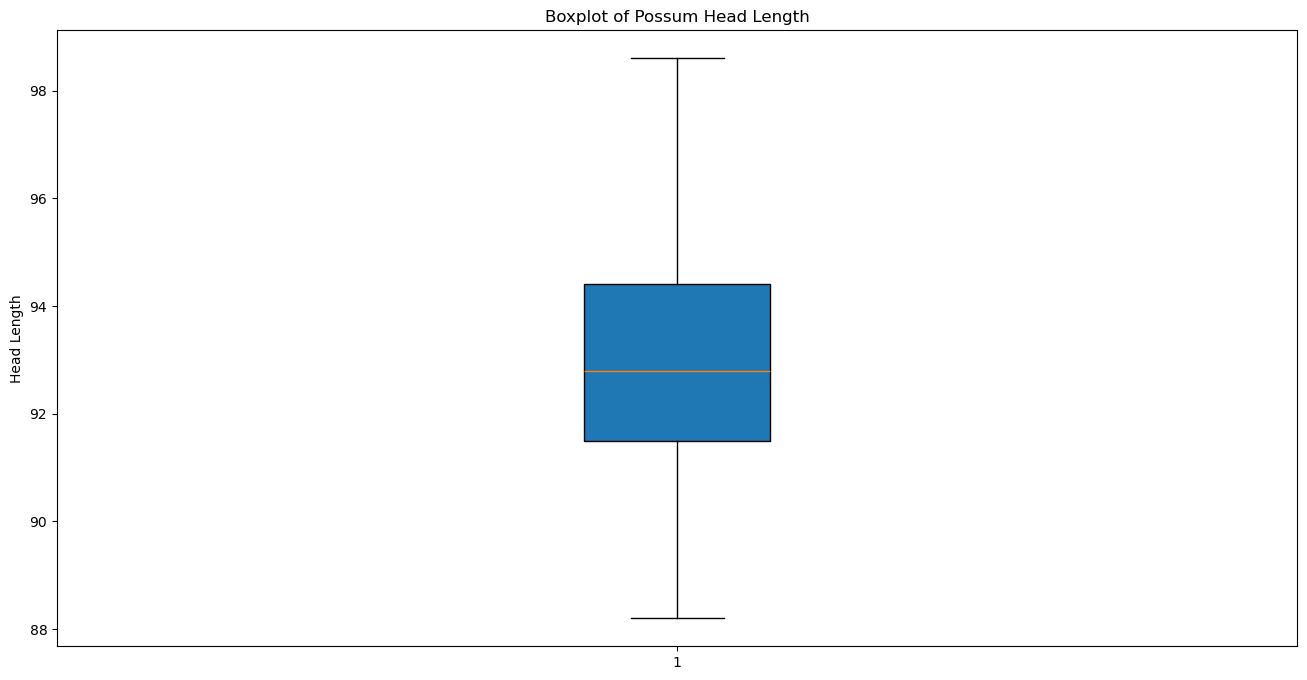

count    104.000000
mean      92.972115
std        2.359548
min       88.200000
25%       91.500000
50%       92.800000
75%       94.400000
max       98.600000
Name: hdlngth, dtype: float64

In [125]:
# Create boxplots of Headlength column to further identify outliers
plt.figure(figsize=(16, 8))
plt.boxplot(possum['hdlngth'], patch_artist=True)
plt.title('Boxplot of Possum Head Length')
plt.ylabel('Head Length')
plt.show()

#Show the descriptive statistics of the head length
possum['hdlngth'].describe()

### Outliers- Skull Width Column

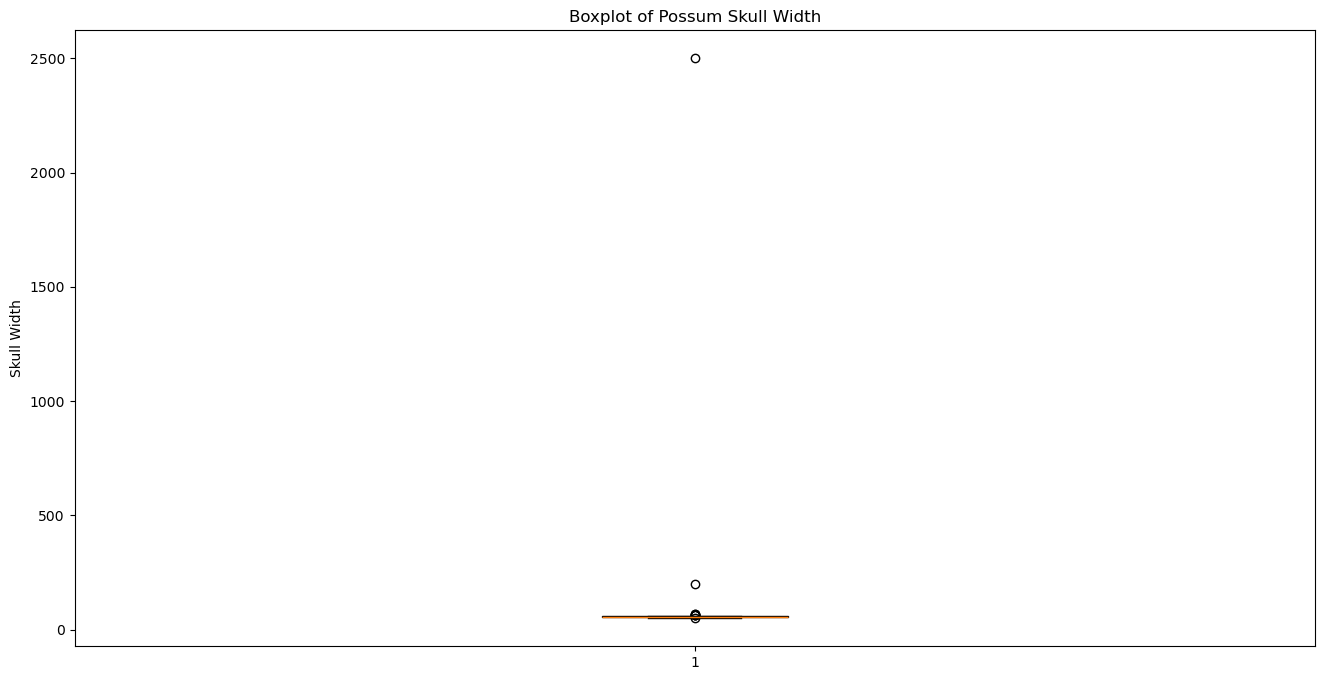

count     104.000000
mean       81.645673
std       239.871759
min        50.000000
25%        54.975000
50%        56.350000
75%        58.100000
max      2500.000000
Name: skullw, dtype: float64

In [126]:
# Create boxplots of Skull Width column to identify outliers
plt.figure(figsize=(16, 8))
plt.boxplot(possum['skullw'], patch_artist=True)
plt.title('Boxplot of Possum Skull Width')
plt.ylabel('Skull Width')
plt.show()

#Show the descriptive statistics of the skull width column
possum['skullw'].describe()

In [127]:
#Calculate the median of skull width column
median_skullw = possum['skullw'].median()
median_skullw

56.349999999999994

In [128]:
#caluclate 25th percentile of skull width column
percentile25_skullw = possum['skullw'].quantile(0.25)
print('percentile25_skullw', percentile25_skullw)

#caluclate 75th percentile of skull width column
percentile75_skullw = possum['skullw'].quantile(0.75)
print('percentile75_skullw', percentile75_skullw)

percentile25_skullw 54.975
percentile75_skullw 58.1


In [129]:
#Calculate interquartile range of skull width column
iqr_skullw = percentile75_skullw - percentile25_skullw
print(iqr_skullw)

#Calculate upper and lower thresholds for outliers of skull width column
upper_limit_skullw = percentile75_skullw + 1.5 *iqr_skullw
lower_limit_skullw = percentile25_skullw - 1.5 *iqr_skullw

#Show upper and lower limit:
print ('Upper limit of skull width is: ' + str(upper_limit_skullw))
print ('Lower limit of skull width is: ' + str(lower_limit_skullw))

3.125
Upper limit of skull width is: 62.7875
Lower limit of skull width is: 50.2875


In [130]:
#isolate outliers lower than the lower limit of skull width column
lower_skullw = possum[possum['skullw'] < lower_limit_skullw]
lower_skullw

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
78,79.0,6.0,other,m,1.4,92.8,50.0,81.0,36.5,62.8,43.0,14.8,22.0,28.5


In [131]:
#group the lower outliers of skull width to list
outliers_skullw_lower = lower_skullw['skullw'].tolist()
outliers_skullw_lower

#fixing the outliers by replacing with the median of skull width column
possum['skullw'].replace(outliers_skullw_lower, median_skullw, inplace=True)

/var/folders/b1/2lz6ssmx4n52cww0tsc3hhg80000gn/T/ipykernel_72559/2250417955.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  possum['skullw'].replace(outliers_skullw_lower, median_skullw, inplace=True)


In [132]:
#Check the lower outliers to confirm the replace
lower_skullw = possum[possum['skullw'] < lower_limit_skullw]
lower_skullw

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly


In [133]:
#isolate outliers higher than the upper limit of skull width column
upper_skullw = possum[possum['skullw'] > upper_limit_skullw]
upper_skullw

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
16,17.0,1.0,Vic,f,1.2,94.7,67.7,90.5,36.5,73.2,53.2,14.7,29.0,31.0
47,48.0,3.0,other,m,5.2,98.6,63.2,85.0,34.0,66.9,44.9,17.0,28.0,35.0
53,54.0,4.0,other,m,7.8,96.9,2500.0,91.5,43.0,71.3,46.0,17.5,30.0,36.5
54,55.0,4.0,other,m,2.6,92.8,63.2,92.5,38.0,72.5,44.9,16.4,30.5,36.0
57,58.0,4.0,other,m,3.7,94.5,63.0,91.0,39.0,66.5,-14.0,14.4,30.5,33.0
58,59.0,4.0,other,m,2.3,92.8,62.8,96.0,40.0,73.2,44.5,14.7,32.0,36.0
80,81.0,6.0,other,m,3.7,90.6,200.0,85.5,38.0,65.6,41.7,17.0,27.5,35.0
97,98.0,7.0,other,m,5.2,93.2,68.6,84.0,35.0,65.6,44.3,14.5,28.5,32.0


In [134]:
#group the upper outliers of skull width to list
outliers_skullw_upper = upper_skullw['skullw'].tolist()
outliers_skullw_upper

#fixing the outliers by replacing with the median of skull width column
possum['skullw'].replace(outliers_skullw_upper, median_skullw, inplace=True)

/var/folders/b1/2lz6ssmx4n52cww0tsc3hhg80000gn/T/ipykernel_72559/2877637852.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  possum['skullw'].replace(outliers_skullw_upper, median_skullw, inplace=True)


In [135]:
#Check the upper outliers to confirm the replace
upper_skullw = possum[possum['skullw'] > upper_limit_skullw]
upper_skullw

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly


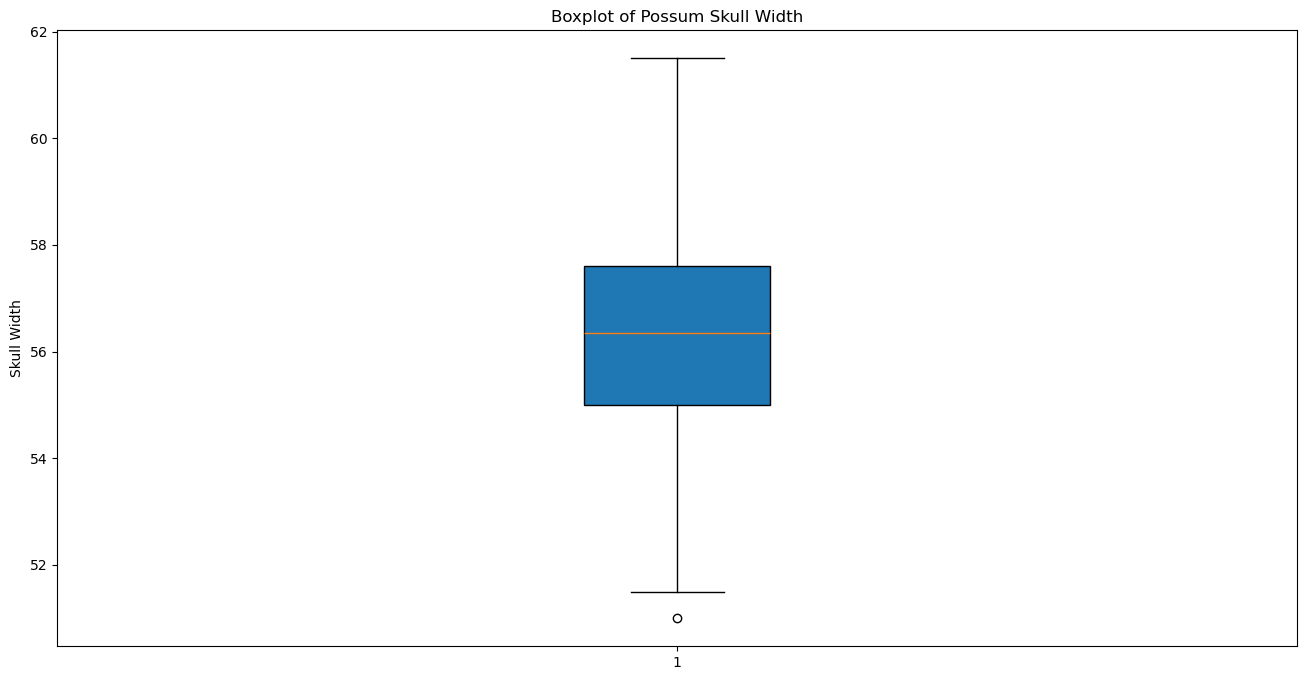

count    104.000000
mean      56.344231
std        2.086786
min       51.000000
25%       55.000000
50%       56.350000
75%       57.600000
max       61.500000
Name: skullw, dtype: float64

In [136]:
# Create boxplots of skull width column to further identify outliers
plt.figure(figsize=(16, 8))
plt.boxplot(possum['skullw'], patch_artist=True)
plt.title('Boxplot of Possum Skull Width')
plt.ylabel('Skull Width')
plt.show()

#Show the descriptive statistics of the skull width
possum['skullw'].describe()

In [137]:
#Calculate the median of skull width column
median_skullw_1 = possum['skullw'].median()
median_skullw_1

56.349999999999994

In [138]:
#caluclate 25th percentile of skull width column
percentile25_skullw_1 = possum['skullw'].quantile(0.25)
print('percentile25_skullw_1', percentile25_skullw_1)

#caluclate 75th percentile of skull width column
percentile75_skullw_1 = possum['skullw'].quantile(0.75)
print('percentile75_skullw_1', percentile75_skullw_1)

percentile25_skullw_1 55.0
percentile75_skullw_1 57.6


In [139]:
#Calculate interquartile range of skull width column
iqr_skullw_1 = percentile75_skullw_1 - percentile25_skullw_1
print(iqr_skullw_1)

#Calculate upper and lower thresholds for outliers of skull width column
upper_limit_skullw_1 = percentile75_skullw_1 + 1.5 *iqr_skullw_1
lower_limit_skullw_1 = percentile25_skullw_1 - 1.5 *iqr_skullw_1

#Show upper and lower limit:
print ('Upper limit of skull width is: ' + str(upper_limit_skullw_1))
print ('Lower limit of skull width is: ' + str(lower_limit_skullw_1))

2.6000000000000014
Upper limit of skull width is: 61.5
Lower limit of skull width is: 51.099999999999994


In [140]:
#isolate the outliers lower than the lower limit
lower_skullw_1 = possum[possum['skullw'] < lower_limit_skullw_1]
lower_skullw_1

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
77,78.0,6.0,other,m,1.6,92.8,51.0,81.0,36.5,63.0,44.3,13.2,23.0,28.0


In [141]:
#group the lower outliers of skull width to list
outliers_skullw_lower_1 = lower_skullw_1['skullw'].tolist()
outliers_skullw_lower_1

#fixing the outliers by replacing with the skull width median
possum['skullw'].replace(outliers_skullw_lower_1, median_skullw_1, inplace=True)

/var/folders/b1/2lz6ssmx4n52cww0tsc3hhg80000gn/T/ipykernel_72559/4250351020.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  possum['skullw'].replace(outliers_skullw_lower_1, median_skullw_1, inplace=True)


In [142]:
#Check the lower outliers to confirm the replace
lower_skullw_1 = possum[possum['skullw'] < lower_limit_skullw_1]
lower_skullw_1

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly


In [143]:
#isolate the outliers higher than the upper limit
upper_skullw_1 = possum[possum['skullw'] > upper_limit_skullw_1]
upper_skullw_1

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly


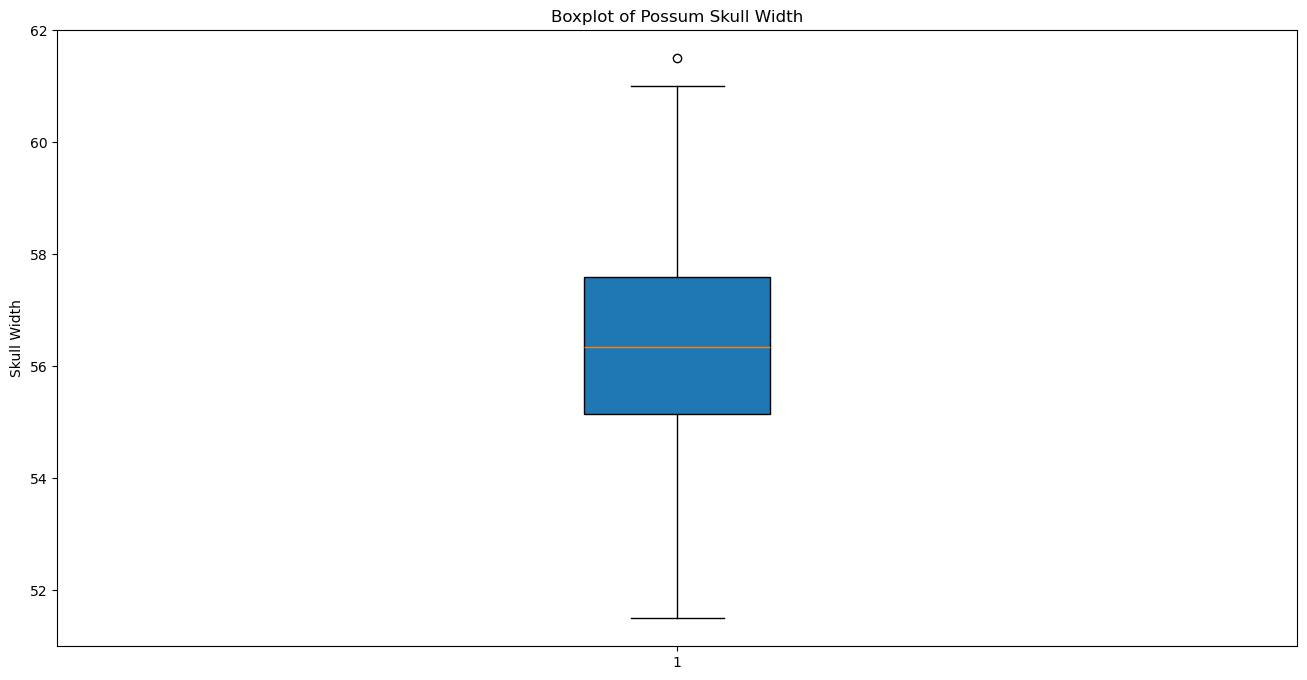

count    104.000000
mean      56.395673
std        2.018592
min       51.500000
25%       55.150000
50%       56.350000
75%       57.600000
max       61.500000
Name: skullw, dtype: float64

In [144]:
# Create boxplots of skull width column to futher identify outliers
plt.figure(figsize=(16, 8))
plt.boxplot(possum['skullw'], patch_artist=True)
plt.title('Boxplot of Possum Skull Width')
plt.ylabel('Skull Width')
plt.show()

#Show the descriptive statistics of the skull width
possum['skullw'].describe()

In [145]:
#Calculate the median of skull width column
median_skullw_2 = possum['skullw'].median()
median_skullw_2

56.349999999999994

In [146]:
#caluclate 25th percentile of skull width column
percentile25_skullw_2 = possum['skullw'].quantile(0.25)
print('percentile25_skullw_2', percentile25_skullw_2)

#caluclate 75th percentile of skull width column
percentile75_skullw_2 = possum['skullw'].quantile(0.75)
print('percentile75_skullw_2', percentile75_skullw_2)

percentile25_skullw_2 55.150000000000006
percentile75_skullw_2 57.6


In [147]:
#Calculate interquartile range of skull width column
iqr_skullw_2 = percentile75_skullw_2 - percentile25_skullw_2
print(iqr_skullw_2)

#Calculate upper and lower thresholds for outliers of skull width column
upper_limit_skullw_2 = percentile75_skullw_2 + 1.5 *iqr_skullw_2
lower_limit_skullw_2 = percentile25_skullw_2 - 1.5 *iqr_skullw_2

#Show upper and lower limit:
print ('Upper limit of skull width is: ' + str(upper_limit_skullw_2))
print ('Lower limit of skull width is: ' + str(lower_limit_skullw_2))

2.4499999999999957
Upper limit of skull width is: 61.27499999999999
Lower limit of skull width is: 51.47500000000001


In [148]:
#isolate the outliers lower than the lower limit
lower_skullw_2 = possum[possum['skullw'] < lower_limit_skullw_2]
lower_skullw_2

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly


In [149]:
#isolate the outliers higher than the upper limit
upper_skullw_2 = possum[possum['skullw'] > upper_limit_skullw_2]
upper_skullw_2

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
55,56.0,4.0,other,m,3.8,92.8,61.5,93.7,38.0,68.7,46.8,16.4,27.5,31.5


In [150]:
#group the upper outliers of skull width to list
outliers_skullw_upper_2 = upper_skullw_2['skullw'].tolist()
outliers_skullw_upper_2

#fixing the outliers by replacing with the skull width median
possum['skullw'].replace(outliers_skullw_upper_2, median_skullw_2, inplace=True)

/var/folders/b1/2lz6ssmx4n52cww0tsc3hhg80000gn/T/ipykernel_72559/579531320.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  possum['skullw'].replace(outliers_skullw_upper_2, median_skullw_2, inplace=True)


In [151]:
#Check the upper outliers to confirm the replace
upper_skullw_2 = possum[possum['skullw'] > upper_limit_skullw_2]
upper_skullw_2

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly


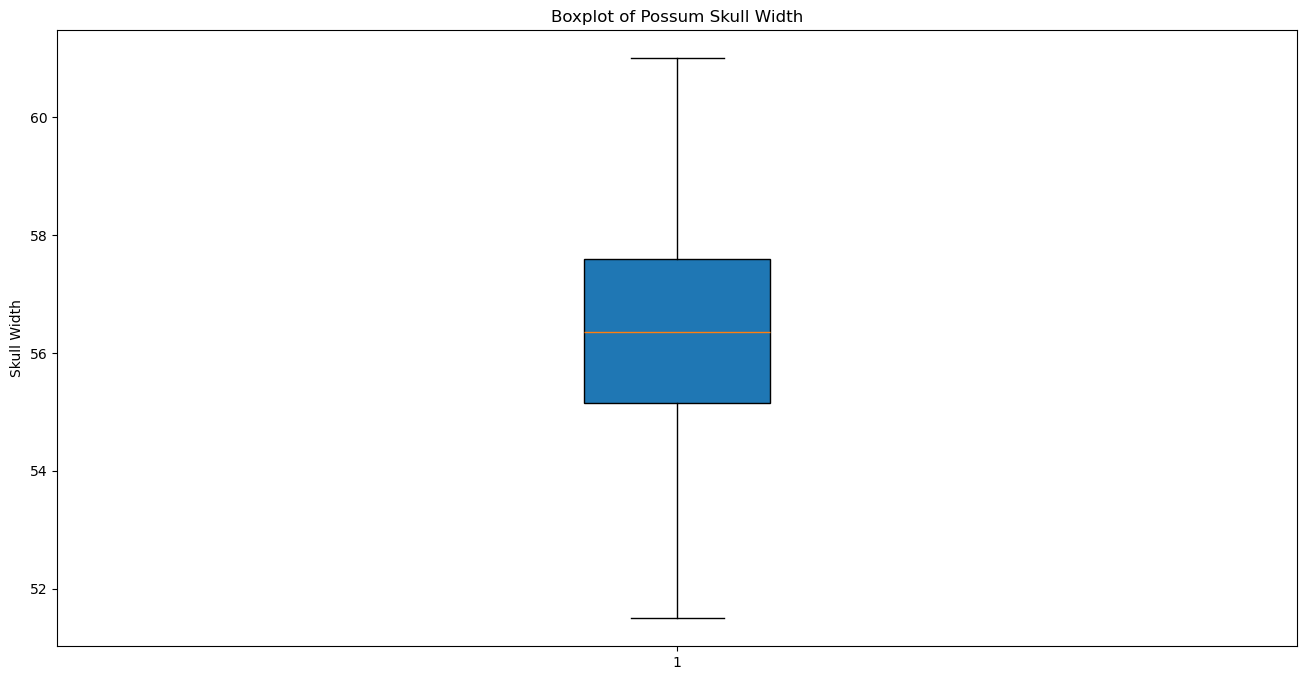

count    104.000000
mean      56.346154
std        1.954304
min       51.500000
25%       55.150000
50%       56.350000
75%       57.600000
max       61.000000
Name: skullw, dtype: float64

In [152]:
# Create boxplots of skull width column to further identify outliers
plt.figure(figsize=(16, 8))
plt.boxplot(possum['skullw'], patch_artist=True)
plt.title('Boxplot of Possum Skull Width')
plt.ylabel('Skull Width')
plt.show()

#Show the descriptive statistics of the skull width
possum['skullw'].describe()

### Outliers- totlngth Column

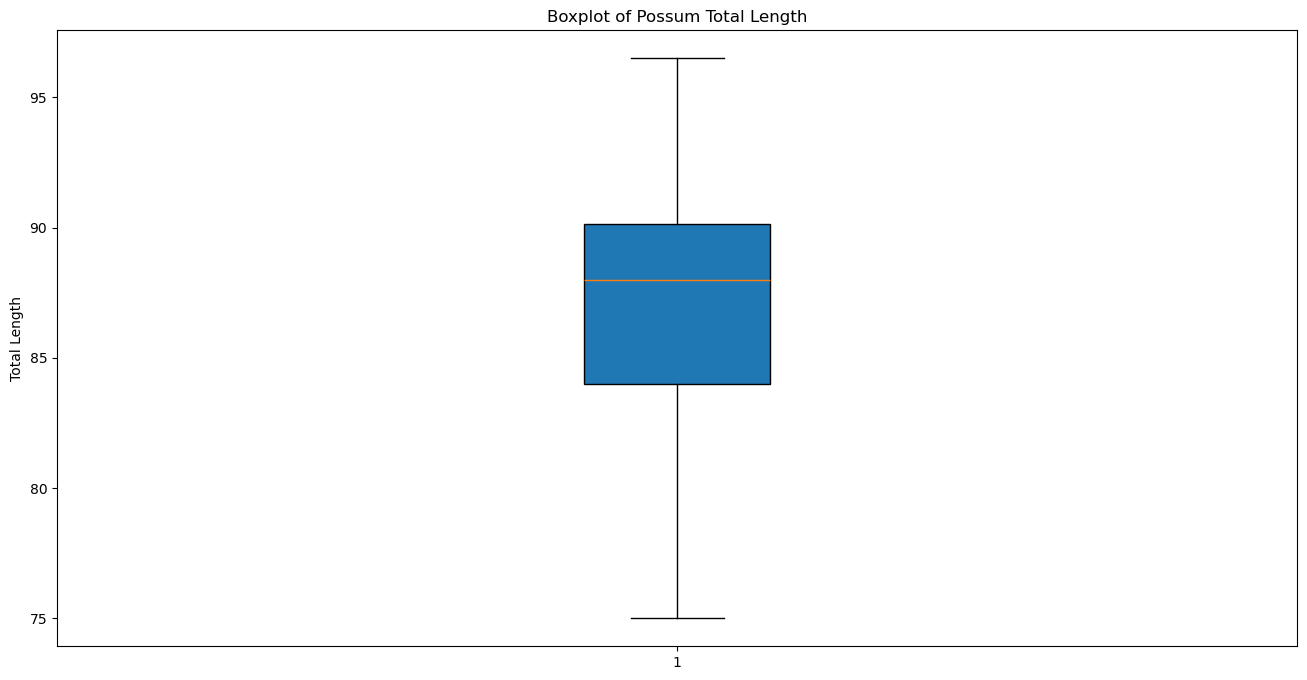

count    104.000000
mean      87.098077
std        4.317091
min       75.000000
25%       84.000000
50%       88.000000
75%       90.125000
max       96.500000
Name: totlngth, dtype: float64

In [153]:
# Create boxplots of Total Length column to identify outliers
plt.figure(figsize=(16, 8))
plt.boxplot(possum['totlngth'], patch_artist=True)
plt.title('Boxplot of Possum Total Length')
plt.ylabel('Total Length')
plt.show()

#Show the descriptive statistics of the total length
possum['totlngth'].describe()

### Outliers- Tail Column

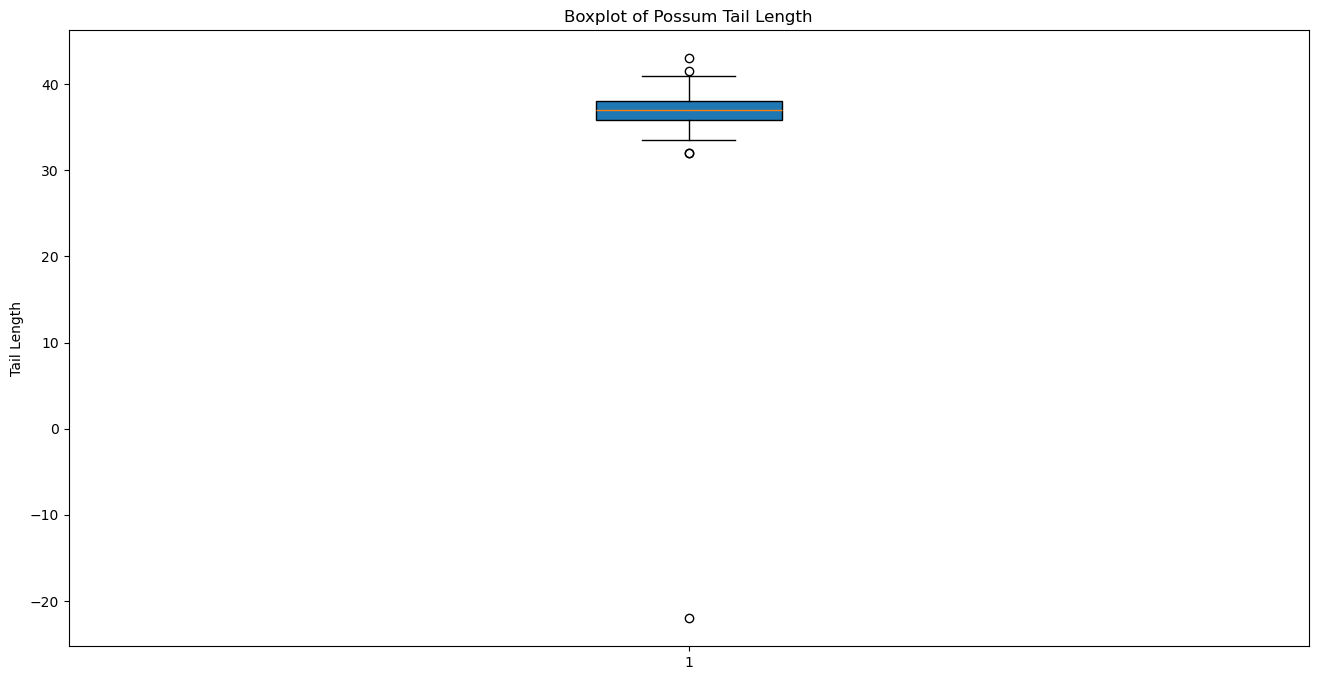

count    104.000000
mean      36.471154
std        6.104601
min      -22.000000
25%       35.875000
50%       37.000000
75%       38.000000
max       43.000000
Name: taill, dtype: float64

In [154]:
# Create boxplots of Tail Length column to identify outliers
plt.figure(figsize=(16, 8))
plt.boxplot(possum['taill'], patch_artist=True)
plt.title('Boxplot of Possum Tail Length')
plt.ylabel('Tail Length')
plt.show()

#Show the descriptive statistics of the tail length
possum['taill'].describe()

In [155]:
#Calculate the median the tail length column
median_tail = possum['taill'].median()
median_tail

37.0

In [156]:
# calculate 25th percentile of tail length column
percentile25_taill = possum['taill'].quantile(0.25)
print('percentile25_taill', percentile25_taill)

# calculate 75th percentile of tail length column
percentile75_taill = possum['taill'].quantile(0.75)
print('percentile75_taill', percentile75_taill)

percentile25_taill 35.875
percentile75_taill 38.0


In [157]:
#Calculate interquartile range of tail length column
iqr_taill = percentile75_taill - percentile25_taill
print(iqr_taill)

#Calculate upper and lower thresholds for outliers of tail length column
upper_limit_tail = percentile75_taill + 1.5 *iqr_taill
lower_limit_tail = percentile25_taill - 1.5 *iqr_taill

#Show upper and lower limit:
print ('Upper limit of tail length is: ' + str(upper_limit_tail))
print ('Lower limit of tail length is: ' + str(lower_limit_tail))

2.125
Upper limit of tail length is: 41.1875
Lower limit of tail length is: 32.6875


In [158]:
#isolate the outliers lower than the lower limit
lower_tail = possum[possum['taill'] < lower_limit_tail]
lower_tail

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
14,15.0,1.0,Vic,m,3.35,92.9,57.6,85.5,-22.0,69.7,51.8,15.7,28.0,35.0
41,42.0,2.0,Vic,m,3.95,92.8,54.1,77.0,32.0,62.7,51.2,13.8,25.5,33.0
42,43.0,2.0,Vic,f,2.50,90.0,55.5,81.0,32.0,72.0,49.4,13.4,29.0,31.0


In [159]:
#group the lower outliers of tail length to list
outliers_tail_lower = lower_tail['taill'].tolist()
outliers_tail_lower

#fixing the outliers by replacing with median of tail length
possum['taill'].replace(outliers_tail_lower, median_tail, inplace=True)

/var/folders/b1/2lz6ssmx4n52cww0tsc3hhg80000gn/T/ipykernel_72559/3632753830.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  possum['taill'].replace(outliers_tail_lower, median_tail, inplace=True)


In [160]:
#Check the lower outliers to confirm the replace
lower_tail = possum[possum['taill'] < lower_limit_tail]
lower_tail

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly


In [161]:
#isolate the outliers higher than the upper limit
upper_tail = possum[possum['taill'] > upper_limit_tail]
upper_tail

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
53,54.0,4.0,other,m,7.8,96.9,56.35,91.5,43.0,71.3,46.0,17.5,30.0,36.5
86,87.0,7.0,other,m,2.3,98.5,56.15,93.0,41.5,71.7,46.8,15.0,26.0,36.0


In [162]:
#group the upper outliers of tail length to list
outliers_tail_upper = upper_tail['taill'].tolist()
outliers_tail_upper

#fixing the outliers by replacing with median of tail length
possum['taill'].replace(outliers_tail_upper, median_tail, inplace=True)

/var/folders/b1/2lz6ssmx4n52cww0tsc3hhg80000gn/T/ipykernel_72559/2232943736.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  possum['taill'].replace(outliers_tail_upper, median_tail, inplace=True)


In [163]:
#Check the upper outliers to confirm the replace
upper_tail = possum[possum['taill'] > upper_limit_tail]
upper_tail

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly


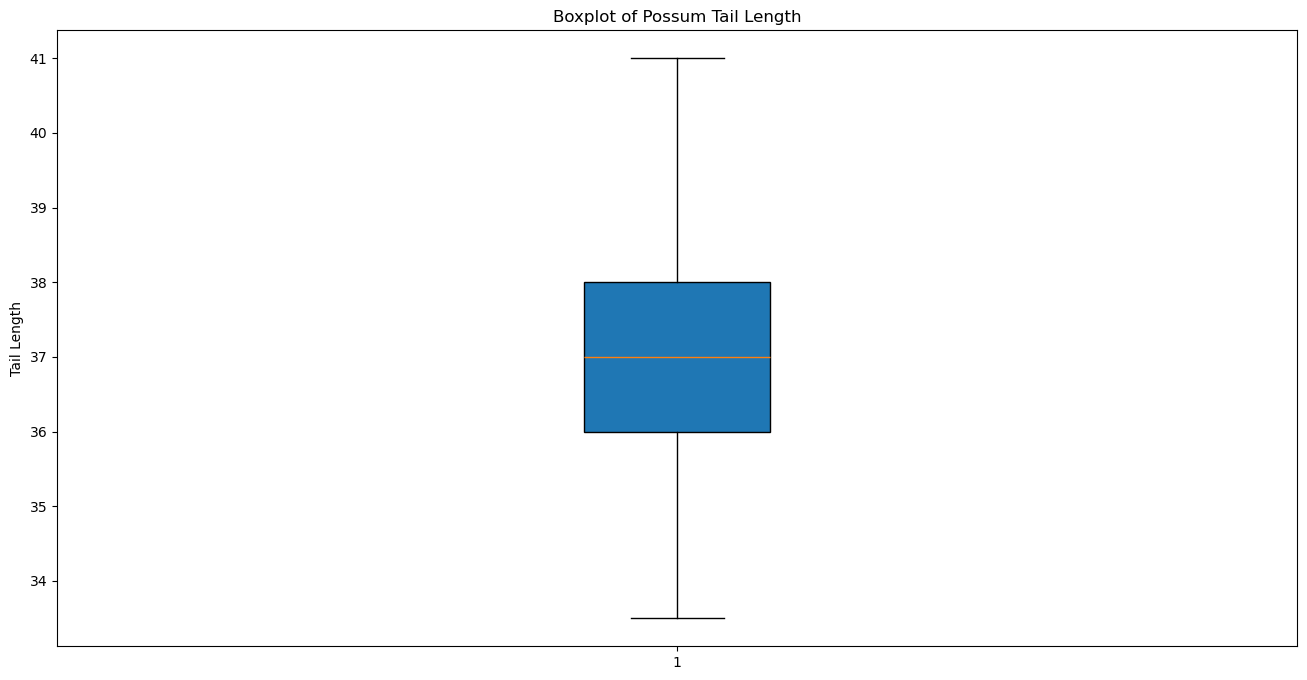

count    104.000000
mean      37.033654
std        1.649160
min       33.500000
25%       36.000000
50%       37.000000
75%       38.000000
max       41.000000
Name: taill, dtype: float64

In [164]:
# Create boxplots of Tail Length column to futher identify outliers
plt.figure(figsize=(16, 8))
plt.boxplot(possum['taill'], patch_artist=True)
plt.title('Boxplot of Possum Tail Length')
plt.ylabel('Tail Length')
plt.show()

#Show the descriptive statistics of the tail length
possum['taill'].describe()

### Outliers- Foot Length Column

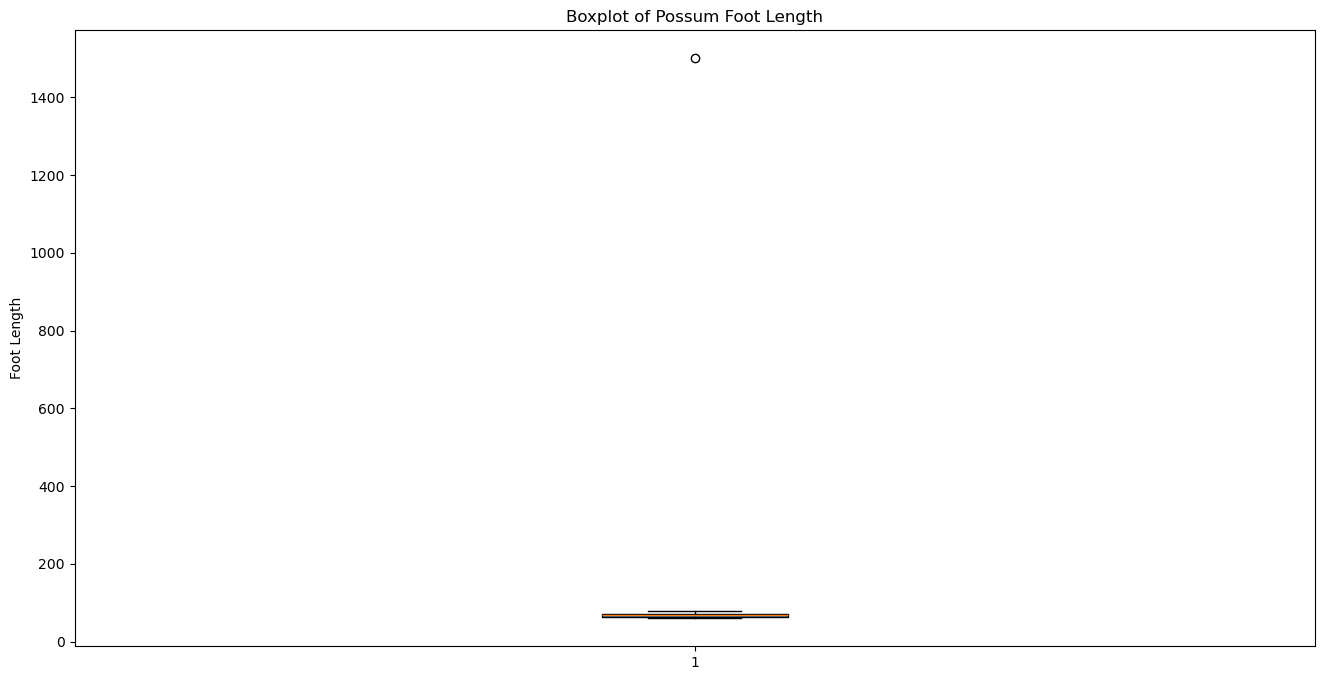

count     104.000000
mean       82.251442
std       140.439564
min        60.300000
25%        64.775000
50%        68.100000
75%        72.550000
max      1500.000000
Name: footlgth, dtype: float64

In [165]:
# Create boxplots of Foot Length column to identify outliers
plt.figure(figsize=(16, 8))
plt.boxplot(possum['footlgth'], patch_artist=True)
plt.title('Boxplot of Possum Foot Length')
plt.ylabel('Foot Length')
plt.show()

#Show the descriptive statistics of the foot length
possum['footlgth'].describe()

In [166]:
#Calculate the median of foot length column
median_footlgth = possum['footlgth'].median()
median_footlgth

68.1

In [167]:
# calculate 25th percentile of foot length column
percentile25_footlgth = possum['footlgth'].quantile(0.25)
print('percentile25_footlgth', percentile25_footlgth)

# calculate 75th percentile of foot length column
percentile75_footlgth = possum['footlgth'].quantile(0.75)
print('percentile75_footlgth', percentile75_footlgth)

percentile25_footlgth 64.775
percentile75_footlgth 72.55


In [168]:
#Calculate interquartile range of foot length column
iqr_footlgth = percentile75_footlgth - percentile25_footlgth
print(iqr_footlgth)

#Calculate upper and lower thresholds for outliers of foot length column
upper_limit_footlgth = percentile75_footlgth + 1.5 *iqr_footlgth
lower_limit_footlgth = percentile25_footlgth - 1.5 *iqr_footlgth

#Show upper and lower limit:
print ('Upper limit of foot length is: ' + str(upper_limit_footlgth))
print ('Lower limit of foot length is: ' + str(lower_limit_footlgth))

7.7749999999999915
Upper limit of foot length is: 84.21249999999998
Lower limit of foot length is: 53.11250000000002


In [169]:
#isolate the outliers higher than the upper limit
upper_footlgth = possum[possum['footlgth'] > upper_limit_footlgth]
upper_footlgth

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
89,90.0,7.0,other,m,3.5,92.6,54.6,85.0,38.5,1500.0,44.8,14.5,25.5,31.5


In [170]:
#group the upper outliers of foot length to list
outliers_footlgth_upper = upper_footlgth['footlgth'].tolist()
outliers_footlgth_upper

#fixing the outliers by replacing with the median of foot length 
possum['footlgth'].replace(outliers_footlgth_upper, median_footlgth, inplace=True)

/var/folders/b1/2lz6ssmx4n52cww0tsc3hhg80000gn/T/ipykernel_72559/1617099059.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  possum['footlgth'].replace(outliers_footlgth_upper, median_footlgth, inplace=True)


In [171]:
#Check the upper outliers to confirm the replace
upper_footlgth = possum[possum['footlgth'] > upper_limit_footlgth]
upper_footlgth

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly


In [172]:
#isolate the outliers lower than the lower limit
lower_footlgth = possum[possum['footlgth'] < lower_limit_footlgth]
lower_footlgth

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly


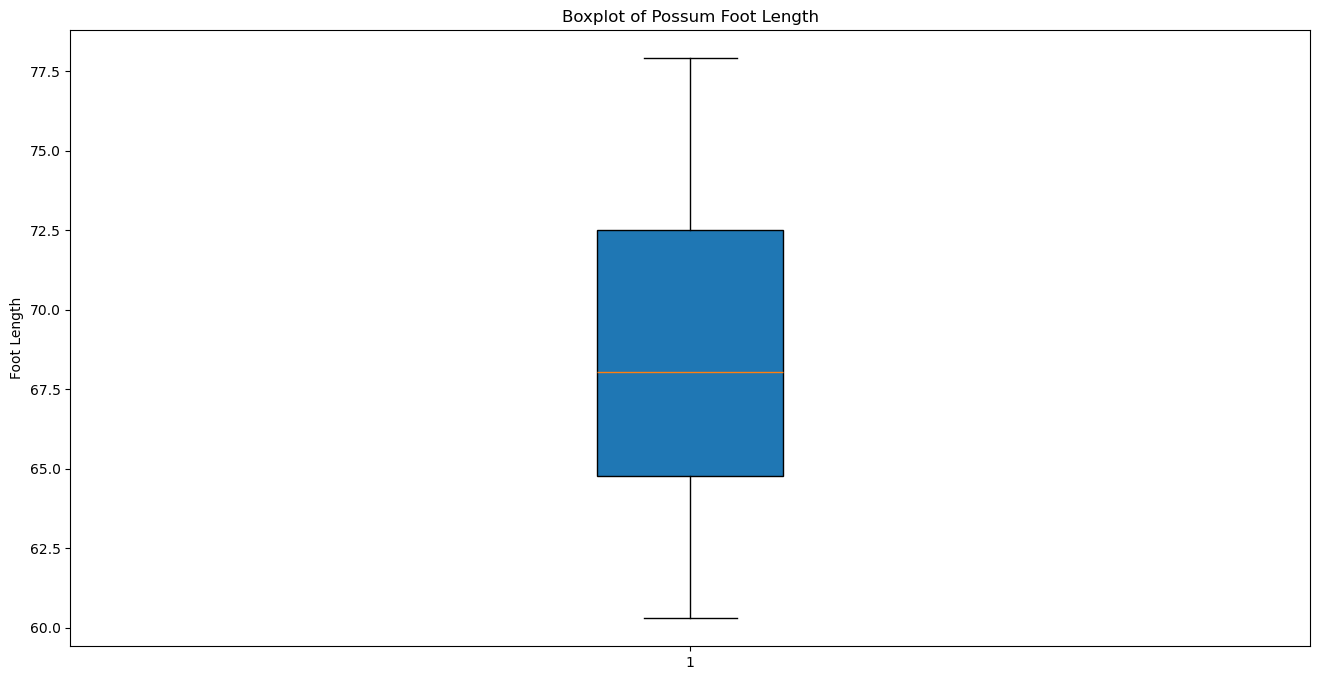

count    104.000000
mean      68.483173
std        4.374943
min       60.300000
25%       64.775000
50%       68.050000
75%       72.500000
max       77.900000
Name: footlgth, dtype: float64

In [173]:
# Create boxplots of Foot Length column to further identify outliers
plt.figure(figsize=(16, 8))
plt.boxplot(possum['footlgth'], patch_artist=True)
plt.title('Boxplot of Possum Foot Length')
plt.ylabel('Foot Length')
plt.show()

#Show the descriptive statistics of the foot length
possum['footlgth'].describe()

### Outliers- Ear Conch Length Column

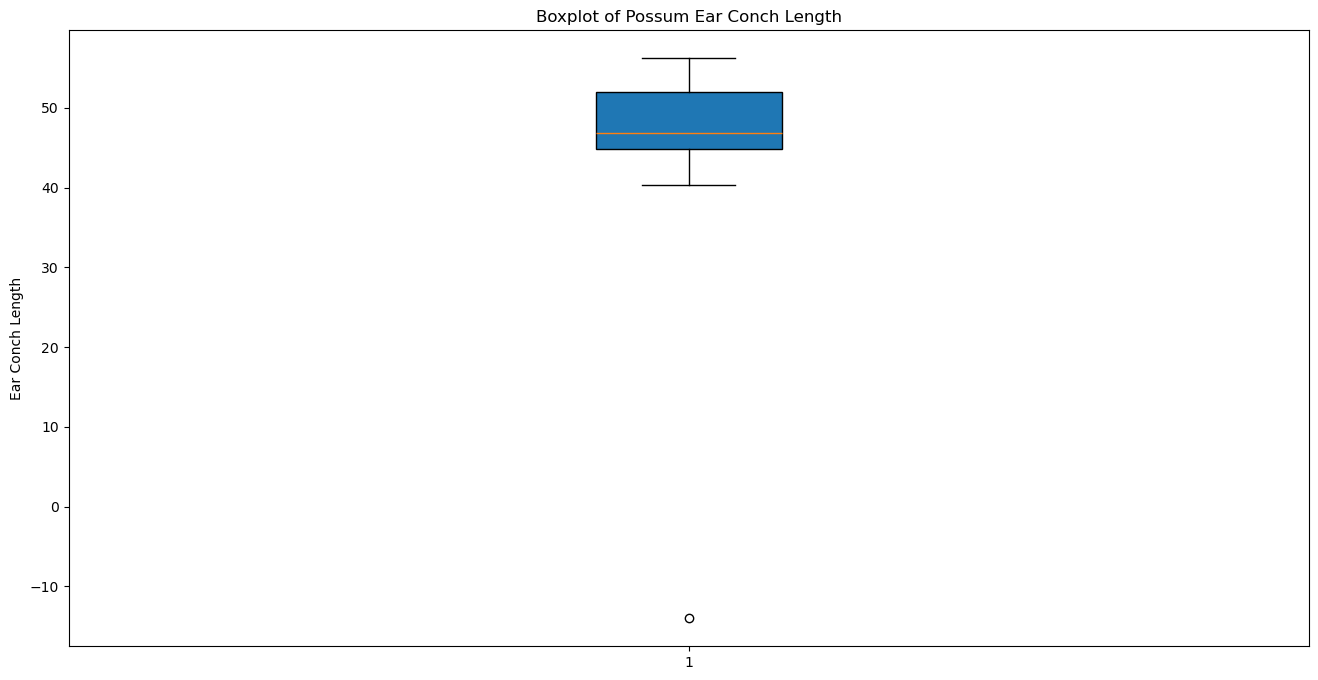

count    104.000000
mean      47.550000
std        7.348152
min      -14.000000
25%       44.775000
50%       46.800000
75%       52.000000
max       56.200000
Name: earconch, dtype: float64

In [174]:
# Create boxplots of ear conch column to identify outliers
plt.figure(figsize=(16, 8))
plt.boxplot(possum['earconch'], patch_artist=True)
plt.title('Boxplot of Possum Ear Conch Length')
plt.ylabel('Ear Conch Length')
plt.show()

#Show the descriptive statistics of the ear conch
possum['earconch'].describe()

In [175]:
#Calculate the median of ear conch column
median_earconch = possum['earconch'].median()
median_earconch

46.8

In [176]:
# calculate 25th percentile of ear conch length column
percentile25_earconch = possum['earconch'].quantile(0.25)
print('percentile25_earconch', percentile25_earconch)

# calculate 75th percentile of ear conch length column
percentile75_earconch = possum['earconch'].quantile(0.75)
print('percentile75_earconch', percentile75_earconch)

percentile25_earconch 44.775
percentile75_earconch 52.0


In [177]:
#Calculate interquartile range of ear conch length column
iqr_earconch = percentile75_earconch - percentile25_earconch
print(iqr_earconch)

#Calculate upper and lower thresholds for outliers of ear conch length column
upper_limit_earconch = percentile75_earconch + 1.5 *iqr_earconch
lower_limit_earconch = percentile25_earconch - 1.5 *iqr_earconch

#Show upper and lower limit:
print ('Upper limit of ear conch length is: ' + str(upper_limit_earconch))
print ('Lower limit of ear conch length is: ' + str(lower_limit_earconch))

7.225000000000001
Upper limit of ear conch length is: 62.837500000000006
Lower limit of ear conch length is: 33.9375


In [178]:
#isolate the outliers lower than the lower limit
lower_earconch = possum[possum['earconch'] < lower_limit_earconch]
lower_earconch

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
57,58.0,4.0,other,m,3.7,94.5,56.35,91.0,39.0,66.5,-14.0,14.4,30.5,33.0


In [179]:
#group the lower outliers of ear conch to list
outliers_earconch_lower = lower_earconch['earconch'].tolist()
outliers_earconch_lower

#fixing the outliers by replacing with the median of ear conch
possum['earconch'].replace(outliers_earconch_lower, median_earconch, inplace=True)

/var/folders/b1/2lz6ssmx4n52cww0tsc3hhg80000gn/T/ipykernel_72559/554820896.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  possum['earconch'].replace(outliers_earconch_lower, median_earconch, inplace=True)


In [180]:
#Check the lower outliers to confirm the replace
lower_earconch = possum[possum['earconch'] < lower_limit_earconch]
lower_earconch

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly


In [181]:
#isolate the outliers higher than the upper limit
upper_earconch = possum[possum['earconch'] > upper_limit_earconch]
upper_earconch

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly


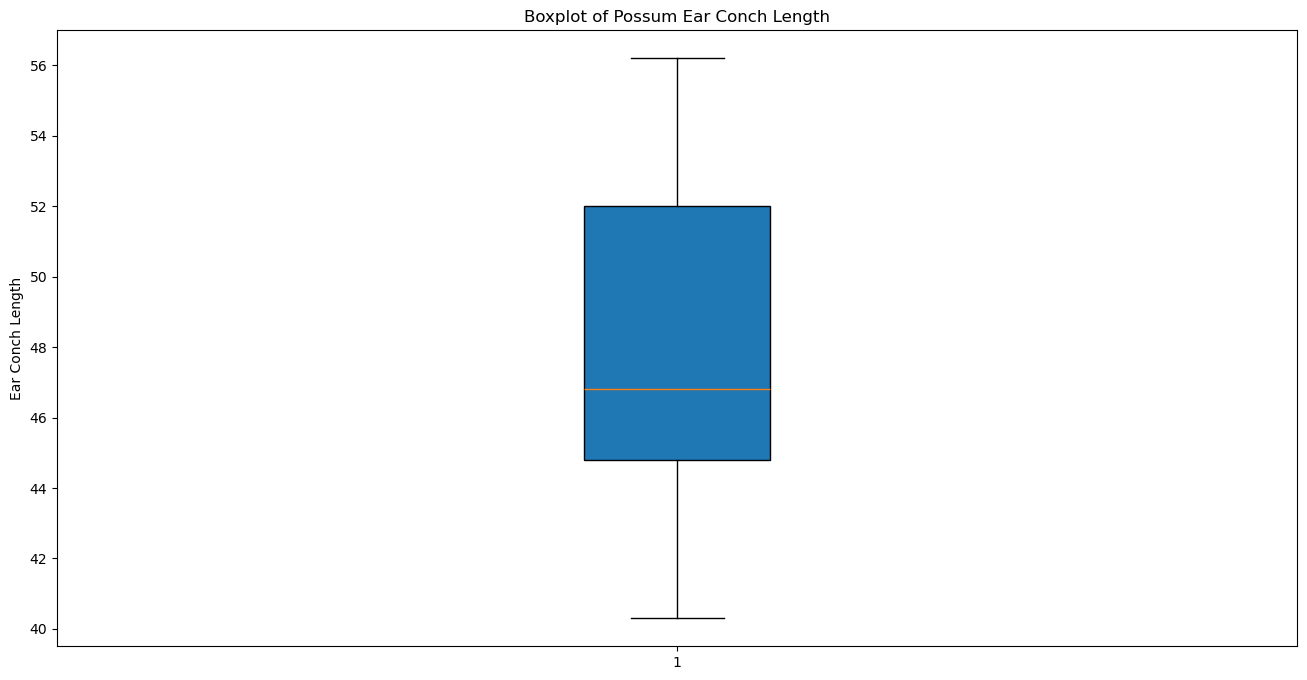

count    104.000000
mean      48.134615
std        4.107931
min       40.300000
25%       44.800000
50%       46.800000
75%       52.000000
max       56.200000
Name: earconch, dtype: float64

In [182]:
# Create boxplots of ear conch length column to further identify outliers
plt.figure(figsize=(16, 8))
plt.boxplot(possum['earconch'], patch_artist=True)
plt.title('Boxplot of Possum Ear Conch Length')
plt.ylabel('Ear Conch Length')
plt.show()

#Show the descriptive statistics of the ear conch
possum['earconch'].describe()

### Outliers- Eye Distance Column

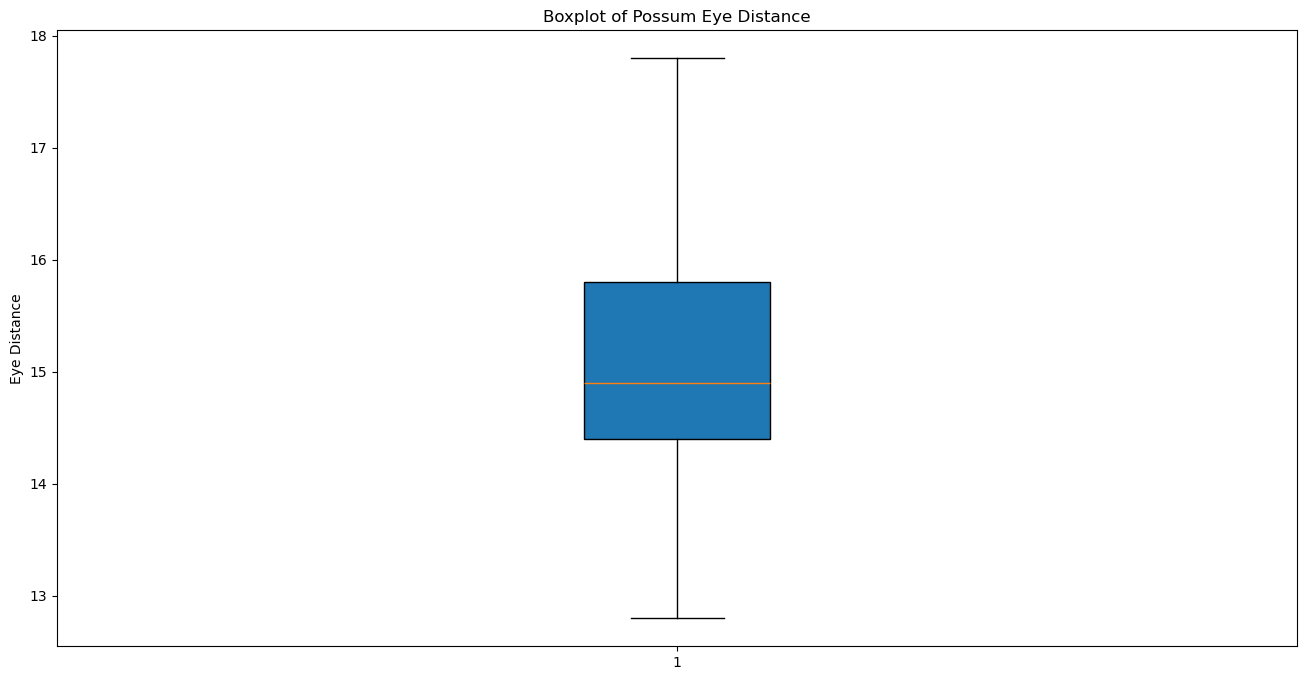

count    104.000000
mean      15.058173
std        1.056972
min       12.800000
25%       14.400000
50%       14.900000
75%       15.800000
max       17.800000
Name: eye, dtype: float64

In [183]:
# Create boxplots of Eye column to identify outliers
plt.figure(figsize=(16, 8))
plt.boxplot(possum['eye'], patch_artist=True)
plt.title('Boxplot of Possum Eye Distance')
plt.ylabel('Eye Distance')
plt.show()

#Show the descriptive statistics of the eye column
possum['eye'].describe()

### Outliers- Chest Girth Column

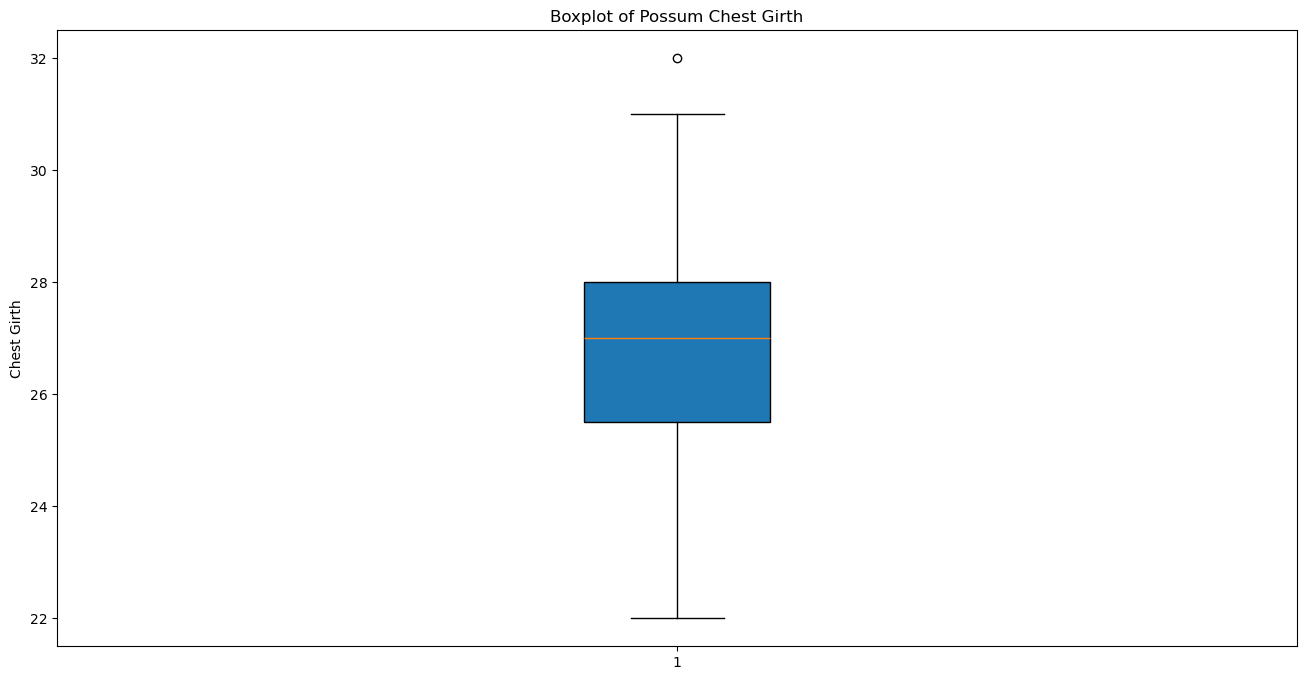

count    104.000000
mean      27.000000
std        2.045597
min       22.000000
25%       25.500000
50%       27.000000
75%       28.000000
max       32.000000
Name: chest, dtype: float64

In [184]:
# Create boxplots of Chest column to identify outliers
plt.figure(figsize=(16, 8))
plt.boxplot(possum['chest'], patch_artist=True)
plt.title('Boxplot of Possum Chest Girth')
plt.ylabel('Chest Girth')
plt.show()

#Show the descriptive statistics of the chest column
possum['chest'].describe()

In [185]:
#Calculate the median of chest column
median_chest = possum['chest'].median()
median_chest

27.0

In [186]:
# calculate 25th percentile of chest girth column
percentile25_chest = possum['chest'].quantile(0.25)
print('percentile25_chest', percentile25_chest)

# calculate 75th percentile of chest girth column
percentile75_chest = possum['chest'].quantile(0.75)
print('percentile75_chest', percentile75_chest)

percentile25_chest 25.5
percentile75_chest 28.0


In [187]:
#Calculate interquartile range of chest girth column
iqr_chest = percentile75_chest - percentile25_chest
print(iqr_chest)

#Calculate upper and lower thresholds for outliers of chest girth column
upper_limit_chest = percentile75_chest + 1.5 *iqr_chest
lower_limit_chest = percentile25_chest - 1.5 *iqr_chest

#Show upper and lower limit:
print ('Upper limit of chest girth is: ' + str(upper_limit_chest))
print ('Lower limit of chest girth is: ' + str(lower_limit_chest))

2.5
Upper limit of chest girth is: 31.75
Lower limit of chest girth is: 21.75


In [188]:
#isolate the outliers lower than the lower limit
lower_chest = possum[possum['chest'] < lower_limit_chest]
lower_chest

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly


In [189]:
#isolate the outliers higher than the upper limit
upper_chest = possum[possum['chest'] > upper_limit_chest]
upper_chest

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
58,59.0,4.0,other,m,2.3,92.8,56.35,96.0,40.0,73.2,44.5,14.7,32.0,36.0


In [190]:
#group the upper outliers of chest girth to list
outliers_chest_upper = upper_chest['chest'].tolist()
outliers_chest_upper

#fixing the outliers by replacing with the median of chest girth
possum['chest'].replace(outliers_chest_upper, median_chest, inplace=True)

/var/folders/b1/2lz6ssmx4n52cww0tsc3hhg80000gn/T/ipykernel_72559/4187729410.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  possum['chest'].replace(outliers_chest_upper, median_chest, inplace=True)


In [191]:
#Check the upper outliers to confirm the replace
upper_chest = possum[possum['chest'] > upper_limit_chest]
upper_chest

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly


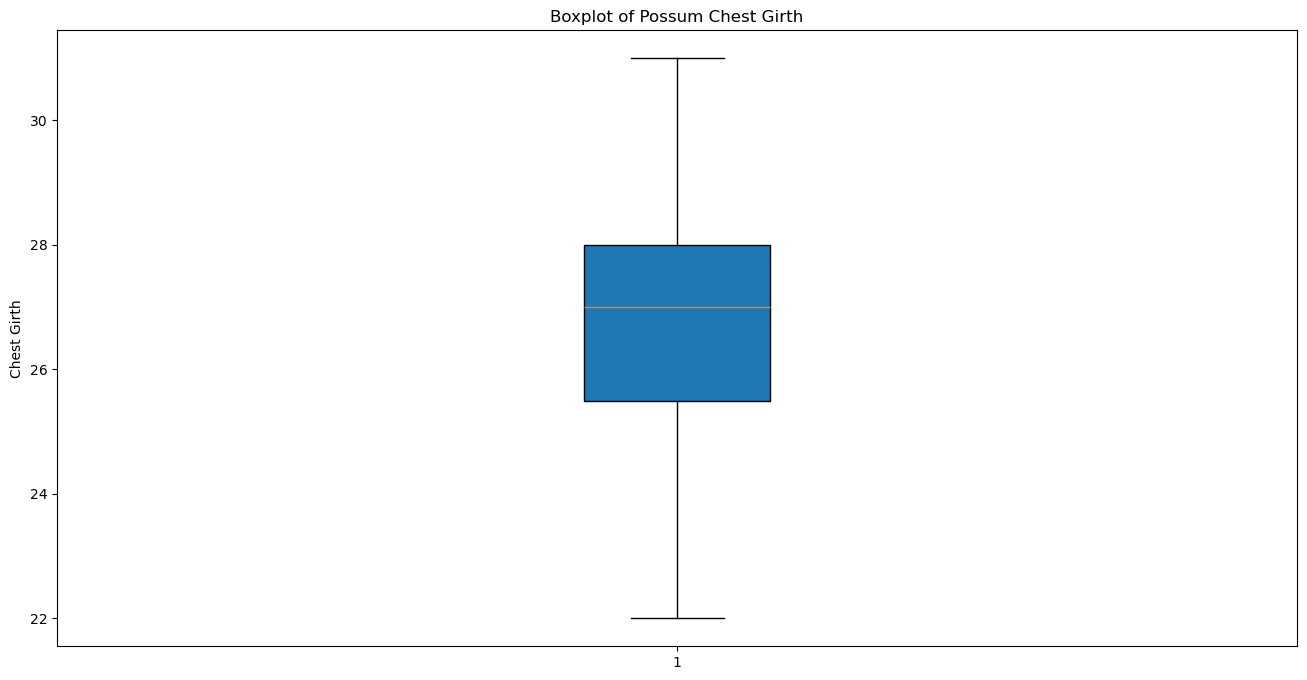

count    104.000000
mean      26.951923
std        1.984796
min       22.000000
25%       25.500000
50%       27.000000
75%       28.000000
max       31.000000
Name: chest, dtype: float64

In [192]:
# Create boxplots of Chest column to further identify outliers
plt.figure(figsize=(16, 8))
plt.boxplot(possum['chest'], patch_artist=True)
plt.title('Boxplot of Possum Chest Girth')
plt.ylabel('Chest Girth')
plt.show()

#Show the descriptive statistics of the chest column
possum['chest'].describe()

### Outliers- Belly Girth Column

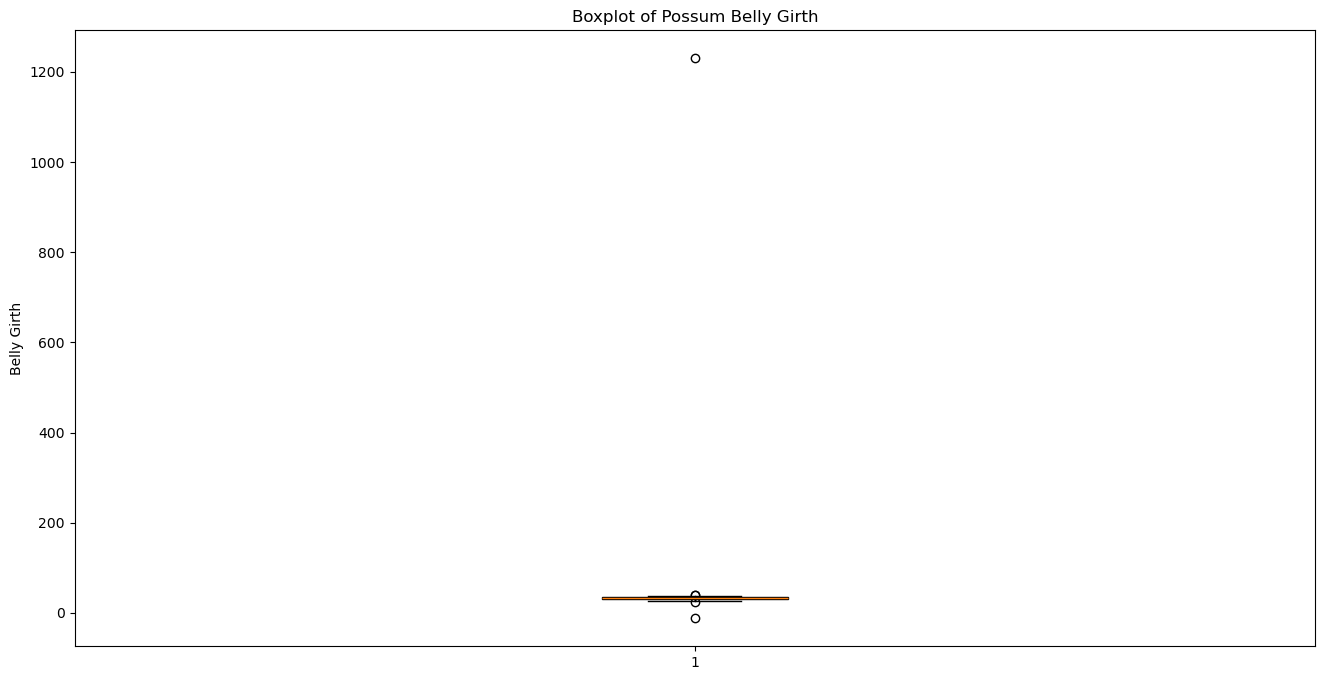

count     104.000000
mean       43.620192
std       117.576571
min       -12.000000
25%        31.000000
50%        32.000000
75%        34.125000
max      1230.000000
Name: belly, dtype: float64

In [193]:
# Create boxplots of Belly column to identify outliers
plt.figure(figsize=(16, 8))
plt.boxplot(possum['belly'], patch_artist=True)
plt.title('Boxplot of Possum Belly Girth')
plt.ylabel('Belly Girth')
plt.show()

#Show the descriptive statistics of the belly column
possum['belly'].describe()

In [194]:
#Calculate the median of belly girth
median_belly = possum['belly'].median()
median_belly

32.0

In [195]:
# calculate 25th percentile of belly girth column
percentile25_belly = possum['belly'].quantile(0.25)
print('percentile25_belly', percentile25_belly)

# calculate 75th percentile of belly girth column
percentile75_belly = possum['belly'].quantile(0.75)
print('percentile75_belly', percentile75_belly)

percentile25_belly 31.0
percentile75_belly 34.125


In [196]:
#Calculate interquartile range of belly girth column
iqr_belly = percentile75_belly - percentile25_belly
print(iqr_belly)

#Calculate upper and lower thresholds for outliers of belly girth column
upper_limit_belly = percentile75_belly + 1.5 *iqr_belly
lower_limit_belly = percentile25_belly - 1.5 *iqr_belly

#Show upper and lower limit:
print ('Upper limit of belly girth is: ' + str(upper_limit_belly))
print ('Lower limit of belly girth is: ' + str(lower_limit_belly))

3.125
Upper limit of belly girth is: 38.8125
Lower limit of belly girth is: 26.3125


In [197]:
#isolate the outliers lower than the lower limit
lower_belly = possum[possum['belly'] < lower_limit_belly]
lower_belly

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
7,8.0,1.0,Vic,f,6.3,94.8,57.6,91.0,37.0,72.7,53.9,14.5,29.0,-12.0
38,39.0,2.0,Vic,f,1.3,92.8,51.5,75.0,34.0,68.7,53.4,13.0,25.0,25.0


In [198]:
#group the lower outliers of belly girth to list
outliers_belly_lower = lower_belly['belly'].tolist()
outliers_belly_lower

#fixing the outliers by replacing with the median of belly girth
possum['belly'].replace(outliers_belly_lower, median_belly, inplace=True)

/var/folders/b1/2lz6ssmx4n52cww0tsc3hhg80000gn/T/ipykernel_72559/785037879.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  possum['belly'].replace(outliers_belly_lower, median_belly, inplace=True)


In [199]:
#Check the lower outliers to confirm the replace
lower_belly = possum[possum['belly'] < lower_limit_belly]
lower_belly

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly


In [200]:
#isolate the outliers higher than the upper limit
upper_belly = possum[possum['belly'] > upper_limit_belly]
upper_belly

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
20,21.0,1.0,Vic,f,3.6,95.9,58.1,96.5,39.5,77.9,52.9,14.2,30.0,40.0
49,50.0,3.0,other,f,5.4,91.6,56.4,88.0,38.0,65.0,47.2,14.9,28.0,1230.0
56,57.0,4.0,other,f,4.1,95.1,59.4,93.0,41.0,67.2,45.3,14.5,31.0,39.0


In [201]:
#group the upper outliers of belly girth to list
outliers_belly_upper = upper_belly['belly'].tolist()
outliers_belly_upper

#fixing the outliers by replacing with the median of belly girth
possum['belly'].replace(outliers_belly_upper, median_belly, inplace=True)

/var/folders/b1/2lz6ssmx4n52cww0tsc3hhg80000gn/T/ipykernel_72559/2110135650.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  possum['belly'].replace(outliers_belly_upper, median_belly, inplace=True)


In [202]:
#Check the upper outliers to confirm the replace
upper_belly = possum[possum['belly'] > upper_limit_belly]
upper_belly

,case,site,Pop,gender,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly


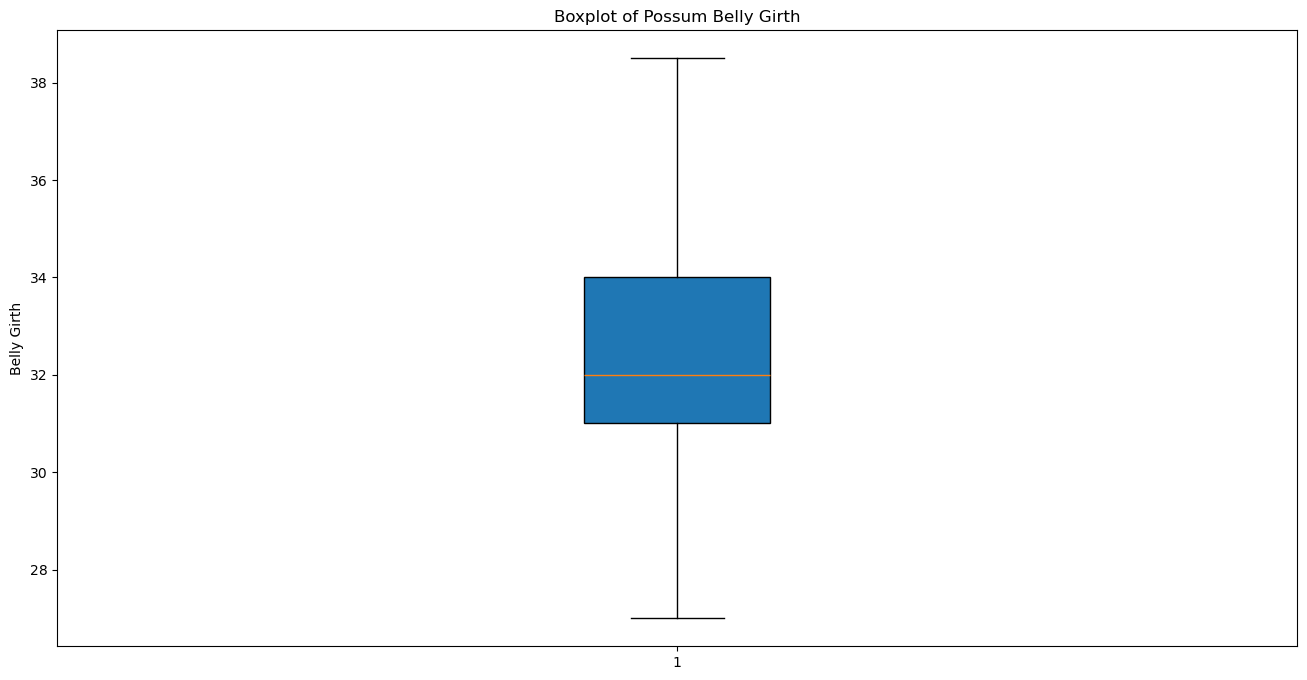

count    104.000000
mean      32.447115
std        2.449409
min       27.000000
25%       31.000000
50%       32.000000
75%       34.000000
max       38.500000
Name: belly, dtype: float64

In [203]:
# Create boxplots of belly column to further identify outliers
plt.figure(figsize=(16, 8))
plt.boxplot(possum['belly'], patch_artist=True)
plt.title('Boxplot of Possum Belly Girth')
plt.ylabel('Belly Girth')
plt.show()

#Show the descriptive statistics of the belly column
possum['belly'].describe()

## Skewness and Histogram

In [204]:
#Define all columns for skewness
skewness_all_columns = ['age', 'hdlngth', 'skullw', 'totlngth', 'taill', 'footlgth', 'earconch', 'eye', 'chest', 'belly']

#Check the skewness for all columns
possum[skewness_all_columns].skew()

age         0.440910
hdlngth     0.148292
skullw     -0.144004
totlngth   -0.287624
taill       0.177861
footlgth    0.083464
earconch    0.152512
eye         0.365274
chest      -0.144918
belly       0.093924
dtype: float64

After checking the skewness values for all the columns, all the values are between -0.5 and 0.5: This range is typically considered to indicate an approximately symmetrical distribution. Therefore, there is no need to perform data transformation techniques, such as logarithmic, square root, or Box-Cox transformations

To further understand how data is distributed across the dataframe, histogram needed to be plotted which also show the skewness and outliers. In this data set, histogram for age, head length, skull width, total length, tail length, foot length, ear conch, eye distance, chest girth and belly girth are plotted.

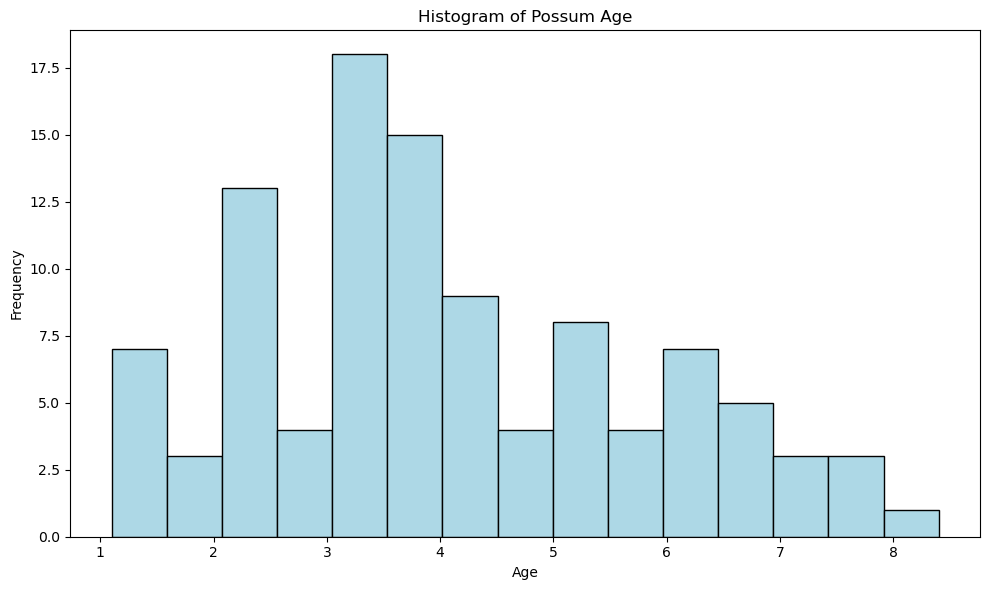

In [205]:
# Plotting Histogram to reveal how the data is distributed across the dataframe, showing skewness and outliers.
plt.figure(figsize=(10, 6))
plt.hist(possum['age'], bins=15, color='lightblue', edgecolor='black')
plt.title('Histogram of Possum Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

This histogram shows the distribution of the possum age. Age is spread between 1 and 8 years. Most possums age are between 2 and 4 years old, with peaks frequency at age 3 and 4. Youngs possums (1-2 years) and Older possums (7-8 years) are less common.

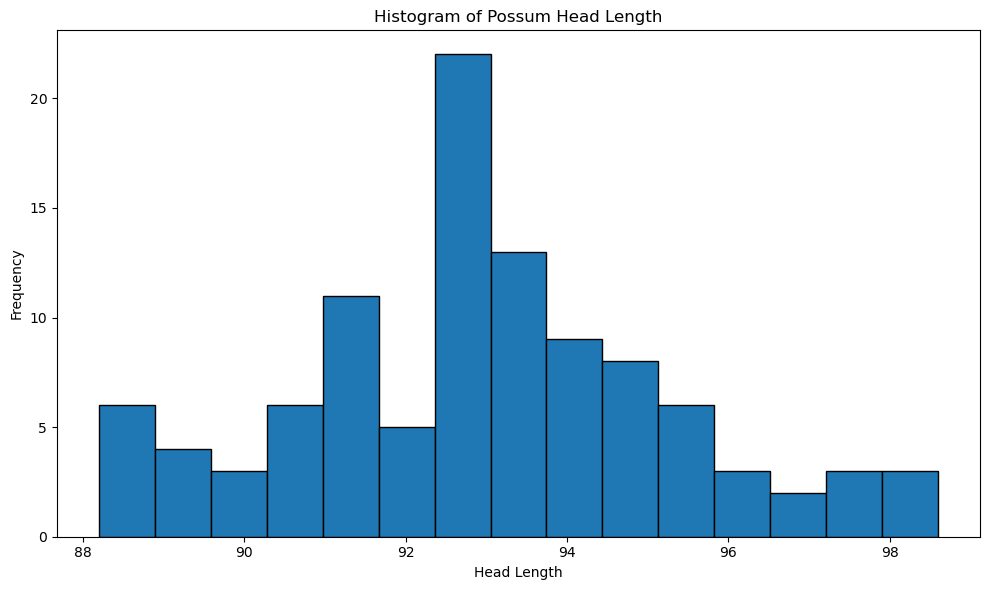

In [206]:
plt.figure(figsize=(10, 6))
plt.hist(possum['hdlngth'], bins=15, edgecolor='black')
plt.title('Histogram of Possum Head Length')
plt.xlabel('Head Length')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

This histogram shows the distribution of the possum head length which shows a central concentration. Possums' head length falls between 88mm and 99mm. The most frequnt range is around 92mm and 93mm, with fewer possums shorter head length or longer head length. 

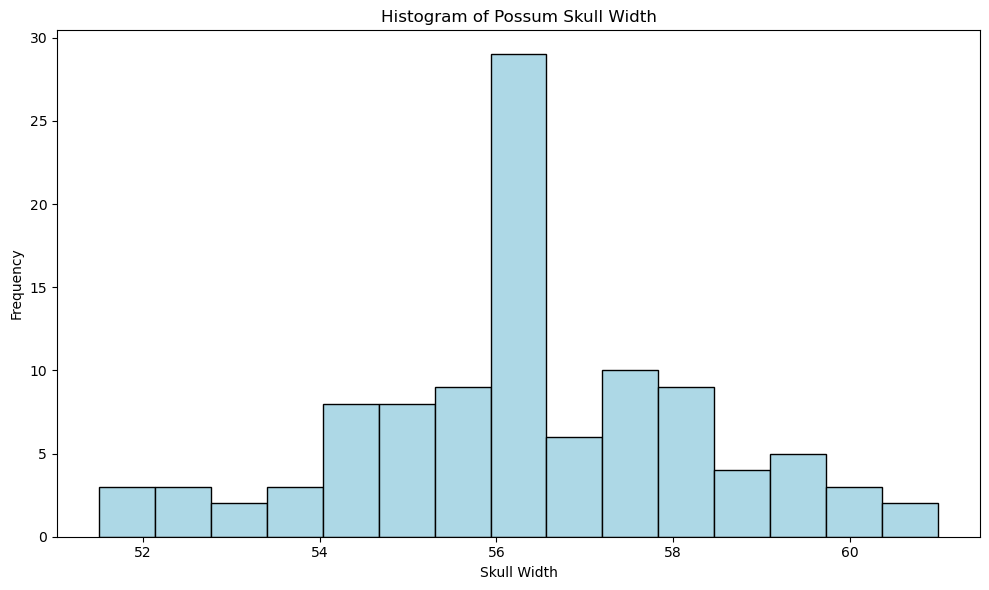

In [207]:
plt.figure(figsize=(10, 6))
plt.hist(possum['skullw'], bins=15, color='lightblue', edgecolor='black')
plt.title('Histogram of Possum Skull Width')
plt.xlabel('Skull Width')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

This histogram shows the distribution of the possum skull width. The skull width ranges from around 51mm to 61mm. A sharp peak of frequency is at around 56mm. Other measurements of skull width are less frequents.

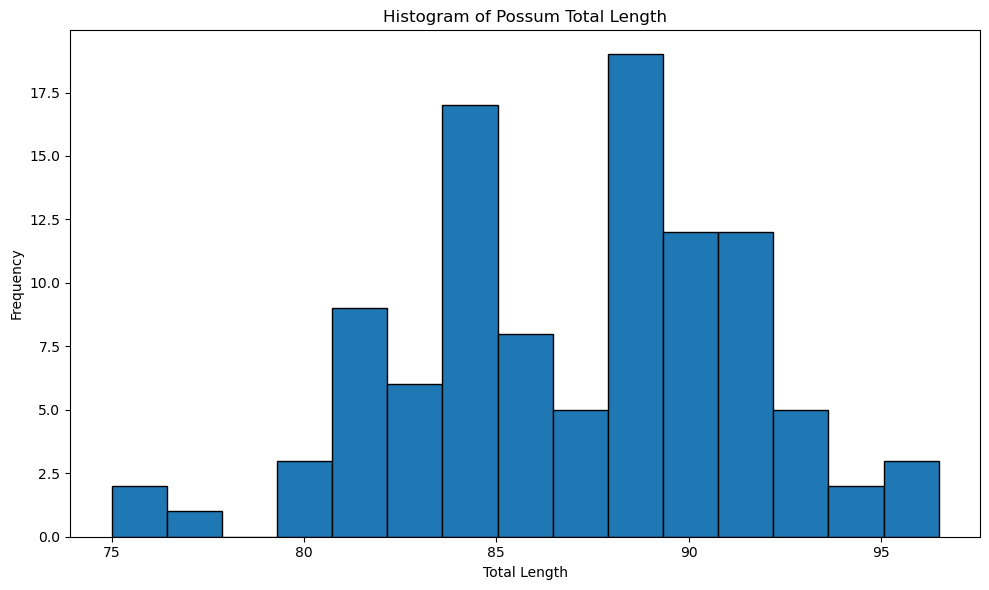

In [208]:
plt.figure(figsize=(10, 6))
plt.hist(possum['totlngth'], bins=15, edgecolor='black')
plt.title('Histogram of Possum Total Length')
plt.xlabel('Total Length')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

This histogram shows the distribution of the possum total length. The total lengths of possums is concentrated between 75cm and 96cm. The histograms shows clustering of frequency between 84cm to 90cm, where mosts possums have. However,

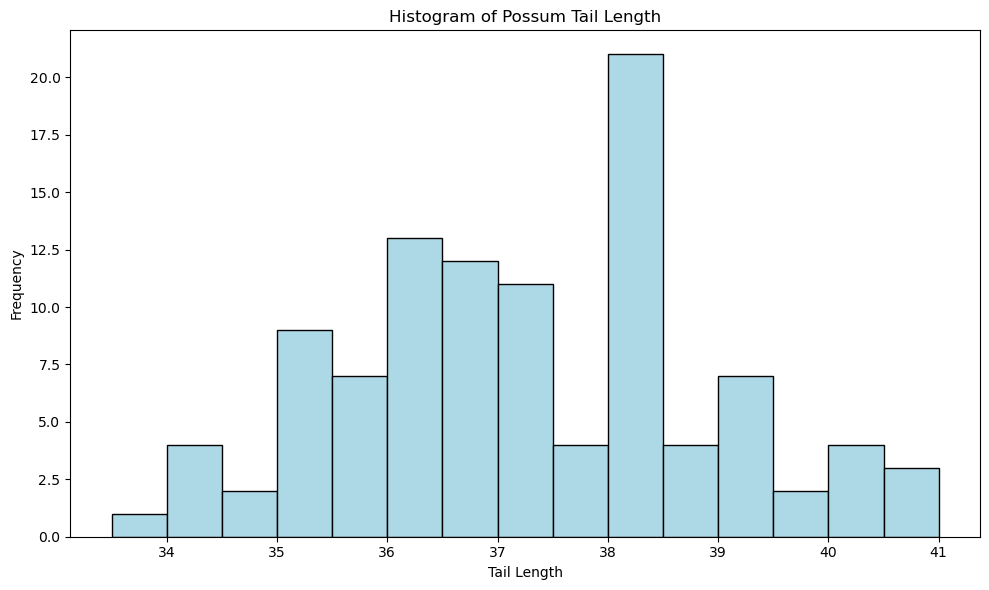

In [209]:
plt.figure(figsize=(10, 6))
plt.hist(possum['taill'], bins=15, color='lightblue', edgecolor='black')
plt.title('Histogram of Possum Tail Length')
plt.xlabel('Tail Length')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

This histogram shows the distribution of the possum tail length. The tail length distribution is spread between 34cm to 41cm. The highest frequency is around 38cm. The tail length that shorter than 38cm are more frequent than the tail length longer than 41cm.

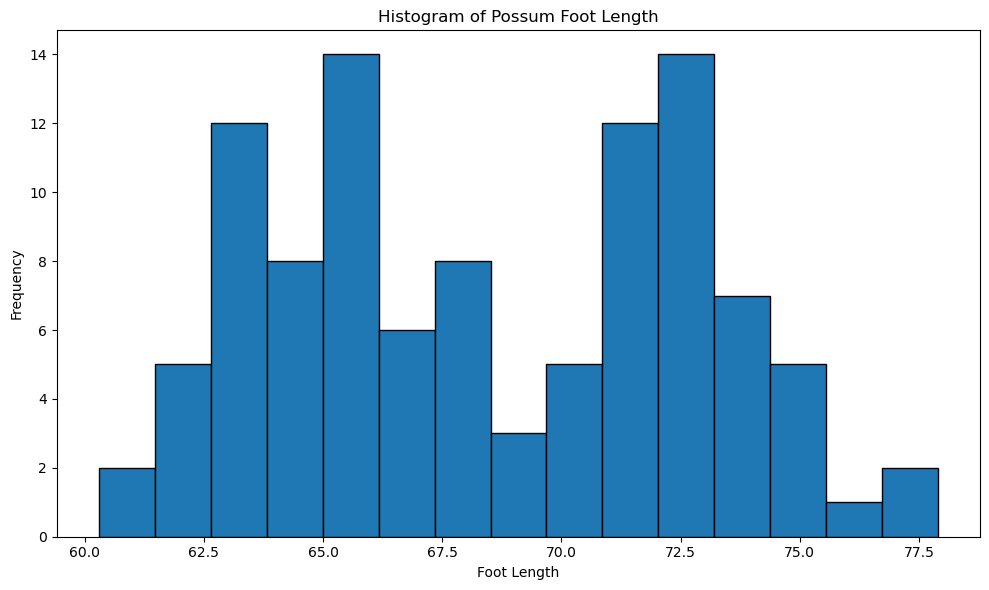

In [210]:
plt.figure(figsize=(10, 6))
plt.hist(possum['footlgth'], bins=15, edgecolor='black')
plt.title('Histogram of Possum Foot Length')
plt.xlabel('Foot Length')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

This histogram shows the distribution of the possum foot length of which is faily wide. The range of the distribution is between 60 to 78. There are two noticeable peaks at 65-66 and 72-73. This indicates that the possum foot length are clustered. 

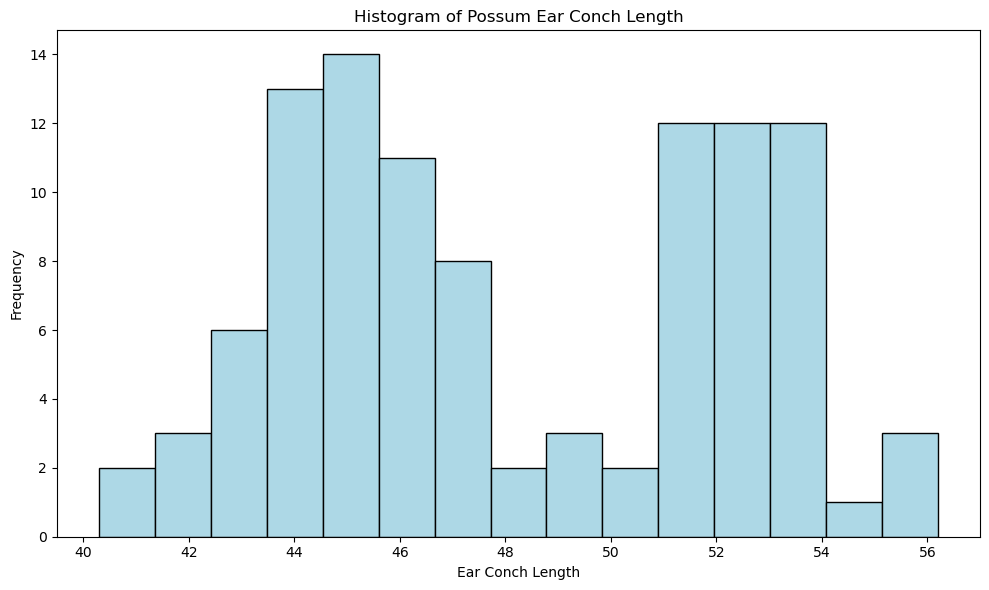

In [211]:
plt.figure(figsize=(10, 6))
plt.hist(possum['earconch'], bins=15, color='lightblue', edgecolor='black')
plt.title('Histogram of Possum Ear Conch Length')
plt.xlabel('Ear Conch Length')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

This histogram shows the distribution of the ear conch length. The distribution shows two peak at around 44-46 and 52-53. We can assum that there are two types of possums with very distinct ear conch length.

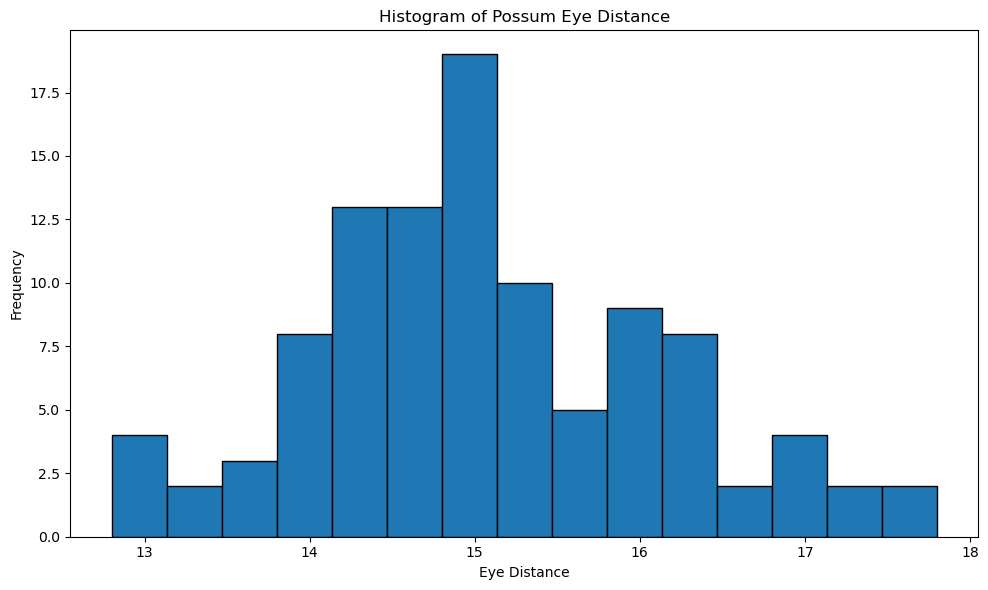

In [212]:
plt.figure(figsize=(10, 6))
plt.hist(possum['eye'], bins=15, edgecolor='black')
plt.title('Histogram of Possum Eye Distance')
plt.xlabel('Eye Distance')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

This histogram shows the distribution of the possum eye distance from the medial canthis to lateral canthus of the right eye. The spread is concentrated between 13 and 18 unit. The distribution has one peak at 15 unit which show that most of the possums observed have eye distance in the value of 15.

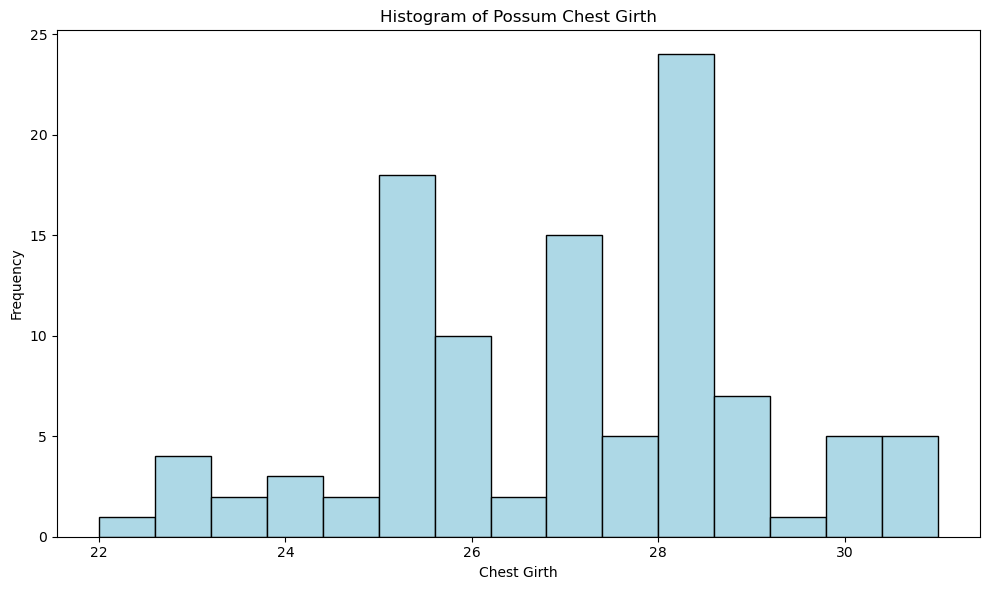

In [213]:
plt.figure(figsize=(10, 6))
plt.hist(possum['chest'], bins=15, color='lightblue', edgecolor='black')
plt.title('Histogram of Possum Chest Girth')
plt.xlabel('Chest Girth')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

This histogram shows the distribution of the possum chest girth. The spread of the data is between 22cm to 31cm. There is a clear peak at 28cm indicating that this is the most common chest girth size among the observed possum.

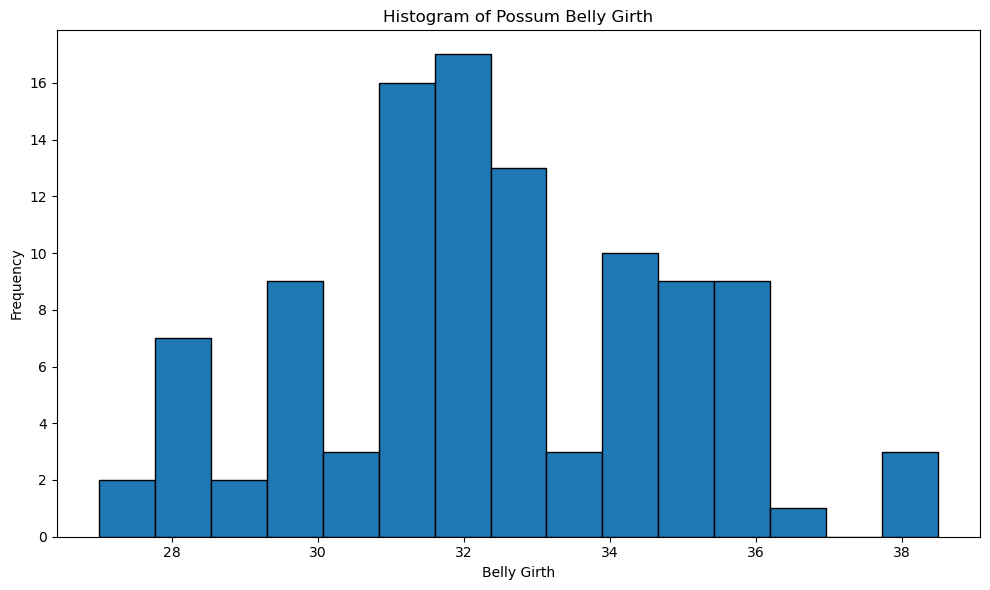

In [214]:
plt.figure(figsize=(10, 6))
plt.hist(possum['belly'], bins=15, edgecolor='black')
plt.title('Histogram of Possum Belly Girth')
plt.xlabel('Belly Girth')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

This histogram shows the distribution of the possum belly girth. The range of the belly girth is from 27cm to 38cm. The most common values is around 31cm-33cm and there is a peak in at 32cm. 

In [215]:
#Show the descriptive statistics for the whole dataset
possum.describe()

,case,site,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
count,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000
mean,52.500000,3.625000,4.082692,92.972115,56.346154,87.098077,37.033654,68.483173,48.134615,15.058173,26.951923,32.447115
std,30.166206,2.349086,1.758678,2.359548,1.954304,4.317091,1.649160,4.374943,4.107931,1.056972,1.984796,2.449409
min,1.000000,1.000000,1.100000,88.200000,51.500000,75.000000,33.500000,60.300000,40.300000,12.800000,22.000000,27.000000
25%,26.750000,1.000000,2.925000,91.500000,55.150000,84.000000,36.000000,64.775000,44.800000,14.400000,25.500000,31.000000
50%,52.500000,3.000000,3.800000,92.800000,56.350000,88.000000,37.000000,68.050000,46.800000,14.900000,27.000000,32.000000
75%,78.250000,6.000000,5.325000,94.400000,57.600000,90.125000,38.000000,72.500000,52.000000,15.800000,28.000000,34.000000
max,104.000000,7.000000,8.400000,98.600000,61.000000,96.500000,41.000000,77.900000,56.200000,17.800000,31.000000,38.500000


# Answer to Section 3 - Hypothesis Testing

## Hypothesis 1 (all the codes in one cell) 

Null Hypothesis (H0): The mean head length of possums in Victoria and Other regions is equal. (μA = μB)

Alternative Hypothesis (Ha): The mean head length of possums in Victoria and Other regions different. (μA ≠ μB)

We’ll use a significance level of 0.05 (5%).

In [216]:
# Separate the head length by Population
headlength_Vic = possum[possum['Pop'] == 'Vic']['hdlngth']
headlength_other = possum[possum['Pop'] == 'other']['hdlngth']

# Perform a two-sample t-test two independent sample t test)
t_statistic, p_value = stats.ttest_ind(headlength_Vic, headlength_other)

print("t-statistic:", t_statistic)
print("p-value:", p_value)

# Step 4: Decide based on the p-value
# Significance level
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis. There is a significant difference between the mean head length of possums in Victoria and other.")
else:
    print("Fail to reject the null hypothesis. The data does not provide sufficient evidence that the mean head length of possums in Victoria and other are different.")


t-statistic: 0.557298724123926
p-value: 0.5785442723917417
Fail to reject the null hypothesis. The data does not provide sufficient evidence that the mean head length of possums in Victoria and other are different.


## Hypothesis 2 (all the codes in one cell) 

Null Hypothesis (H0): The mean total length for male possums and female possums is equal. (μA = μB)

Alternative Hypothesis (Ha): The total length for male possums and female possums is different. (μA ≠ μB)

We’ll use a significance level of 0.05 (5%). 

In [217]:
# Separate the total length by gender
totallength_male = possum[possum['gender'] == 'm']['totlngth']
totallength_female = possum[possum['gender'] == 'f']['totlngth']

# Perform a two-sample t-test two independent sample t test)
t_statistic, p_value = stats.ttest_ind(totallength_male, totallength_female)

print("t-statistic:", t_statistic)
print("p-value:", p_value)

# Step 4: Decide based on the p-value
# Significance level
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis. There is a significant difference between the mean total length for male possums and female possums.")
else:
    print("Fail to reject the null hypothesis. The data does not provide sufficient evidence that the mean total length for male possums and female possums are different.")


t-statistic: -1.664565036829979
p-value: 0.09906863882826797
Fail to reject the null hypothesis. The data does not provide sufficient evidence that the mean total length for male possums and female possums are different.


# Answer to Section 4 - Regression Analysis

## Simple Linear Regression

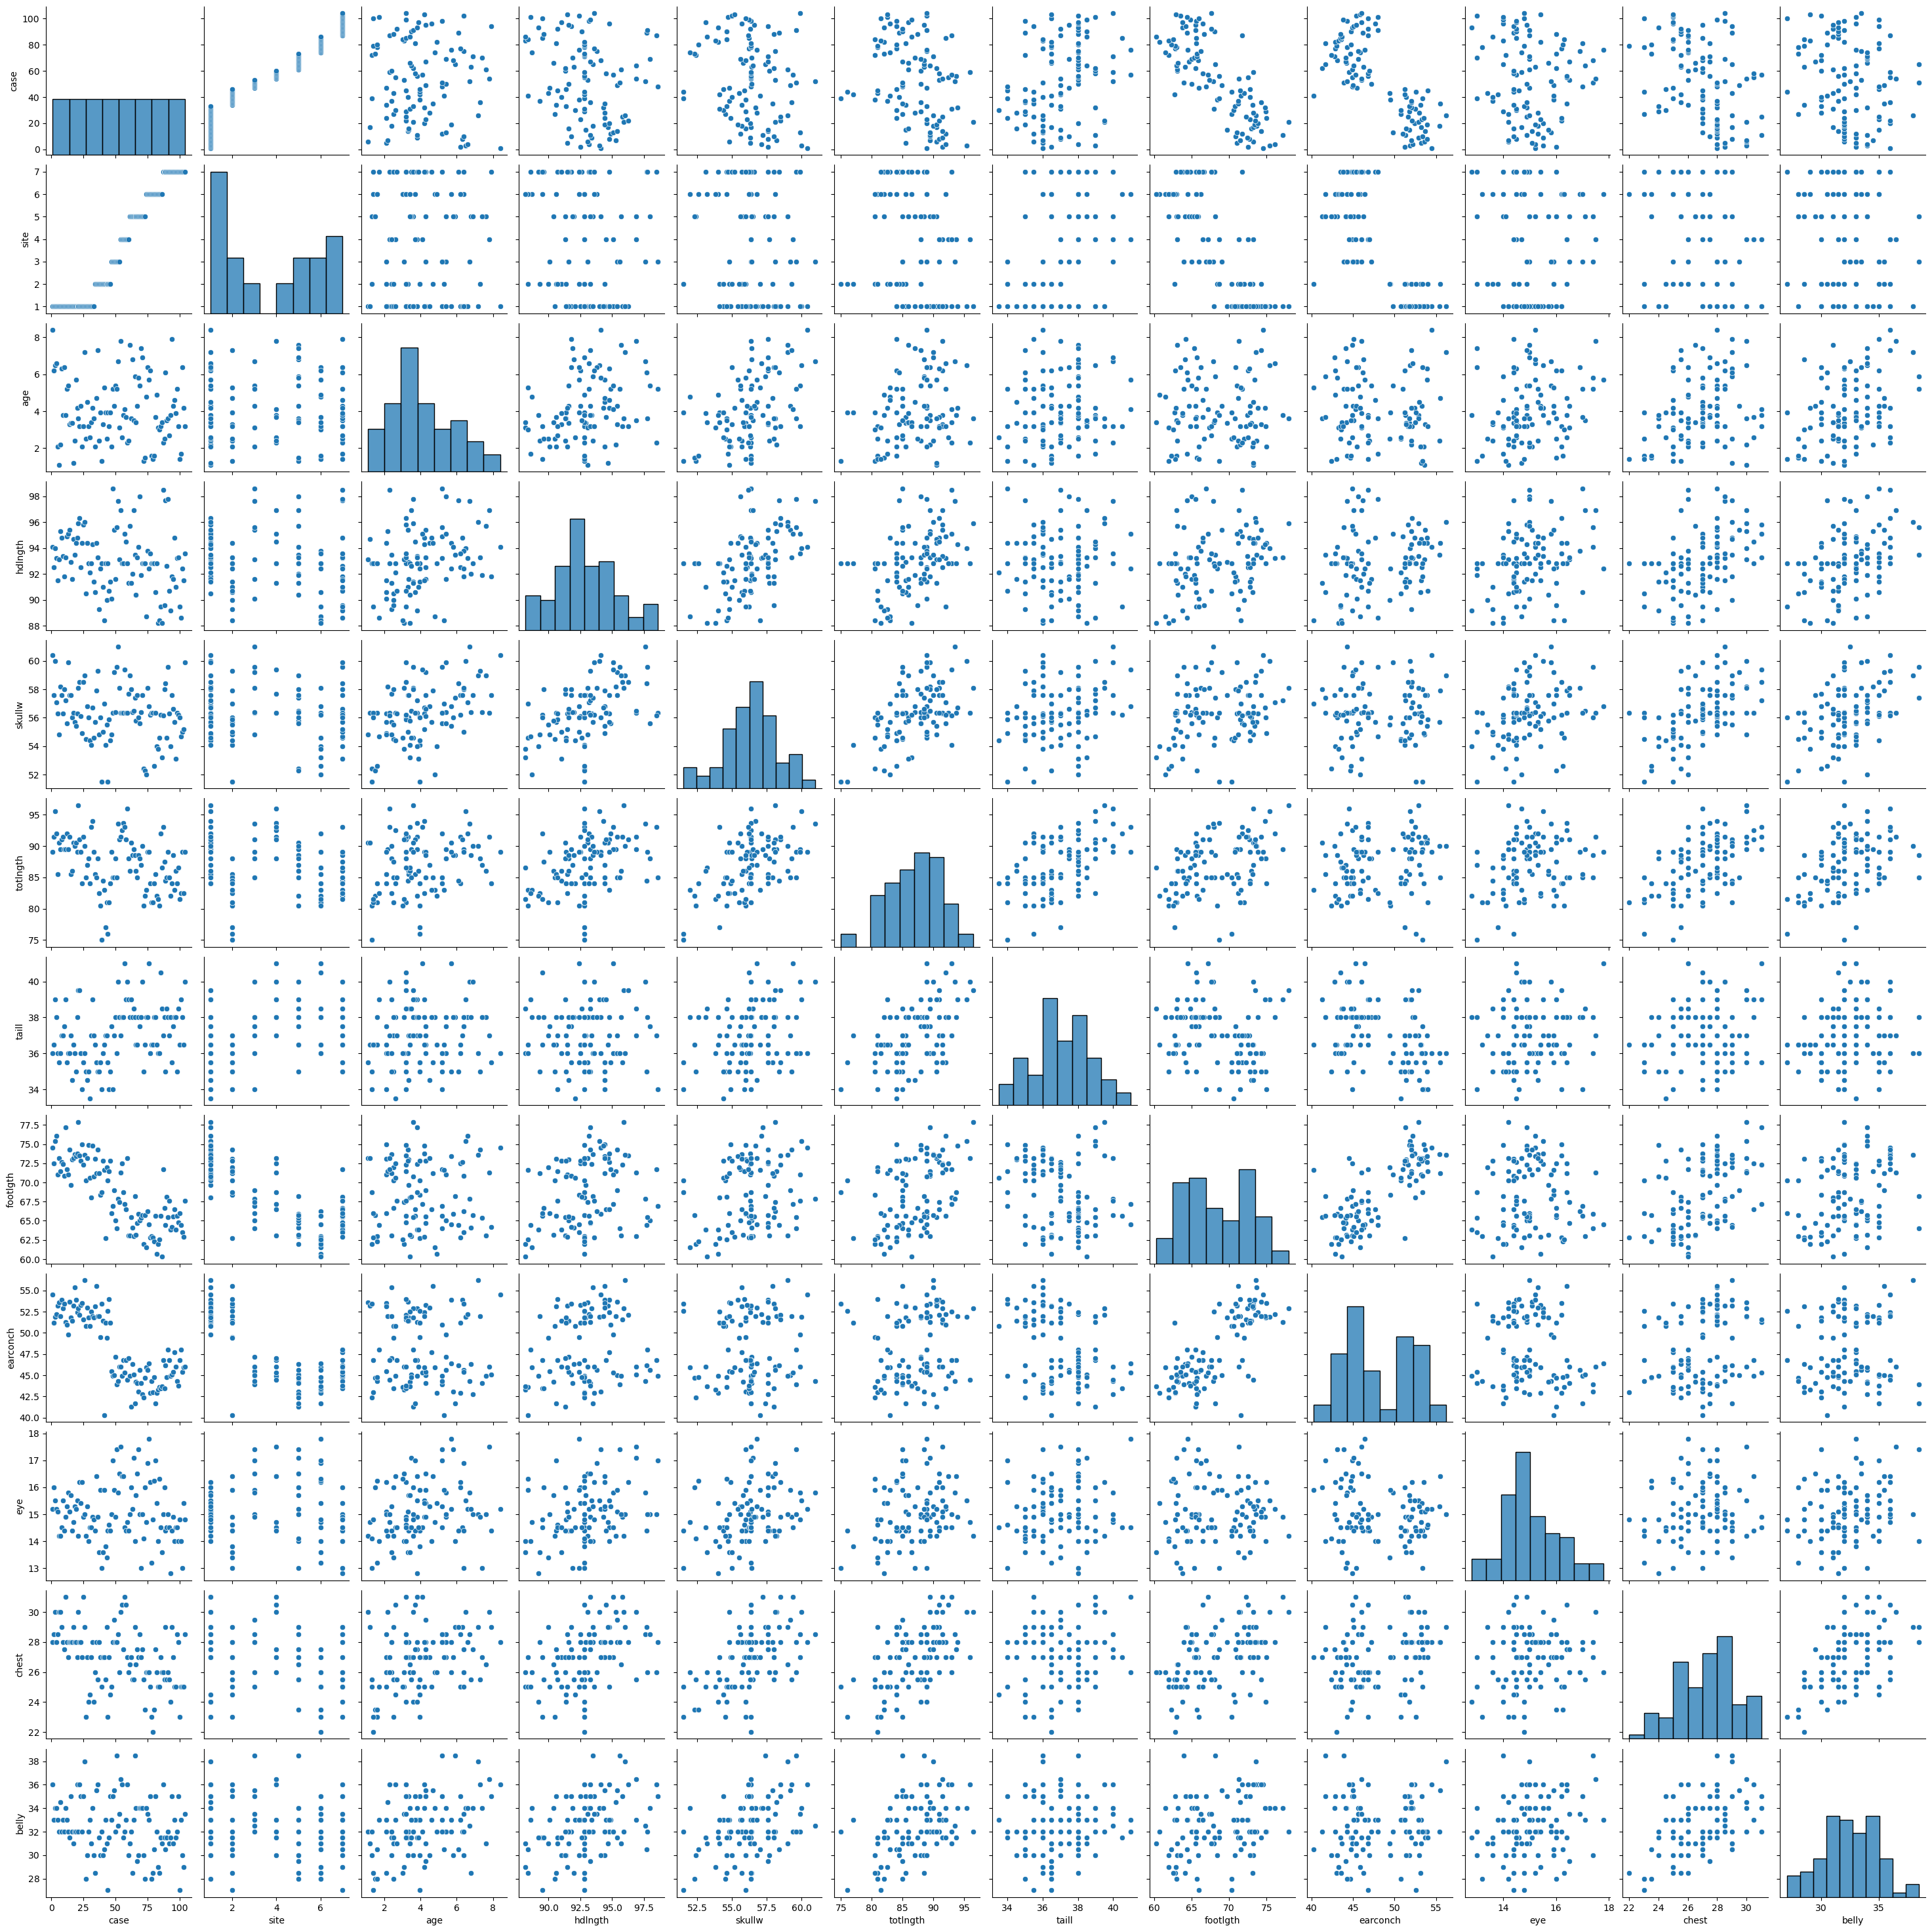

In [218]:
# Create pairwise scatterplots of Possum data
import seaborn as sns
sns.pairplot(possum)

### Simple Linear Regression 1

In [219]:
#Subset the data
ols_data_1 = possum[["hdlngth", "skullw"]]

In [220]:
#Write out formula  = Y~X
ols_formula_1 = "hdlngth ~ skullw"

In [221]:
#Import ols function
from statsmodels.formula.api import ols

#Build OLS, fit model to data
OLS = ols(formula = ols_formula_1, data = ols_data_1)
model_1 = OLS.fit()
model_1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                hdlngth   R-squared:                       0.226
Model:                            OLS   Adj. R-squared:                  0.219
Method:                 Least Squares   F-statistic:                     29.80
Date:                Sun, 12 Oct 2025   Prob (F-statistic):           3.38e-07
Time:                        22:26:49   Log-Likelihood:                -223.02
No. Observations:                 104   AIC:                             450.0
Df Residuals:                     102   BIC:                             455.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     60.6224      5.929     10.224      0.000      48.862      72.383
skullw         0.5741      0.105      5.459      0.000       0.366       0.783
==============================================================================
Omnibus:                        2.093   Durbin-Watson:                   2.128
Prob(Omnibus):                  0.351   Jarque-Bera (JB):                1.594
Skew:                           0.285   Prob(JB):                        0.451
Kurtosis:                       3.206   Cond. No.                     1.63e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.63e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

The interpretation of a regression model primarily depends on the coefficients and p-values. Coefficients indicate how changes in the independent variable (skull width) are associated with changes in the dependent variable (headl length). P-values demonstrate whether these coefficients are statistically significant.

In this case, the slope (coefficient for skull width) is 0.5741, and the intercept is 60.6224. This means that head length length equals the intercept (60.6224) plus the slope (0.5741) times skull width. In other words, for every one mm increase in skull width, we expect the head length to increase by approximately 0.5741 mm.

The p-value associated with the coefficient for skull width, which is 0.000. This p-value tests the null hypothesis that the coefficient is zero. A small p-value (typically less than 0.05) suggests that the null hypothesis is likely false, meaning we reject the null hypothesis and conclude that the coefficient is statistically significantly different from zero. This indicates a strong relationship between skull width and total length.

The observed positive correlation between skull width and total length does not necessarily imply causation. In this case the correlation refers to a relationship between two variables, but it doesn’t prove that one variable directly causes the other to change. The positive correlation observed could be influenced by various factors, and without further analysis, we cannot definitively say that changes in body mass cause changes in flipper length.

**Despite this, the regression analysis provides valuable insights. Specifically, we can conclude that for possum, a 1mm increase in skull width is associated with a 0.5741 mm increase in total length. These results are statistically significant, with a p-value of 0.000, a confidence interval for the slope ranging from 0.366 to 0.783, and an R-squared value of 0.226. This R-squared value indicates that approximately 22.6% of the variability in total length can be explained by skull width.** <br>

The confidence interval for the slope, ranging from 0.366 to 0.783, tells us that we can be 95% confident that the true effect of skull width on head length length lies within this range. In other words, if we were to repeat this study many times, 95% of the calculated intervals would contain the true slope. 

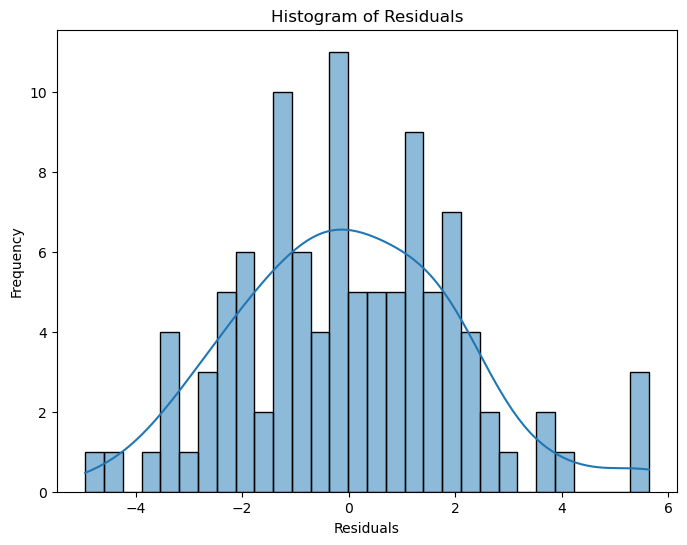

In [222]:
# Get the residuals
residuals_1 = model_1.resid


# Histogram of residuals
plt.figure(figsize=(8, 6))
sns.histplot(residuals_1, kde=True, bins=30)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

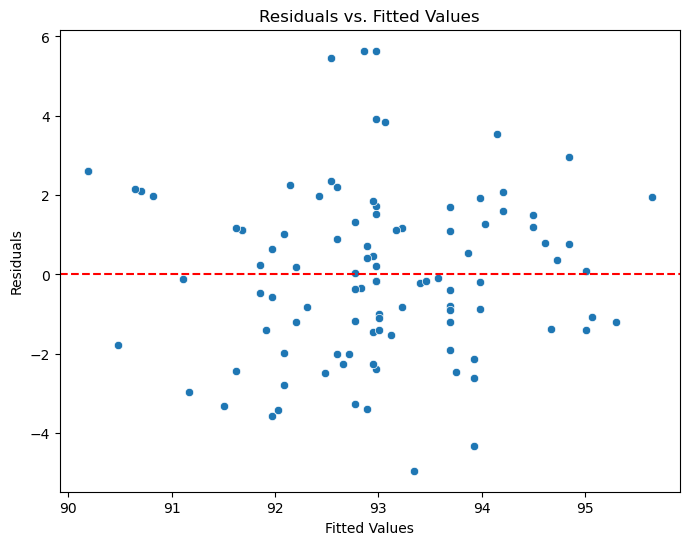

In [223]:
# Get fitted values
fitted_vals_1 = model_1.fittedvalues

# Scatter plot of residuals vs. fitted values
plt.figure(figsize=(8, 6))
sns.scatterplot(x=fitted_vals_1, y=residuals_1)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs. Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()


The scatter plot of residuals vs. fitted values should have no distinct pattern if the assumption of linearity is met.<br> 
In this case, the generated plot above did not show any obvious non-linear patterns.

### Simple Linear Regression 2

In [224]:
#Subset the data
ols_data_2 = possum[["taill", "totlngth"]]

In [225]:
#Write out formula  = Y~X
ols_formula_2 = "totlngth ~ taill"

In [226]:
#Import ols function
from statsmodels.formula.api import ols

#Build OLS, fit model to data
OLS_2 = ols(formula = ols_formula_2, data = ols_data_2)
model_2 = OLS_2.fit()
model_2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               totlngth   R-squared:                       0.232
Model:                            OLS   Adj. R-squared:                  0.224
Method:                 Least Squares   F-statistic:                     30.73
Date:                Sun, 12 Oct 2025   Prob (F-statistic):           2.33e-07
Time:                        22:26:49   Log-Likelihood:                -285.48
No. Observations:                 104   AIC:                             575.0
Df Residuals:                     102   BIC:                             580.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     40.4502      8.423      4.802      0.000      23.743      57.157
taill          1.2596      0.227      5.544      0.000       0.809       1.710
==============================================================================
Omnibus:                        2.086   Durbin-Watson:                   0.858
Prob(Omnibus):                  0.352   Jarque-Bera (JB):                2.011
Skew:                          -0.263   Prob(JB):                        0.366
Kurtosis:                       2.567   Cond. No.                         838.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The interpretation of a regression model primarily depends on the coefficients and p-values. Coefficients indicate how changes in the independent variable (tail length) are associated with changes in the dependent variable (total length). P-values demonstrate whether these coefficients are statistically significant.

In this case, the slope (coefficient for tail length) is 1.2596, and the intercept is 40.4502. This means that total length equals the intercept (40.4502) plus the slope (1.2596) times tail length. In other words, for every one cm increase in tail length, we expect the total length to increase by approximately 1.2596 cm.

The p-value associated with the coefficient for tail length, which is 0.000. This p-value tests the null hypothesis that the coefficient is zero. A small p-value (typically less than 0.05) suggests that the null hypothesis is likely false, meaning we reject the null hypothesis and conclude that the coefficient is statistically significantly different from zero. This indicates a strong relationship between body mass and flipper length.

The observed positive correlation between tail length and total length does not necessarily imply causation. Correlation refers to a relationship between two variables, but it doesn’t prove that one variable directly causes the other to change. The positive correlation observed could be influenced by various factors, and without further analysis, we cannot definitively say that changes in body mass cause changes in flipper length.

**Despite this, the regression analysis provides valuable insights. Specifically, we can conclude that for possums, a one cm increase in tail length is associated with a 1.2596 cm increase in total length. These results are statistically significant, with a p-value of 0.000, a confidence interval for the slope ranging from 0.809 to 1.710, and an R-squared value of 0.232. This R-squared value indicates that approximately 23.2% of the variability in total length can be explained by tail length.** <br>

The confidence interval for the slope, ranging from 0.809 to 1.710, tells us that we can be 95% confident that the true effect of tail length on total length lies within this range. In other words, if we were to repeat this study many times, 95% of the calculated intervals would contain the true slope. 

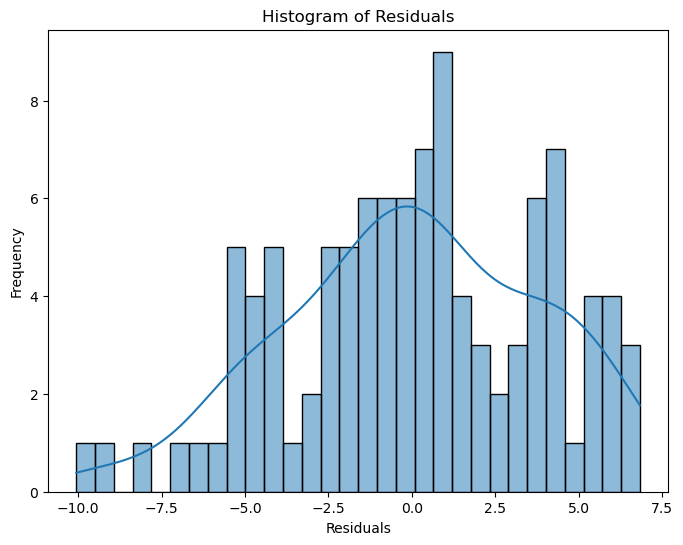

In [227]:
# Get the residuals
residuals_2 = model_2.resid


# Histogram of residuals
plt.figure(figsize=(8, 6))
sns.histplot(residuals_2, kde=True, bins=30)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

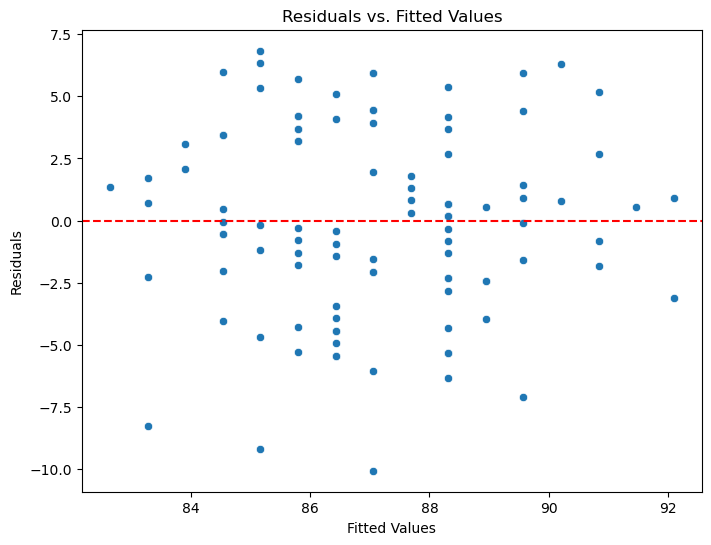

In [228]:
# Get fitted values
fitted_vals_2 = model_2.fittedvalues

# Scatter plot of residuals vs. fitted values
plt.figure(figsize=(8, 6))
sns.scatterplot(x=fitted_vals_2, y=residuals_2)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs. Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()


The scatter plot of residuals vs. fitted values should have no distinct pattern if the assumption of linearity is met.<br> 
In this case, the generated plot above did not show any obvious non-linear patterns.

### Simple Linear Regression 3

In [229]:
ols_data_3 = possum[["chest", "belly"]]

In [230]:
# Write out formula  = Y~X
ols_formula_3 = "belly ~ chest"

In [231]:
# Import ols function
from statsmodels.formula.api import ols

# Build OLS, fit model to data
OLS_3 = ols(formula = ols_formula_3, data = ols_data_3)
model_3 = OLS_3.fit()
model_3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  belly   R-squared:                       0.272
Model:                            OLS   Adj. R-squared:                  0.265
Method:                 Least Squares   F-statistic:                     38.04
Date:                Sun, 12 Oct 2025   Prob (F-statistic):           1.41e-08
Time:                        22:26:50   Log-Likelihood:                -223.75
No. Observations:                 104   AIC:                             451.5
Df Residuals:                     102   BIC:                             456.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     15.1116      2.818      5.362      0.000       9.522      20.701
chest          0.6432      0.104      6.168      0.000       0.436       0.850
==============================================================================
Omnibus:                        5.225   Durbin-Watson:                   2.022
Prob(Omnibus):                  0.073   Jarque-Bera (JB):                4.806
Skew:                           0.457   Prob(JB):                       0.0905
Kurtosis:                       2.476   Cond. No.                         370.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The interpretation of a regression model primarily depends on the coefficients and p-values. Coefficients indicate how changes in the independent variable (chest girth) are associated with changes in the dependent variable (belly girth). P-values demonstrate whether these coefficients are statistically significant.

In this case, the slope (coefficient for chest girth) is 0.6432	, and the intercept is 15.1116. This means that belly girth equals the intercept (15.1116) plus the slope (0.6432) times chest girth . In other words, for every one cm increase in chest girth, we expect the belly girth to increase by approximately 0.6432 cm.

Next, let’s review the p-value associated with the coefficient for body mass, which is 0.000. This p-value tests the null hypothesis that the coefficient is zero. A small p-value (typically less than 0.05) suggests that the null hypothesis is likely false, meaning we reject the null hypothesis and conclude that the coefficient is statistically significantly different from zero. This indicates a strong relationship between chest girth and belly girth.

The observed positive correlation between chest girth and bely girth does not necessarily imply causation. Correlation refers to a relationship between two variables, but it doesn’t prove that one variable directly causes the other to change. The positive correlation observed could be influenced by various factors, and without further analysis, we cannot definitively say that changes in chest girth cause changes in belly girth.

**Despite this, the regression analysis provides valuable insights. Specifically, we can conclude that for possums, a one cm increase in chest girth is associated with a 0.6432 cm increase in belly girth. These results are statistically significant, with a p-value of 0.000, a confidence interval for the slope ranging from 0.436 to 0.850, and an R-squared value of 0.272. This R-squared value indicates that approximately 27.2% of the variability in belly girth can be explained by chest girth.** <br>

The confidence interval for the slope, ranging from 0.436 to 0.850, tells us that we can be 95% confident that the true effect of chest girth on belly girth lies within this range. In other words, if we were to repeat this study many times, 95% of the calculated intervals would contain the true slope. 

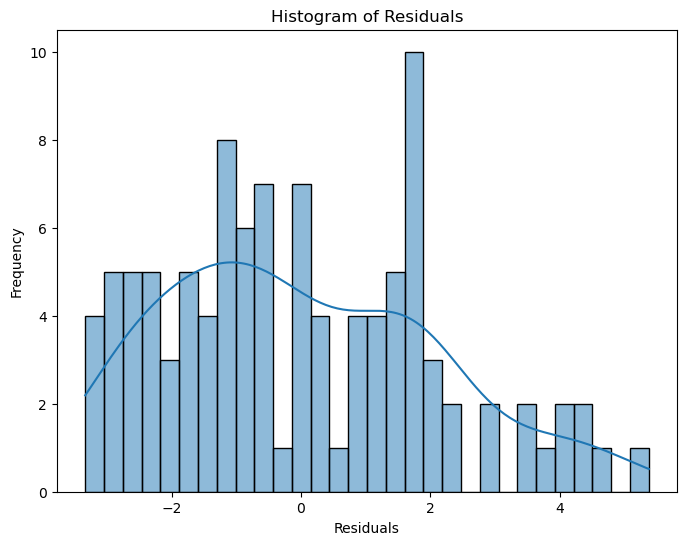

In [232]:
# Get the residuals
residuals_3 = model_3.resid


# Histogram of residuals
plt.figure(figsize=(8, 6))
sns.histplot(residuals_3, kde=True, bins=30)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

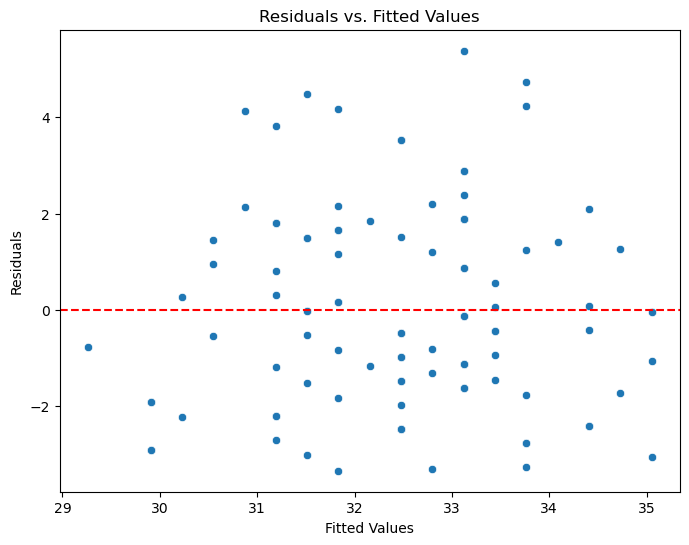

In [233]:
# Get fitted values
fitted_vals_3 = model_3.fittedvalues

# Scatter plot of residuals vs. fitted values
plt.figure(figsize=(8, 6))
sns.scatterplot(x=fitted_vals_3, y=residuals_3)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs. Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()


The scatter plot of residuals vs. fitted values should have no distinct pattern if the assumption of linearity is met.<br> 
In this case, the generated plot above did not show any obvious non-linear patterns.

## Multiple Linear Regression

In [234]:
possum_drop_for_encode = possum.drop(columns=['case', 'site'])

In [235]:
#Define the categorical columns: Pop and Gender
categorical_cols = ['Pop', 'gender']

# One-hot encoding the categorical column
possum_encoded = pd.get_dummies(possum_drop_for_encode, columns=categorical_cols, drop_first=True)

# Convert any boolean columns to integers: zero/one
possum_encoded = possum_encoded.astype(int)

# Display the one-hot encoded DataFrame
print("Possum Encoded DataFrame:")
print(possum_encoded)

Possum Encoded DataFrame:
     age  hdlngth  skullw  totlngth  taill  footlgth  earconch  eye  chest  \
0      8       94      60        89     36        74        54   15     28   
1      6       92      57        91     36        72        51   16     28   
2      6       94      60        95     39        75        51   15     30   
3      6       93      57        92     38        76        52   15     28   
4      2       91      56        85     36        71        53   15     28   
..   ...      ...     ...       ...    ...       ...       ...  ...    ...   
99     1       89      56        81     36        66        46   14     23   
100    1       88      54        82     39        64        48   14     25   
101    6       92      55        89     38        63        45   13     25   
102    4       91      55        82     36        62        45   15     25   
103    3       93      59        89     40        67        46   14     28   

     belly  Pop_other  gender_m  
0  

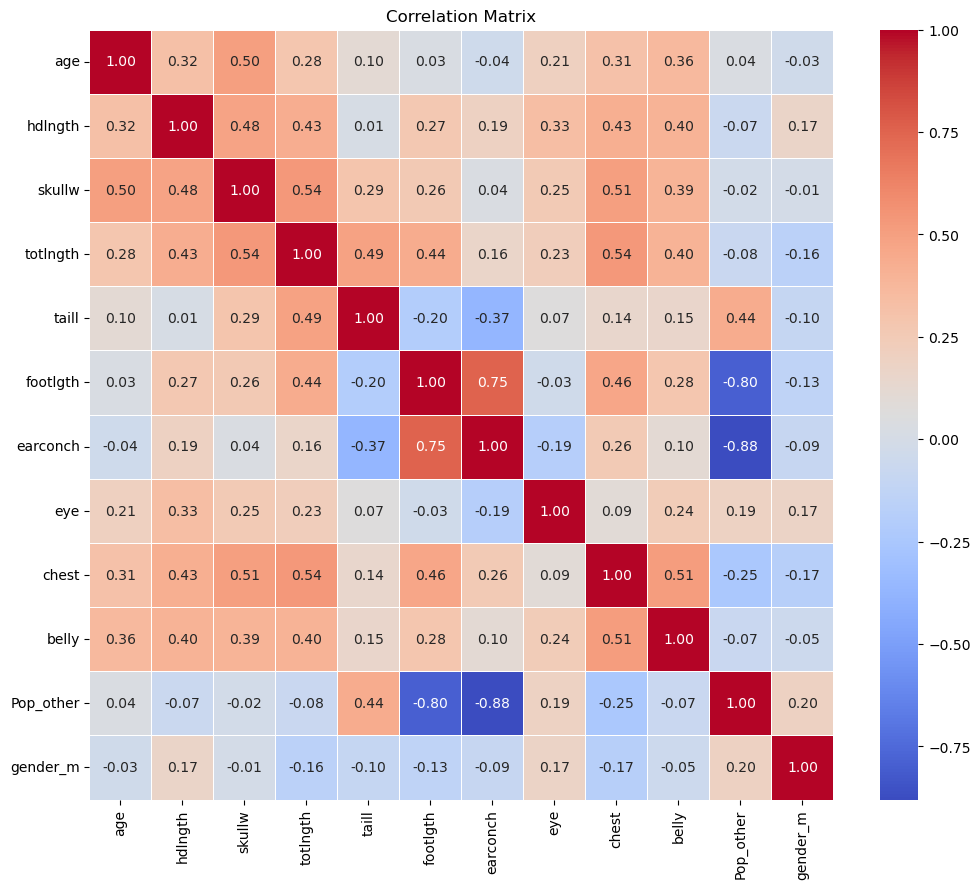

In [236]:
# Compute the correlation matrix
correlation_matrix = possum_encoded.corr()

# Set up the matplotlib figure
plt.figure(figsize=(12, 10))

# Generate a heatmap
#annot=True adds annotations (i.e., the actual correlation values) to each cell in the heatmap. 
#When set to True, each cell in the heatmap will display the corresponding value from the correlation_matrix.

#cmap='coolwarm'sets the colormap for the heatmap. The coolwarm colormap is a popular choice for showing diverging data

#fmt=".2f" specifies the format of the annotations. ".2f" means the values will be formatted as floating-point numbers with two decimal places.
#linewidths=0.5 sets the width of the lines that divide the cells in the heatmap.

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Matrix')
plt.show()

Notes: the darker the blue colour, the more negative the value of the correlation, the darker the red the more positive the value of the correlation

This heatmap is a visual representation of the correlation matrix for the variables in your dataset.<br>
The correlation heatmap can be interpreted as follows:<br>


Color Scale (Right Side of the Heatmap):<br>

The color scale indicates the strength and direction of the correlations.<br>
Red represents a strong positive correlation (closer to +1).<br>
Blue represents a strong negative correlation (closer to -1).<br>
White or Light Blue represents little or no correlation (closer to 0).<br>


The diagonal of the matrix shows a perfect correlation (value of 1) for each variable with itself, which is why it's always deep red.

In [237]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Define the independent variables and the dependent variable
X = possum_encoded.drop('totlngth', axis=1)
y = possum_encoded['totlngth']

# Add a constant term to the model (for the intercept)
#sm.add_constant(X) adds a column of ones to the matrix X.
#The added column represents the constant term (also known as the intercept)
X = sm.add_constant(X)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns

vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Display the VIF data
print(vif_data)

      Feature          VIF
0       const  2780.430277
1         age     1.505965
2     hdlngth     1.804819
3      skullw     2.065091
4       taill     1.584588
5    footlgth     4.143026
6    earconch     5.208724
7         eye     1.293121
8       chest     1.962965
9       belly     1.577538
10  Pop_other     7.407660
11   gender_m     1.216973


**VIF < 10**: Generally acceptable; no significant multicollinearity.<br>
**VIF > 10**: Indicates multicollinearity issues.<br>

In this case, VIF values for all variables are **below 10**, suggesting that multicollinearity is not a significant concern.

note: The constant term is inherently collinear with any other variables in the model because it does not vary—it is the same (a constant value of 1) across all observations.

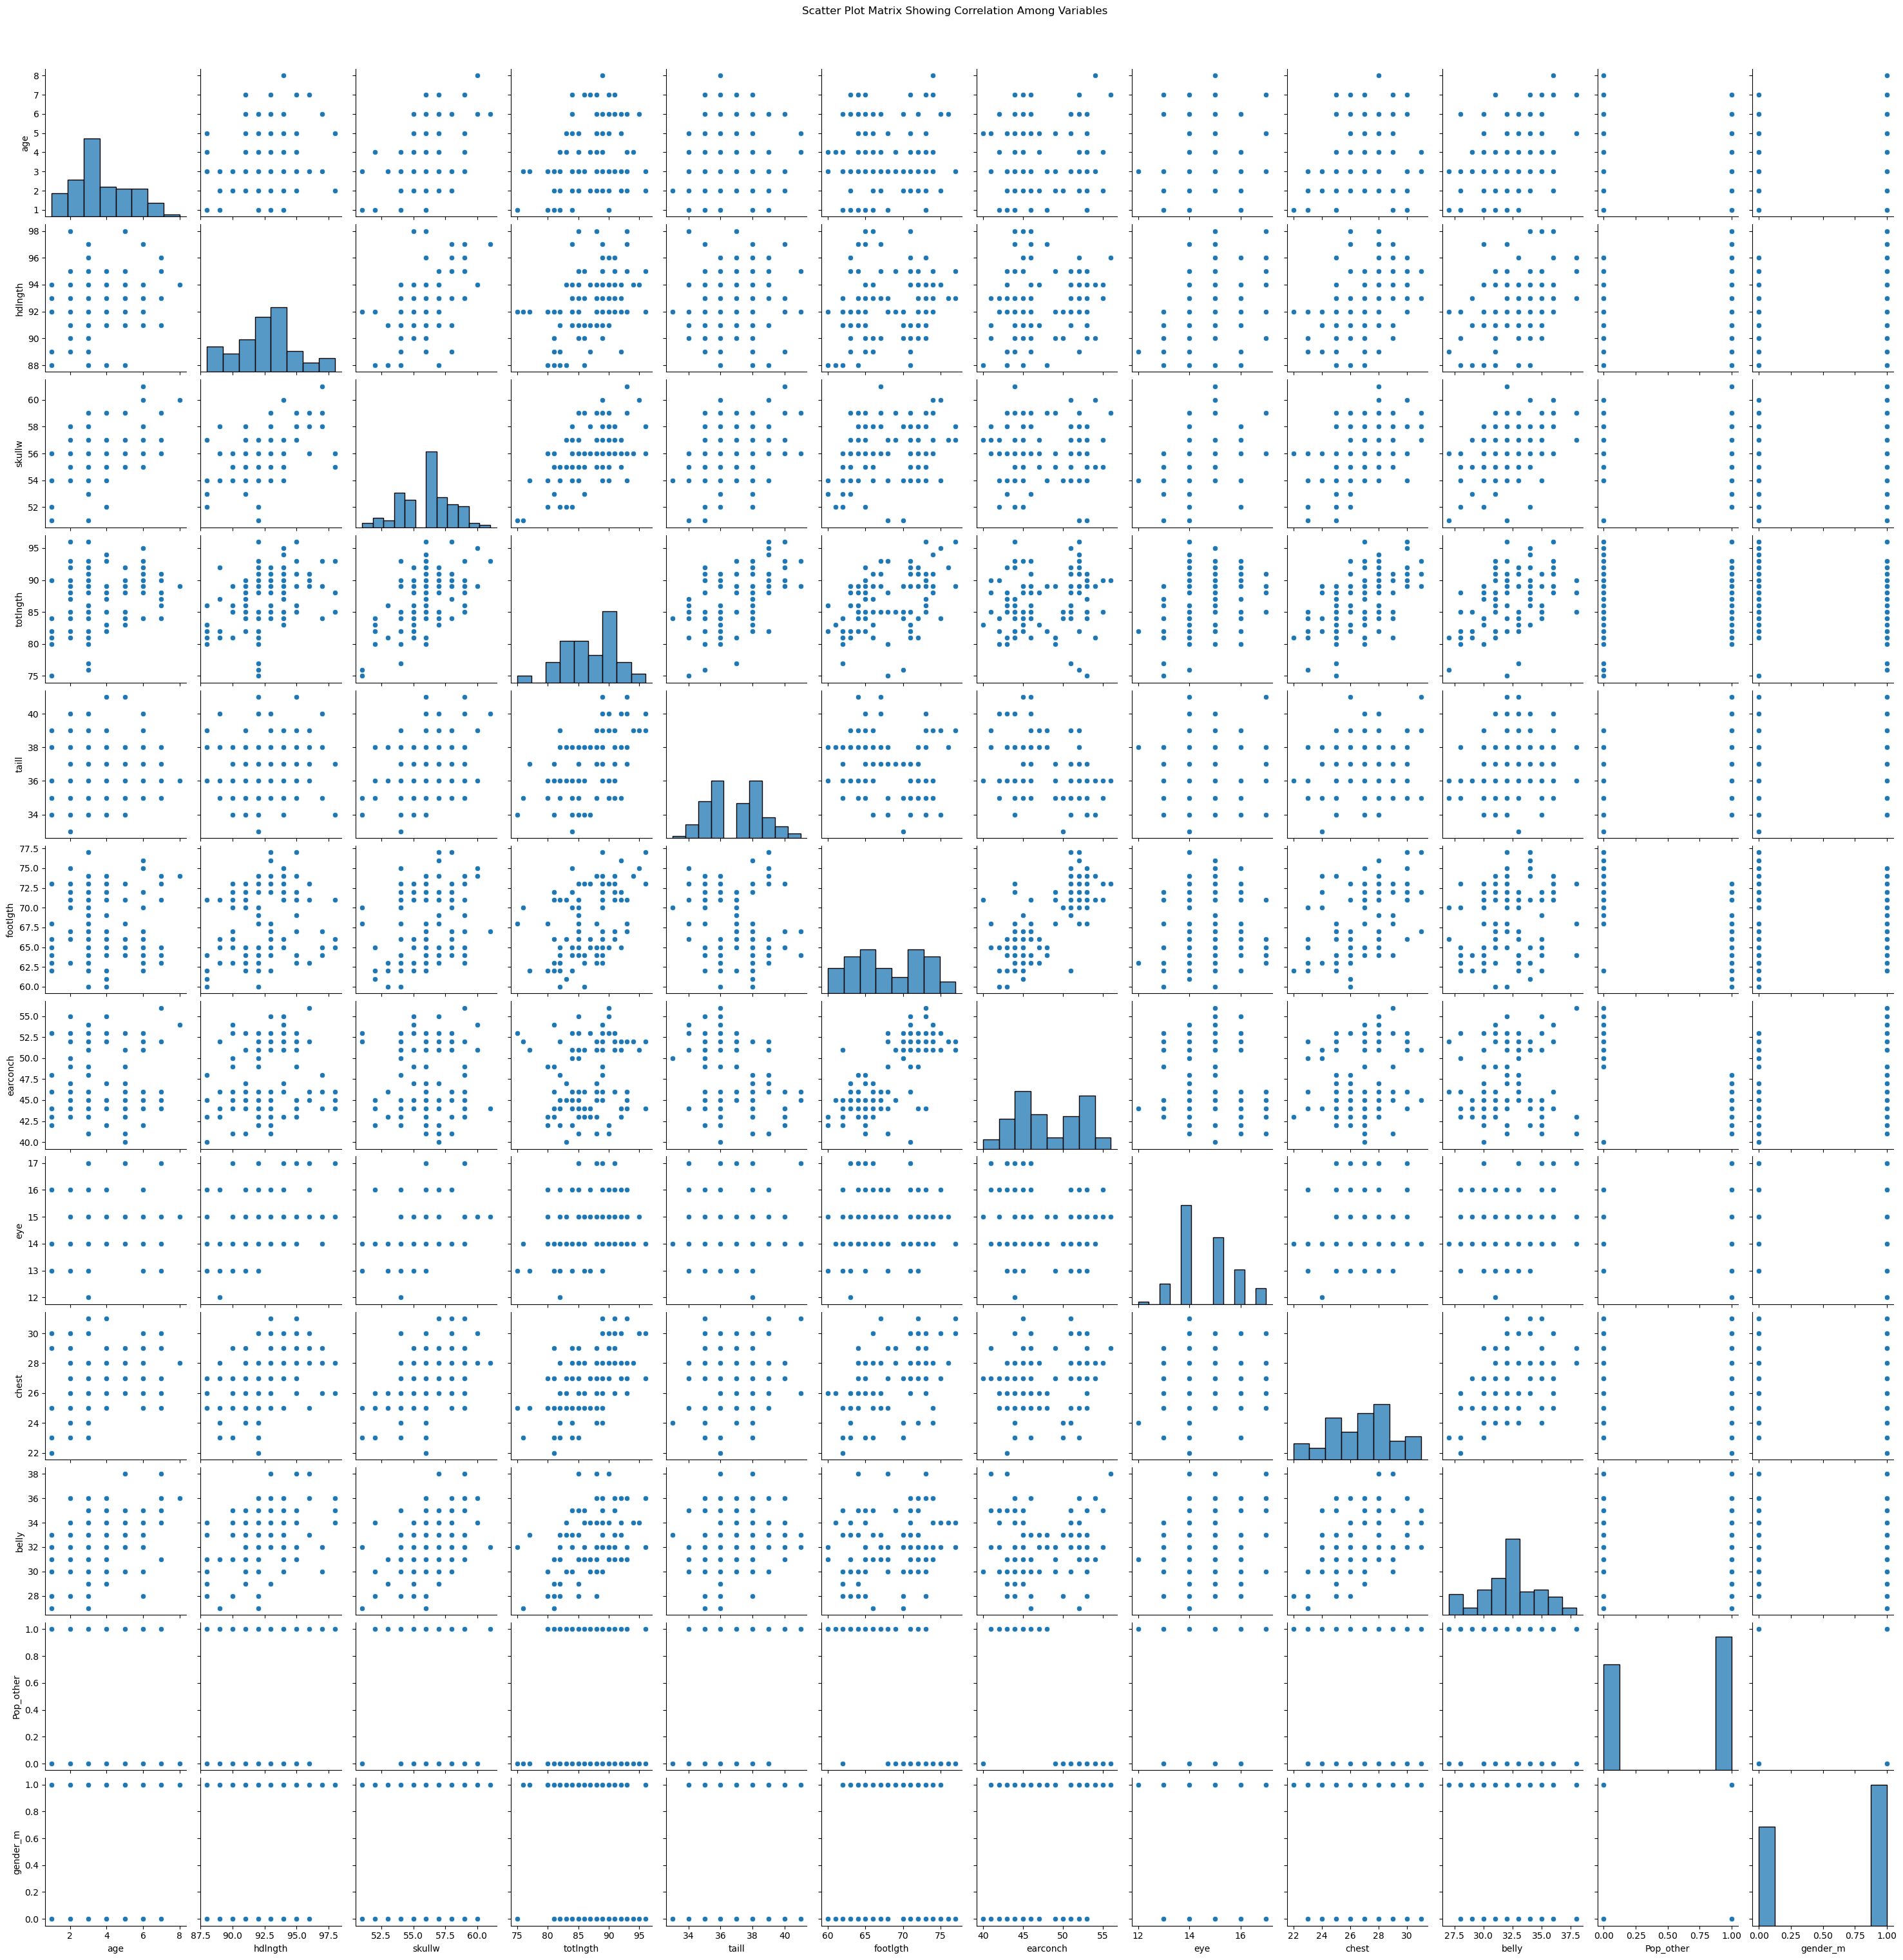

In [238]:
# Scatter plot matrix to show correlation among variables
sns.pairplot(possum_encoded, kind='scatter', height=2.5)
plt.suptitle("Scatter Plot Matrix Showing Correlation Among Variables", y=1.02)
plt.show()

In [239]:
# Fit the multiple regression model
model_multi = sm.OLS(y, X).fit()

# Display the summary of the regression model
print(model_multi.summary())

                            OLS Regression Results                            
Dep. Variable:               totlngth   R-squared:                       0.676
Model:                            OLS   Adj. R-squared:                  0.638
Method:                 Least Squares   F-statistic:                     17.48
Date:                Sun, 12 Oct 2025   Prob (F-statistic):           3.96e-18
Time:                        22:26:56   Log-Likelihood:                -239.74
No. Observations:                 104   AIC:                             503.5
Df Residuals:                      92   BIC:                             535.2
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -46.8885     13.337     -3.516      0.0

Model Fit Statistics:

R-squared: Indicates the proportion of variance in the dependent variable explained by the independent variables. An R-squared of **0.676** means **67.6%** of the variance is explained.

Adjusted R-squared is **0.638**: Adjusts the R-squared value based on the number of predictors. It's slightly lower than R-squared, which is typical.<br>
F-statistic: Tests the overall significance of the model. A high F-statistic with a low p-value indicates that the model is significant. In this study, the F-statistic value is **3.96e-18 < 0.05**, we can conclude that all the independent variables are jointly statistically significance.<br>

Coefficients: Represents the change in the dependent variable for a one-unit change in the predictor, holding other variables constant.
In the regression output, we can interpret the coefficient as follows:<br>

-**Age**: the coefficient is **0.1938**, this indicates that when other variables being held constant one unit increase in age, the total length will increase by **0.1938** unit.<br>

-**Head length**: the coefficient is **0.2763**, this indicates that when other variables being held constant one unit increase in head length, the total length will increase by **0.2763** unit.<br>

-**Skull width**: the coefficient is **0.1576**, this indicates that when other variables being held constant one unit increase in skull width, the total length will increase by **0.1576** unit.<br>

-**tail length**: the coefficient is **1.1117**, this indicates that when other variables being held constant one unit increase in tail length, the total length will increase by **1.1117** unit.<br>

-**foot length**: the coefficient is **0.5590**, this indicates that when other variables being held constant one unit increase in foot length, the total length will increase by **0.5590** unit.<br>

-**ear conch**: the coefficient is **0.1531**, this indicates that when other variables being held constant one unit increase in ear conch, the total length will increase by **0.1531** unit.<br>

-**eye distance**: he coefficient is **0.4218**, this indicates that when other variables being held constant one unit increase in eye distance, the total length will increase by **0.4218** unit.<br>

-**chest girth**: the coefficient is **0.2372**, this indicates that when other variables being held constant one unit increase in chest girth, the total length will increase by **0.2372** unit.<br>

-**belly girth**: the coefficient is **-0.0389**, this indicates that when other variables being held constant one unit increase in belly girth, the total length will deacrease by **-0.0389** unit.<br>


Std Err: The standard error of the coefficient estimate.<br>

t: The t-statistic for testing the null hypothesis that the coefficient is zero.<br>

P>|t|: The p-value for the t-test. A p-value less than 0.05 typically indicates statistical significance.
In the regression output we can interpret the results as follows:<br>

-**Age**: the p-value for age is **0.288 > 0.05**, we can conclude that age variable is not statistically significance.<br>

-**head length**: the p-value for head length is **0.062 > 0.05**, we can conclude that head length variable is not statistically significance.<br>

-**skull width**: the p-value for skull width is **0.395 > 0.05**, we can conclude that skull width variable is not statistically significance.<br>

-**tail length**: the p-value for tail length is **0.000 < 0.05**, we can conclude that tail length variable is statistically significance.<br>

-**foot length**: the p-value for foot length is **0.000 < 0.05**, we can conclude that foot length variable is statistically significance.<br>

-**ear conch**: the p-value for ear conch is **0.276 > 0.05**, we can conclude that ear conch variable is not statistically significance.<br>

-**eye distance**: the p-value for eye distance is **0.120 > 0.05**, we can conclude that eye distance variable is not statistically significance.<br>

-**chest girth**: the p-value for chest girth is **0.185 > 0.05**, we can conclude that chest girth variable is not statistically significance.<br>

-**belly girth**: the p-value for belly girth is **0.764 > 0.05**, we can conclude that belly girth variable is not statistically significance.<br>

**The condition number is 7.82e+03, which is quite large. This suggests that there might be multicollinearity or other numerical issues in the model. While the VIF values previously calculated did not indicate severe multicollinearity, the large condition number is a sign that the model may still have some multicollinearity issues.**

**[1] Standard Errors assume that the covariance matrix of the errors is correctly specified**
The statement is a reminder that the accuracy of the standard errors—and thus the validity of the statistical inferences—depends on the assumption that the error terms in the regression model behave as expected (i.e., their covariance matrix is correctly specified). 

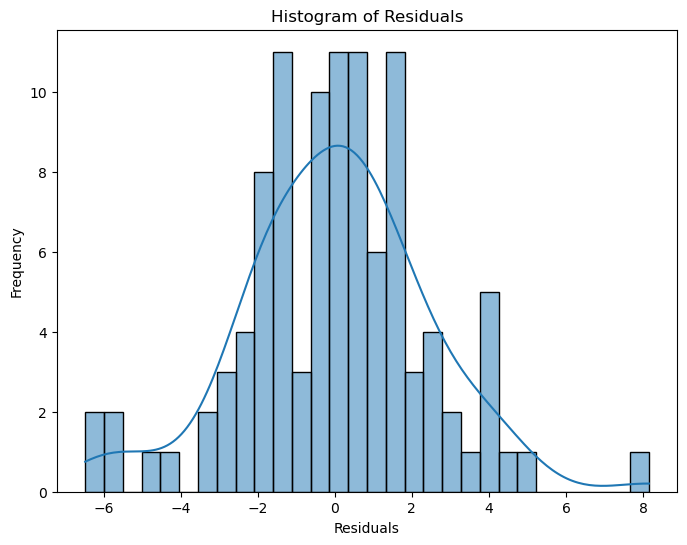

In [240]:
# Get the residuals
residuals_multi = model_multi.resid


# Histogram of residuals
plt.figure(figsize=(8, 6))
sns.histplot(residuals_multi, kde=True, bins=30)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()


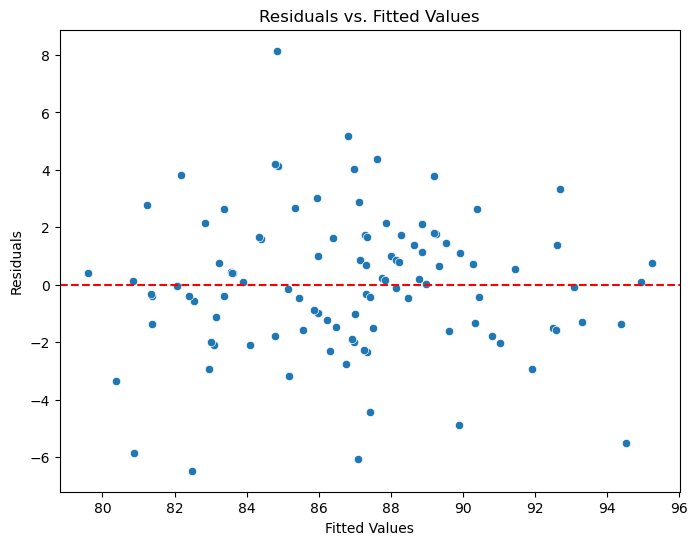

In [241]:
# Get fitted values
fitted_vals_multi = model_multi.fittedvalues

# Scatter plot of residuals vs. fitted values
plt.figure(figsize=(8, 6))
sns.scatterplot(x=fitted_vals_multi, y=residuals_multi)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs. Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()


The scatter plot of residuals vs. fitted values should have no distinct pattern if the assumption of linearity is met.<br> 
In this case, the generated plot above did not show any obvious non-linear patterns.

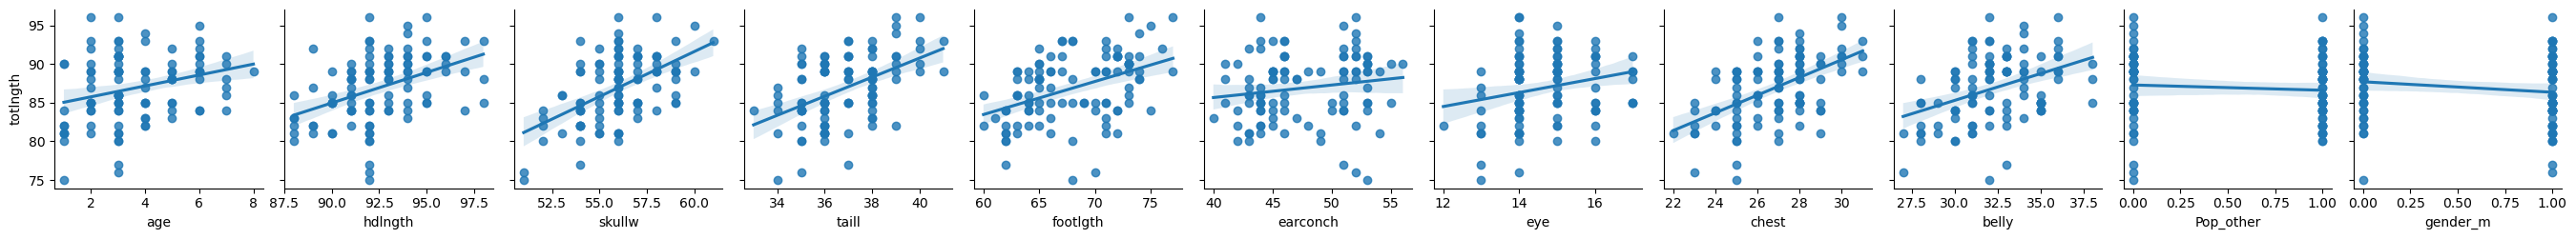

In [242]:
# Pairplot to visualize relationships
sns.pairplot(possum_encoded, x_vars=X.columns.drop('const'), y_vars='totlngth', kind='reg', height=2.5)
plt.show()


The output shown in the image is a grid of scatter plots with regression lines (created using Seaborn's pairplot function) that visualise the relationships between each independent variable and the dependent variable (Total Length). The interpretation for each plot are the followings:

**Age vs. Total Length**:
Plot Description: This scatter plot shows the relationship between possum age (x-axis) and possum total length (y-axis).<br>
There is a clear positive linear relationship, as indicated by the upward-sloping regression line. The points are scattered and not all clustered around the trend line. This suggests that Age might not be a strongly significant predictor of total length in this model, or the relationship might be a small linear or influenced by other factors.

**Head length vs. Total Length**:
Plot Description: This scatter plot shows the relationship between possum head length (x-axis) and possum total length (y-axis).<br>
There is a strong positive linear relationship between Head length and total length, as indicated by the upward-sloping regression line. This also suggests that Head length is a significant predictor of the total length in this model.

**Skull Width vs. Total Length**:
Plot Description: This scatter plot shows the relationship between possum skull width (x-axis) and possum total length (y-axis).<br>
There is a strong positive linear relationship between Skull Width and total length, as indicated by the upward-sloping regression line. This also suggests that Skull Width is a significant predictor of the total length in this model.

**Tail length vs. Total Length**:
Plot Description: This scatter plot shows the relationship between possum tail length (x-axis) and possum total length (y-axis).<br>
There is a strong positive linear relationship between tail length and total length, as indicated by the upward-sloping regression line. The points are scattered around the trend line. This also suggests that Tail length is a significant predictor of the total length in this model

**Foot Length vs. Total Length**:
Plot Description: This scatter plot shows the relationship between possum foot length  (x-axis) and possum total length (y-axis).<br>
There is a clear positive linear relationship between foot length and total length, as indicated by the upward-sloping regression line. 

**Ear Conch Length vs. Total Length**:
Plot Description: This scatter plot shows the relationship between possum ear conch length (x-axis) and possum total length (y-axis).
There is a slightly upward-sloping regression line, indicating a slight positive linear relationship. The regression line is only slightly upward and nearly flat, indicating a small linear relationship.

**Eye distance vs. Total Length**:
Plot Description: This scatter plot shows the relationship between possum eye distance (x-axis) and possum total length (y-axis).<br>
There is a positive linear relationship, as indicated by the upward-sloping regression line. However, the line is only slightly upward, suggesting a small linear relationship.

**Chest Girth vs. Total Length**:
Plot Description: This scatter plot shows the relationship between possum chest girth (x-axis) and possum total length (y-axis).<br>
There is a positive linear relationship between chest girth and total length, as indicated by the upward-sloping regression line. This also suggests that Chest girth is a significant predictor of the total length in this model.

**Belly Girth vs. Total Length**:
Plot Description: This scatter plot shows the relationship between possum belly girth (x-axis) and possum total length (y-axis).<br>
There is a clear positive linear relationship between belly girth and total length, as indicated by the upward-sloping regression line. This also suggests that belly girth is a significant predictor of the total length in this model.

**Pop_other vs. Total Length**:
Plot Description: This plot shows the relationship between the dummy variable Pop_other (which is either 0 or 1, indicating whether the population is either Vic or other) and total length.
The points are clustered around two vertical lines (one at 0, the other at 1), with a very slight downward trend in the regression line, suggesting that population does not have a strong linear relationship with total length. The near-horizontal regression line suggests that the population of the possum does not have a significant impact on the total length of the possum.

**Gender_m vs. Total Length**:
Plot Description: This plot shows the relationship between the dummy variable gender_m (which is either 0 or 1, indicating whether the possum's gender is either male or female) and total length.
The points are clustered around two vertical lines (one at 0, the other at 1), with a very slight downward trend in the regression line, suggesting that gender does not have a strong linear relationship with total length. The near-horizontal regression line suggests that the gender of the possum does not have a significant impact on the total length of the possum.

In [243]:
possum.to_csv('possum.csv', index=False)